## The Dataset

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

a = tf.random.normal((1000,1000))
b = tf.random.normal((1000,1000))

c = tf.matmul(a,b)

print(c.shape)
print("GPU works.")

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(1000, 1000)
GPU works.


In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Dataset folder path
LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nFolder exists?")
print(os.path.exists(LOCAL_DICHASUS_DIR))

if not os.path.exists(LOCAL_DICHASUS_DIR):
    raise FileNotFoundError(
        "Dataset folder was not found. Please make sure the dichasus folder exists in MyDrive."
    )

Mounted at /content/drive
Dataset folder:
/content/drive/MyDrive/dichasus

Folder exists?
True


In [3]:
# ============================================================
# VERIFY DATASET FOLDER AND COLLECT TFRECORD FILES
# ============================================================

import os

LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

if not os.path.isdir(LOCAL_DICHASUS_DIR):
    raise FileNotFoundError(
        f"Dataset folder was not found:\n{LOCAL_DICHASUS_DIR}"
    )

TFRECORD_FILES = sorted(
    [
        os.path.join(LOCAL_DICHASUS_DIR, file_name)
        for file_name in os.listdir(LOCAL_DICHASUS_DIR)
        if file_name.lower().endswith(".tfrecords")
    ]
)

if not TFRECORD_FILES:
    raise FileNotFoundError(
        f"No TFRecord files were found in:\n{LOCAL_DICHASUS_DIR}"
    )

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nNumber of TFRecord files:")
print(len(TFRECORD_FILES))

print("\nTFRecord files:")
for file_path in TFRECORD_FILES:
    print("-", os.path.basename(file_path))

Dataset folder:
/content/drive/MyDrive/dichasus

Number of TFRecord files:
7

TFRecord files:
- dichasus-0d51.tfrecords
- dichasus-0d52.tfrecords
- dichasus-0d53.tfrecords
- dichasus-0d54.tfrecords
- dichasus-0d55.tfrecords
- dichasus-0d56.tfrecords
- dichasus-0d57.tfrecords


In [4]:
# ============================================================
# DICHASUS-0d5x STREAMING DATA LOADER
# SINGLE-MODEL SETUP FOR RX1, RX2, AND BOTH
# ============================================================

import os
import tensorflow as tf


# ============================================================
# Global experiment configuration
# ============================================================

NUM_TOTAL_ANTENNAS = 32
NUM_SUBCARRIERS = 32
NUM_CSI_COMPONENTS = 2

EXPERIMENT_NAME = "dichasus_0d5x_single_model_rx1_rx2_both"


RX1_ANTENNA_INDICES = [
    31, 29, 0, 13, 1, 12, 3, 7,
    30, 26, 21, 25, 22, 15, 24, 8
]

RX2_ANTENNA_INDICES = [
    28, 5, 10, 14, 6, 2, 16, 18,
    19, 4, 23, 17, 20, 11, 9, 27
]


if len(RX1_ANTENNA_INDICES) != 16:
    raise ValueError(
        "RX1_ANTENNA_INDICES must contain exactly 16 antennas."
    )

if len(RX2_ANTENNA_INDICES) != 16:
    raise ValueError(
        "RX2_ANTENNA_INDICES must contain exactly 16 antennas."
    )

if set(RX1_ANTENNA_INDICES).intersection(
    set(RX2_ANTENNA_INDICES)
):
    raise ValueError(
        "RX1 and RX2 antenna indices must not overlap."
    )

if sorted(
    RX1_ANTENNA_INDICES + RX2_ANTENNA_INDICES
) != list(range(NUM_TOTAL_ANTENNAS)):
    raise ValueError(
        "RX1 and RX2 indices must together cover all 32 antennas."
    )


RX1_ANTENNA_INDICES_TF = tf.constant(
    RX1_ANTENNA_INDICES,
    dtype=tf.int32
)

RX2_ANTENNA_INDICES_TF = tf.constant(
    RX2_ANTENNA_INDICES,
    dtype=tf.int32
)


# ============================================================
# Receiver availability masks
# ============================================================

RX1_AVAILABILITY_MASK = tf.reduce_sum(
    tf.one_hot(
        RX1_ANTENNA_INDICES_TF,
        depth=NUM_TOTAL_ANTENNAS,
        dtype=tf.float32
    ),
    axis=0
)

RX2_AVAILABILITY_MASK = tf.reduce_sum(
    tf.one_hot(
        RX2_ANTENNA_INDICES_TF,
        depth=NUM_TOTAL_ANTENNAS,
        dtype=tf.float32
    ),
    axis=0
)

BOTH_AVAILABILITY_MASK = tf.ones(
    shape=(NUM_TOTAL_ANTENNAS,),
    dtype=tf.float32
)


RECEIVER_MODE_VECTORS = {
    "RX1": tf.constant(
        [1.0, 0.0, 0.0],
        dtype=tf.float32
    ),
    "RX2": tf.constant(
        [0.0, 1.0, 0.0],
        dtype=tf.float32
    ),
    "BOTH": tf.constant(
        [0.0, 0.0, 1.0],
        dtype=tf.float32
    ),
}


RECEIVER_AVAILABILITY_MASKS = {
    "RX1": RX1_AVAILABILITY_MASK,
    "RX2": RX2_AVAILABILITY_MASK,
    "BOTH": BOTH_AVAILABILITY_MASK,
}


print("Experiment name:", EXPERIMENT_NAME)
print("Total number of antennas:", NUM_TOTAL_ANTENNAS)

print("\nRX1 antennas:")
print(RX1_ANTENNA_INDICES)

print("\nRX2 antennas:")
print(RX2_ANTENNA_INDICES)

print("\nAvailability mask counts:")
print(
    "RX1:",
    int(tf.reduce_sum(RX1_AVAILABILITY_MASK).numpy())
)
print(
    "RX2:",
    int(tf.reduce_sum(RX2_AVAILABILITY_MASK).numpy())
)
print(
    "BOTH:",
    int(tf.reduce_sum(BOTH_AVAILABILITY_MASK).numpy())
)


# ============================================================
# Dataset split
# ============================================================

train_files = [
    "dichasus-0d51.tfrecords",
    "dichasus-0d52.tfrecords",
    "dichasus-0d53.tfrecords",
    "dichasus-0d54.tfrecords",
    "dichasus-0d55.tfrecords",
]

val_files = [
    "dichasus-0d56.tfrecords",
]

test_files = [
    "dichasus-0d57.tfrecords",
]


# ============================================================
# TFRecord feature schema
# ============================================================

feature_description_0d5x = {
    "cfo": tf.io.FixedLenFeature(
        [],
        tf.string,
        default_value=""
    ),
    "csi": tf.io.FixedLenFeature(
        [],
        tf.string,
        default_value=""
    ),
    "gt-interp-age-lidar": tf.io.FixedLenFeature(
        [],
        tf.float32,
        default_value=0.0
    ),
    "pos-lidar": tf.io.FixedLenFeature(
        [],
        tf.string,
        default_value=""
    ),
    "rot-lidar": tf.io.FixedLenFeature(
        [],
        tf.float32,
        default_value=0.0
    ),
    "snr": tf.io.FixedLenFeature(
        [],
        tf.string,
        default_value=""
    ),
    "time": tf.io.FixedLenFeature(
        [],
        tf.float32,
        default_value=0.0
    ),
}


# ============================================================
# Parse one TFRecord sample
# ============================================================

def parse_0d5x_record_streaming(serialized_record):

    record = tf.io.parse_single_example(
        serialized_record,
        feature_description_0d5x
    )

    csi = tf.io.parse_tensor(
        record["csi"],
        out_type=tf.float32
    )

    csi = tf.ensure_shape(
        csi,
        (NUM_TOTAL_ANTENNAS, 1024, NUM_CSI_COMPONENTS)
    )

    csi = tf.reshape(
        csi,
        (
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            32,
            NUM_CSI_COMPONENTS
        )
    )

    csi = tf.reduce_mean(
        csi,
        axis=2
    )

    csi = tf.ensure_shape(
        csi,
        (
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        )
    )

    position = tf.io.parse_tensor(
        record["pos-lidar"],
        out_type=tf.float64
    )

    position = tf.cast(
        position,
        tf.float32
    )

    position = tf.ensure_shape(
        position,
        (2,)
    )

    snr = tf.io.parse_tensor(
        record["snr"],
        out_type=tf.float32
    )

    snr = tf.ensure_shape(
        snr,
        (NUM_TOTAL_ANTENNAS,)
    )

    time_value = tf.ensure_shape(
        record["time"],
        ()
    )

    rotation = tf.ensure_shape(
        record["rot-lidar"],
        ()
    )

    interpolation_age = tf.ensure_shape(
        record["gt-interp-age-lidar"],
        ()
    )

    return {
        "csi": csi,
        "position": position,
        "time": time_value,
        "snr": snr,
        "rotation": rotation,
        "interpolation_age": interpolation_age,
    }


# ============================================================
# Create one streaming dataset from one file
# ============================================================

def create_streaming_run_dataset(
    filename,
    deterministic=True
):
    path = os.path.join(
        LOCAL_DICHASUS_DIR,
        filename
    )

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"Dataset file not found:\n{path}"
        )

    dataset = tf.data.TFRecordDataset(
        [path],
        num_parallel_reads=1
    )

    options = tf.data.Options()
    options.experimental_deterministic = deterministic

    dataset = dataset.with_options(options)

    dataset = dataset.map(
        parse_0d5x_record_streaming,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=deterministic
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ============================================================
# Keep each file as a separate run
# ============================================================

train_run_datasets = [
    create_streaming_run_dataset(filename)
    for filename in train_files
]

val_run_datasets = [
    create_streaming_run_dataset(filename)
    for filename in val_files
]

test_run_datasets = [
    create_streaming_run_dataset(filename)
    for filename in test_files
]


print("\nStreaming datasets created.")
print("Train runs:", len(train_run_datasets))
print("Validation runs:", len(val_run_datasets))
print("Test runs:", len(test_run_datasets))


# ============================================================
# Inspect one sample from each run
# ============================================================

def inspect_streaming_runs(
    datasets,
    filenames,
    split_name
):
    print("\n" + "=" * 80)
    print(split_name)
    print("=" * 80)

    for run_index, (dataset, filename) in enumerate(
        zip(datasets, filenames)
    ):
        sample = next(
            iter(dataset.take(1))
        )

        print(
            f"Run {run_index} | "
            f"{filename} | "
            f"CSI: {sample['csi'].shape} | "
            f"Position: {sample['position'].shape} | "
            f"SNR: {sample['snr'].shape} | "
            f"Time: {sample['time'].shape}"
        )


inspect_streaming_runs(
    train_run_datasets,
    train_files,
    "TRAIN"
)

inspect_streaming_runs(
    val_run_datasets,
    val_files,
    "VALIDATION"
)

inspect_streaming_runs(
    test_run_datasets,
    test_files,
    "TEST"
)


sample = next(
    iter(train_run_datasets[0].take(1))
)

if sample["csi"].shape != (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
):
    raise RuntimeError(
        f"Unexpected CSI shape: {sample['csi'].shape}"
    )

if sample["snr"].shape != (
    NUM_TOTAL_ANTENNAS,
):
    raise RuntimeError(
        f"Unexpected SNR shape: {sample['snr'].shape}"
    )


print("\nStreaming loader is ready.")
print(
    "Every sample contains all 32 antennas."
)
print(
    "RX1, RX2, and BOTH will be generated later using availability masks."
)

Experiment name: dichasus_0d5x_single_model_rx1_rx2_both
Total number of antennas: 32

RX1 antennas:
[31, 29, 0, 13, 1, 12, 3, 7, 30, 26, 21, 25, 22, 15, 24, 8]

RX2 antennas:
[28, 5, 10, 14, 6, 2, 16, 18, 19, 4, 23, 17, 20, 11, 9, 27]

Availability mask counts:
RX1: 16
RX2: 16
BOTH: 32

Streaming datasets created.
Train runs: 5
Validation runs: 1
Test runs: 1

TRAIN
Run 0 | dichasus-0d51.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()
Run 1 | dichasus-0d52.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()
Run 2 | dichasus-0d53.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()
Run 3 | dichasus-0d54.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()
Run 4 | dichasus-0d55.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()

VALIDATION
Run 0 | dichasus-0d56.tfrecords | CSI: (32, 32, 2) | Position: (2,) | SNR: (32,) | Time: ()

TEST
Run 0 | dichasus-0d57.tfrecords | CSI: (32, 32, 2) | Positio

***build_ig_source_model***

In [5]:
# ============================================================
# SHARED IG SOURCE MODEL
# Used only for local Integrated Gradients antenna ranking
#
# Supported receiver modes:
#   RX1
#   RX2
#   BOTH
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


required_variables = [
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "EXPERIMENT_NAME",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the streaming data loader cell first."
        )


def build_shared_ig_source_model(seed=SEED):
    """
    Build one shared CSI-based model for Integrated Gradients.

    Inputs:
        csi_input:
            Shape (32, 32, 2)

        receiver_availability_mask_input:
            Shape (32,)

        receiver_mode_input:
            Shape (3,)

            RX1  = [1, 0, 0]
            RX2  = [0, 1, 0]
            BOTH = [0, 0, 1]

    Output:
        Estimated position with shape (2,)

    This model is used only for local antenna ranking.
    """

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    csi_input = tf.keras.Input(
        shape=(
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        ),
        dtype=tf.float32,
        name="ig_csi_input"
    )

    receiver_availability_mask_input = tf.keras.Input(
        shape=(NUM_TOTAL_ANTENNAS,),
        dtype=tf.float32,
        name="ig_receiver_availability_mask_input"
    )

    receiver_mode_input = tf.keras.Input(
        shape=(3,),
        dtype=tf.float32,
        name="ig_receiver_mode_input"
    )

    expanded_mask = tf.keras.layers.Reshape(
        (
            NUM_TOTAL_ANTENNAS,
            1,
            1
        ),
        name="ig_expand_receiver_mask"
    )(receiver_availability_mask_input)

    masked_csi = tf.keras.layers.Multiply(
        name="ig_apply_receiver_mask"
    )([
        csi_input,
        expanded_mask
    ])

    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed
        ),
        name="ig_conv_1"
    )(masked_csi)

    x = tf.keras.layers.BatchNormalization(
        name="ig_bn_1"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name="ig_relu_1"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="ig_pool_1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 1
        ),
        name="ig_conv_2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="ig_bn_2"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name="ig_relu_2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="ig_pool_2"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 2
        ),
        name="ig_conv_3"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name="ig_bn_3"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name="ig_relu_3"
    )(x)

    csi_average_features = tf.keras.layers.GlobalAveragePooling2D(
        name="ig_global_average_pool"
    )(x)

    csi_max_features = tf.keras.layers.GlobalMaxPooling2D(
        name="ig_global_max_pool"
    )(x)

    csi_features = tf.keras.layers.Concatenate(
        name="ig_csi_feature_fusion"
    )([
        csi_average_features,
        csi_max_features
    ])

    mask_features = tf.keras.layers.Dense(
        units=32,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 3
        ),
        name="ig_mask_dense"
    )(receiver_availability_mask_input)

    mode_features = tf.keras.layers.Dense(
        units=16,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 4
        ),
        name="ig_mode_dense"
    )(receiver_mode_input)

    fusion = tf.keras.layers.Concatenate(
        name="ig_feature_fusion"
    )([
        csi_features,
        mask_features,
        mode_features
    ])

    fusion = tf.keras.layers.Dense(
        units=128,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 5
        ),
        name="ig_dense_1"
    )(fusion)

    fusion = tf.keras.layers.Dropout(
        rate=0.10,
        seed=seed,
        name="ig_dropout_1"
    )(fusion)

    fusion = tf.keras.layers.Dense(
        units=48,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(
            seed=seed + 6
        ),
        name="ig_dense_2"
    )(fusion)

    fusion = tf.keras.layers.Dropout(
        rate=0.05,
        seed=seed + 1,
        name="ig_dropout_2"
    )(fusion)

    position_output = tf.keras.layers.Dense(
        units=2,
        activation="linear",
        kernel_initializer=tf.keras.initializers.GlorotUniform(
            seed=seed + 7
        ),
        name="ig_position_output"
    )(fusion)

    model = tf.keras.Model(
        inputs={
            "ig_csi_input": csi_input,
            "ig_receiver_availability_mask_input":
                receiver_availability_mask_input,
            "ig_receiver_mode_input": receiver_mode_input,
        },
        outputs=position_output,
        name=f"shared_ig_source_model_{EXPERIMENT_NAME}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=2e-4
        ),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            ),
        ]
    )

    return model


ig_source_model = build_shared_ig_source_model()


print("Shared IG source model is ready.")

print(
    "CSI input shape:",
    (
        NUM_TOTAL_ANTENNAS,
        NUM_SUBCARRIERS,
        NUM_CSI_COMPONENTS
    )
)

print(
    "Receiver availability mask shape:",
    (NUM_TOTAL_ANTENNAS,)
)

print(
    "Receiver mode shape:",
    (3,)
)

print("Output shape:", (2,))
print("Experiment:", EXPERIMENT_NAME)

print("\nSupported modes:")
print("RX1  -> [1, 0, 0]")
print("RX2  -> [0, 1, 0]")
print("BOTH -> [0, 0, 1]")

print("\nModel inputs:")
for model_input in ig_source_model.inputs:
    print(
        model_input.name,
        model_input.shape
    )

print("\nModel output:")
print(
    ig_source_model.output.name,
    ig_source_model.output.shape
)

Shared IG source model is ready.
CSI input shape: (32, 32, 2)
Receiver availability mask shape: (32,)
Receiver mode shape: (3,)
Output shape: (2,)
Experiment: dichasus_0d5x_single_model_rx1_rx2_both

Supported modes:
RX1  -> [1, 0, 0]
RX2  -> [0, 1, 0]
BOTH -> [0, 0, 1]

Model inputs:
ig_csi_input (None, 32, 32, 2)
ig_receiver_availability_mask_input (None, 32)
ig_receiver_mode_input (None, 3)

Model output:
keras_tensor_23 (None, 2)


In [6]:
# ============================================================
# MERGE STREAMING RUN DATASETS
# ============================================================

import tensorflow as tf


def merge_streaming_runs(run_datasets, split_name):
    if not isinstance(run_datasets, (list, tuple)):
        raise TypeError(
            f"{split_name}: run_datasets must be a list or tuple."
        )

    if len(run_datasets) == 0:
        raise ValueError(
            f"{split_name}: run_datasets is empty."
        )

    reference_spec = run_datasets[0].element_spec

    for run_index, dataset in enumerate(run_datasets):
        if not isinstance(dataset, tf.data.Dataset):
            raise TypeError(
                f"{split_name}: item {run_index} is not a tf.data.Dataset."
            )

        if dataset.element_spec != reference_spec:
            raise ValueError(
                f"{split_name}: run {run_index} has a different element spec."
            )

    merged_dataset = run_datasets[0]

    for dataset in run_datasets[1:]:
        merged_dataset = merged_dataset.concatenate(dataset)

    return merged_dataset


ig_train_raw_dataset = merge_streaming_runs(
    train_run_datasets,
    split_name="TRAIN"
)

ig_val_raw_dataset = merge_streaming_runs(
    val_run_datasets,
    split_name="VALIDATION"
)

ig_test_raw_dataset = merge_streaming_runs(
    test_run_datasets,
    split_name="TEST"
)


print("Streaming run datasets merged successfully.")

print("\nTrain element spec:")
print(ig_train_raw_dataset.element_spec)

print("\nValidation element spec:")
print(ig_val_raw_dataset.element_spec)

print("\nTest element spec:")
print(ig_test_raw_dataset.element_spec)


sample = next(
    iter(ig_train_raw_dataset.take(1))
)

print("\nMerged dataset sample shapes:")
print("CSI:", sample["csi"].shape)
print("Position:", sample["position"].shape)
print("SNR:", sample["snr"].shape)
print("Time:", sample["time"].shape)

Streaming run datasets merged successfully.

Train element spec:
{'csi': TensorSpec(shape=(32, 32, 2), dtype=tf.float32, name=None), 'position': TensorSpec(shape=(2,), dtype=tf.float32, name=None), 'time': TensorSpec(shape=(), dtype=tf.float32, name=None), 'snr': TensorSpec(shape=(32,), dtype=tf.float32, name=None), 'rotation': TensorSpec(shape=(), dtype=tf.float32, name=None), 'interpolation_age': TensorSpec(shape=(), dtype=tf.float32, name=None)}

Validation element spec:
{'csi': TensorSpec(shape=(32, 32, 2), dtype=tf.float32, name=None), 'position': TensorSpec(shape=(2,), dtype=tf.float32, name=None), 'time': TensorSpec(shape=(), dtype=tf.float32, name=None), 'snr': TensorSpec(shape=(32,), dtype=tf.float32, name=None), 'rotation': TensorSpec(shape=(), dtype=tf.float32, name=None), 'interpolation_age': TensorSpec(shape=(), dtype=tf.float32, name=None)}

Test element spec:
{'csi': TensorSpec(shape=(32, 32, 2), dtype=tf.float32, name=None), 'position': TensorSpec(shape=(2,), dtype=tf.f

In [7]:
# ============================================================
# STREAMING NORMALIZATION FOR SHARED IG SOURCE MODEL
# ============================================================

import os
import numpy as np
import tensorflow as tf


required_variables = [
    "EXPERIMENT_NAME",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "ig_train_raw_dataset",
    "ig_val_raw_dataset",
    "ig_test_raw_dataset",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the previous cells first."
        )


NORMALIZATION_DIR = os.path.join(
    "/content/drive/MyDrive/dichasus_cache_0d5x",
    EXPERIMENT_NAME,
    "normalization"
)

os.makedirs(
    NORMALIZATION_DIR,
    exist_ok=True
)

IG_NORMALIZATION_PATH = os.path.join(
    NORMALIZATION_DIR,
    "shared_ig_normalization_stats.npz"
)


EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)

EXPECTED_POSITION_SHAPE = (2,)


# ============================================================
# Streaming statistics
# ============================================================

def compute_streaming_mean_std(
    dataset,
    value_key,
    value_shape
):
    sample_count = tf.constant(
        0,
        dtype=tf.int64
    )

    value_sum = tf.zeros(
        value_shape,
        dtype=tf.float64
    )

    value_squared_sum = tf.zeros(
        value_shape,
        dtype=tf.float64
    )

    for sample in dataset:
        value = tf.cast(
            sample[value_key],
            tf.float64
        )

        value = tf.ensure_shape(
            value,
            value_shape
        )

        value_sum = value_sum + value

        value_squared_sum = (
            value_squared_sum
            + tf.square(value)
        )

        sample_count = sample_count + 1

    sample_count_value = int(
        sample_count.numpy()
    )

    if sample_count_value == 0:
        raise RuntimeError(
            f"No samples were found while computing "
            f"statistics for '{value_key}'."
        )

    sample_count_float = tf.cast(
        sample_count,
        tf.float64
    )

    mean = (
        value_sum
        / sample_count_float
    )

    variance = (
        value_squared_sum
        / sample_count_float
        - tf.square(mean)
    )

    variance = tf.maximum(
        variance,
        tf.constant(
            0.0,
            dtype=tf.float64
        )
    )

    std = tf.sqrt(
        variance
    )

    std = tf.maximum(
        std,
        tf.constant(
            1e-8,
            dtype=tf.float64
        )
    )

    return (
        tf.cast(
            mean,
            tf.float32
        ).numpy(),
        tf.cast(
            std,
            tf.float32
        ).numpy(),
        sample_count_value
    )


# ============================================================
# Cache validation
# ============================================================

def normalization_cache_is_valid(path):
    if not os.path.isfile(path):
        return False

    try:
        cached_data = np.load(path)

        required_keys = {
            "ig_csi_mean",
            "ig_csi_std",
            "ig_pos_mean",
            "ig_pos_std",
            "sample_count",
        }

        if not required_keys.issubset(
            set(cached_data.files)
        ):
            return False

        cached_csi_mean = cached_data[
            "ig_csi_mean"
        ]

        cached_csi_std = cached_data[
            "ig_csi_std"
        ]

        cached_pos_mean = cached_data[
            "ig_pos_mean"
        ]

        cached_pos_std = cached_data[
            "ig_pos_std"
        ]

        if cached_csi_mean.shape != EXPECTED_CSI_SHAPE:
            return False

        if cached_csi_std.shape != EXPECTED_CSI_SHAPE:
            return False

        if cached_pos_mean.shape != EXPECTED_POSITION_SHAPE:
            return False

        if cached_pos_std.shape != EXPECTED_POSITION_SHAPE:
            return False

        if not np.all(
            np.isfinite(cached_csi_mean)
        ):
            return False

        if not np.all(
            np.isfinite(cached_csi_std)
        ):
            return False

        if not np.all(
            np.isfinite(cached_pos_mean)
        ):
            return False

        if not np.all(
            np.isfinite(cached_pos_std)
        ):
            return False

        if np.any(cached_csi_std <= 0.0):
            return False

        if np.any(cached_pos_std <= 0.0):
            return False

        return True

    except Exception:
        return False


# ============================================================
# Load or compute normalization statistics
# ============================================================

if normalization_cache_is_valid(
    IG_NORMALIZATION_PATH
):
    print(
        "Loading cached shared IG normalization statistics..."
    )

    with np.load(
        IG_NORMALIZATION_PATH
    ) as normalization_data:

        ig_csi_mean = normalization_data[
            "ig_csi_mean"
        ].astype(np.float32)

        ig_csi_std = normalization_data[
            "ig_csi_std"
        ].astype(np.float32)

        ig_pos_mean = normalization_data[
            "ig_pos_mean"
        ].astype(np.float32)

        ig_pos_std = normalization_data[
            "ig_pos_std"
        ].astype(np.float32)

        normalization_sample_count = int(
            normalization_data[
                "sample_count"
            ]
        )

else:
    print(
        "Computing shared IG normalization statistics "
        "from training data..."
    )

    ig_csi_mean, ig_csi_std, csi_count = (
        compute_streaming_mean_std(
            dataset=ig_train_raw_dataset,
            value_key="csi",
            value_shape=EXPECTED_CSI_SHAPE
        )
    )

    ig_pos_mean, ig_pos_std, pos_count = (
        compute_streaming_mean_std(
            dataset=ig_train_raw_dataset,
            value_key="position",
            value_shape=EXPECTED_POSITION_SHAPE
        )
    )

    if csi_count != pos_count:
        raise RuntimeError(
            "CSI and position sample counts differ: "
            f"{csi_count} vs {pos_count}"
        )

    normalization_sample_count = csi_count

    np.savez_compressed(
        IG_NORMALIZATION_PATH,
        ig_csi_mean=ig_csi_mean,
        ig_csi_std=ig_csi_std,
        ig_pos_mean=ig_pos_mean,
        ig_pos_std=ig_pos_std,
        sample_count=np.int64(
            normalization_sample_count
        )
    )

    print(
        "Saved shared IG normalization statistics:"
    )
    print(
        IG_NORMALIZATION_PATH
    )


# ============================================================
# TensorFlow normalization constants
# ============================================================

ig_csi_mean_tf = tf.constant(
    ig_csi_mean,
    dtype=tf.float32
)

ig_csi_std_tf = tf.constant(
    ig_csi_std,
    dtype=tf.float32
)

ig_pos_mean_tf = tf.constant(
    ig_pos_mean,
    dtype=tf.float32
)

ig_pos_std_tf = tf.constant(
    ig_pos_std,
    dtype=tf.float32
)


ig_csi_mean_tf = tf.ensure_shape(
    ig_csi_mean_tf,
    EXPECTED_CSI_SHAPE
)

ig_csi_std_tf = tf.ensure_shape(
    ig_csi_std_tf,
    EXPECTED_CSI_SHAPE
)

ig_pos_mean_tf = tf.ensure_shape(
    ig_pos_mean_tf,
    EXPECTED_POSITION_SHAPE
)

ig_pos_std_tf = tf.ensure_shape(
    ig_pos_std_tf,
    EXPECTED_POSITION_SHAPE
)


# ============================================================
# Normalization functions
# ============================================================

def normalize_ig_csi(csi):
    csi = tf.cast(
        csi,
        tf.float32
    )

    normalized_csi = (
        csi - ig_csi_mean_tf
    ) / ig_csi_std_tf

    return tf.ensure_shape(
        normalized_csi,
        EXPECTED_CSI_SHAPE
    )


def normalize_ig_position(position):
    position = tf.cast(
        position,
        tf.float32
    )

    normalized_position = (
        position - ig_pos_mean_tf
    ) / ig_pos_std_tf

    return tf.ensure_shape(
        normalized_position,
        EXPECTED_POSITION_SHAPE
    )


def denormalize_ig_position(
    normalized_position
):
    normalized_position = tf.cast(
        normalized_position,
        tf.float32
    )

    position = (
        normalized_position
        * ig_pos_std_tf
        + ig_pos_mean_tf
    )

    return tf.ensure_shape(
        position,
        EXPECTED_POSITION_SHAPE
    )


def normalize_ig_sample(sample):
    normalized_sample = {
        "csi": normalize_ig_csi(
            sample["csi"]
        ),
        "position": normalize_ig_position(
            sample["position"]
        ),
        "time": tf.cast(
            sample["time"],
            tf.float32
        ),
        "snr": tf.cast(
            sample["snr"],
            tf.float32
        ),
        "rotation": tf.cast(
            sample["rotation"],
            tf.float32
        ),
        "interpolation_age": tf.cast(
            sample["interpolation_age"],
            tf.float32
        ),
    }

    normalized_sample["snr"] = tf.ensure_shape(
        normalized_sample["snr"],
        (NUM_TOTAL_ANTENNAS,)
    )

    return normalized_sample


# ============================================================
# Create normalized streaming datasets
# ============================================================

ig_train_normalized_dataset = (
    ig_train_raw_dataset.map(
        normalize_ig_sample,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
)

ig_val_normalized_dataset = (
    ig_val_raw_dataset.map(
        normalize_ig_sample,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
)

ig_test_normalized_dataset = (
    ig_test_raw_dataset.map(
        normalize_ig_sample,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
)


# ============================================================
# Validation
# ============================================================

sample = next(
    iter(
        ig_train_normalized_dataset.take(1)
    )
)

if sample["csi"].shape != EXPECTED_CSI_SHAPE:
    raise RuntimeError(
        f"Unexpected normalized CSI shape: "
        f"{sample['csi'].shape}"
    )

if sample["position"].shape != EXPECTED_POSITION_SHAPE:
    raise RuntimeError(
        f"Unexpected normalized position shape: "
        f"{sample['position'].shape}"
    )

if bool(
    tf.reduce_any(
        tf.math.is_nan(
            sample["csi"]
        )
    ).numpy()
):
    raise RuntimeError(
        "NaN values were found in normalized CSI."
    )

if bool(
    tf.reduce_any(
        tf.math.is_nan(
            sample["position"]
        )
    ).numpy()
):
    raise RuntimeError(
        "NaN values were found in normalized position."
    )


print("\nShared IG normalization is ready.")
print("Experiment:", EXPERIMENT_NAME)
print(
    "Training samples:",
    normalization_sample_count
)

print(
    "ig_csi_mean shape:",
    ig_csi_mean.shape
)

print(
    "ig_csi_std shape:",
    ig_csi_std.shape
)

print(
    "ig_pos_mean shape:",
    ig_pos_mean.shape
)

print(
    "ig_pos_std shape:",
    ig_pos_std.shape
)

print("\nNormalized sample:")
print(
    "CSI shape:",
    sample["csi"].shape
)

print(
    "Position shape:",
    sample["position"].shape
)

print(
    "SNR shape:",
    sample["snr"].shape
)

print(
    "CSI dtype:",
    sample["csi"].dtype
)

print(
    "Position dtype:",
    sample["position"].dtype
)

print(
    "CSI contains NaN:",
    bool(
        tf.reduce_any(
            tf.math.is_nan(
                sample["csi"]
            )
        ).numpy()
    )
)

print(
    "Position contains NaN:",
    bool(
        tf.reduce_any(
            tf.math.is_nan(
                sample["position"]
            )
        ).numpy()
    )
)

Loading cached shared IG normalization statistics...

Shared IG normalization is ready.
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Training samples: 118085
ig_csi_mean shape: (32, 32, 2)
ig_csi_std shape: (32, 32, 2)
ig_pos_mean shape: (2,)
ig_pos_std shape: (2,)

Normalized sample:
CSI shape: (32, 32, 2)
Position shape: (2,)
SNR shape: (32,)
CSI dtype: <dtype: 'float32'>
Position dtype: <dtype: 'float32'>
CSI contains NaN: False
Position contains NaN: False


In [8]:
import os
import random
import numpy as np
import tensorflow as tf

# ============================================================
# GLOBAL RANDOM SEED
# ============================================================

RANDOM_SEED = 42
SEED = RANDOM_SEED

BATCH_SIZE = 64

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED:", SEED)
print("BATCH_SIZE:", BATCH_SIZE)
print("Experiment:", EXPERIMENT_NAME)
print("Total antennas:", NUM_TOTAL_ANTENNAS)
print("Supported receiver modes: RX1 | RX2 | BOTH")

SEED: 42
BATCH_SIZE: 64
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Total antennas: 32
Supported receiver modes: RX1 | RX2 | BOTH


In [9]:
# ============================================================
# BUILD DATASETS FOR THE SHARED IG SOURCE MODEL
#
# Each original sample generates three model examples:
#   RX1
#   RX2
#   BOTH
# ============================================================

import tensorflow as tf


required_variables = [
    "ig_train_normalized_dataset",
    "ig_val_normalized_dataset",
    "ig_test_normalized_dataset",
    "RX1_AVAILABILITY_MASK",
    "RX2_AVAILABILITY_MASK",
    "BOTH_AVAILABILITY_MASK",
    "RECEIVER_MODE_VECTORS",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "BATCH_SIZE",
    "SEED",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the previous cells first."
        )


EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)


# ============================================================
# Stack receiver configurations
# ============================================================

ALL_RECEIVER_MASKS = tf.stack(
    [
        RX1_AVAILABILITY_MASK,
        RX2_AVAILABILITY_MASK,
        BOTH_AVAILABILITY_MASK,
    ],
    axis=0
)

ALL_RECEIVER_MODES = tf.stack(
    [
        RECEIVER_MODE_VECTORS["RX1"],
        RECEIVER_MODE_VECTORS["RX2"],
        RECEIVER_MODE_VECTORS["BOTH"],
    ],
    axis=0
)

ALL_RECEIVER_MASKS = tf.ensure_shape(
    ALL_RECEIVER_MASKS,
    (3, NUM_TOTAL_ANTENNAS)
)

ALL_RECEIVER_MODES = tf.ensure_shape(
    ALL_RECEIVER_MODES,
    (3, 3)
)


# ============================================================
# Convert one original sample into three receiver-mode samples
# ============================================================

def create_shared_ig_examples(sample):
    csi = tf.ensure_shape(
        tf.cast(
            sample["csi"],
            tf.float32
        ),
        EXPECTED_CSI_SHAPE
    )

    position = tf.ensure_shape(
        tf.cast(
            sample["position"],
            tf.float32
        ),
        (2,)
    )

    repeated_csi = tf.repeat(
        tf.expand_dims(
            csi,
            axis=0
        ),
        repeats=3,
        axis=0
    )

    repeated_position = tf.repeat(
        tf.expand_dims(
            position,
            axis=0
        ),
        repeats=3,
        axis=0
    )

    repeated_csi = tf.ensure_shape(
        repeated_csi,
        (
            3,
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        )
    )

    repeated_position = tf.ensure_shape(
        repeated_position,
        (3, 2)
    )

    model_inputs = {
        "ig_csi_input": repeated_csi,
        "ig_receiver_availability_mask_input":
            ALL_RECEIVER_MASKS,
        "ig_receiver_mode_input":
            ALL_RECEIVER_MODES,
    }

    return (
        model_inputs,
        repeated_position
    )


# ============================================================
# Expand every dataset sample into RX1, RX2, and BOTH
# ============================================================

ig_train_expanded_dataset = (
    ig_train_normalized_dataset
    .map(
        create_shared_ig_examples,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    .unbatch()
)

ig_val_expanded_dataset = (
    ig_val_normalized_dataset
    .map(
        create_shared_ig_examples,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    .unbatch()
)

ig_test_expanded_dataset = (
    ig_test_normalized_dataset
    .map(
        create_shared_ig_examples,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    .unbatch()
)


# ============================================================
# Shuffle, batch, and prefetch
# ============================================================

ig_train_dataset = (
    ig_train_expanded_dataset
    .shuffle(
        buffer_size=20000,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

ig_val_dataset = (
    ig_val_expanded_dataset
    .batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

ig_test_dataset = (
    ig_test_expanded_dataset
    .batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================
# Validate one batch
# ============================================================

sample_inputs, sample_targets = next(
    iter(
        ig_train_dataset.take(1)
    )
)

expected_input_keys = {
    "ig_csi_input",
    "ig_receiver_availability_mask_input",
    "ig_receiver_mode_input",
}

if set(sample_inputs.keys()) != expected_input_keys:
    raise RuntimeError(
        "Unexpected shared IG model input keys:\n"
        f"{sample_inputs.keys()}"
    )

if sample_inputs["ig_csi_input"].shape[1:] != EXPECTED_CSI_SHAPE:
    raise RuntimeError(
        "Unexpected CSI batch shape: "
        f"{sample_inputs['ig_csi_input'].shape}"
    )

if (
    sample_inputs[
        "ig_receiver_availability_mask_input"
    ].shape[1:]
    != (NUM_TOTAL_ANTENNAS,)
):
    raise RuntimeError(
        "Unexpected availability-mask batch shape: "
        f"{sample_inputs['ig_receiver_availability_mask_input'].shape}"
    )

if (
    sample_inputs[
        "ig_receiver_mode_input"
    ].shape[1:]
    != (3,)
):
    raise RuntimeError(
        "Unexpected receiver-mode batch shape: "
        f"{sample_inputs['ig_receiver_mode_input'].shape}"
    )

if sample_targets.shape[1:] != (2,):
    raise RuntimeError(
        "Unexpected target batch shape: "
        f"{sample_targets.shape}"
    )

if bool(
    tf.reduce_any(
        tf.math.is_nan(
            sample_inputs["ig_csi_input"]
        )
    ).numpy()
):
    raise RuntimeError(
        "NaN values were found in the CSI batch."
    )

if bool(
    tf.reduce_any(
        tf.math.is_nan(
            sample_targets
        )
    ).numpy()
):
    raise RuntimeError(
        "NaN values were found in the target batch."
    )


# ============================================================
# Print dataset information
# ============================================================

print("Shared IG train dataset is ready.")
print("Shared IG validation dataset is ready.")
print("Shared IG test dataset is ready.")

print("\nEach original sample produces:")
print("1 x RX1 example")
print("1 x RX2 example")
print("1 x BOTH example")

print("\nBatch shapes:")

print(
    "CSI:",
    sample_inputs[
        "ig_csi_input"
    ].shape
)

print(
    "Availability mask:",
    sample_inputs[
        "ig_receiver_availability_mask_input"
    ].shape
)

print(
    "Receiver mode:",
    sample_inputs[
        "ig_receiver_mode_input"
    ].shape
)

print(
    "Target position:",
    sample_targets.shape
)

print("\nElement specs:")

print(
    "Train:",
    ig_train_dataset.element_spec
)

print(
    "\nValidation:",
    ig_val_dataset.element_spec
)

print(
    "\nTest:",
    ig_test_dataset.element_spec
)

Shared IG train dataset is ready.
Shared IG validation dataset is ready.
Shared IG test dataset is ready.

Each original sample produces:
1 x RX1 example
1 x RX2 example
1 x BOTH example

Batch shapes:
CSI: (64, 32, 32, 2)
Availability mask: (64, 32)
Receiver mode: (64, 3)
Target position: (64, 2)

Element specs:
Train: ({'ig_csi_input': TensorSpec(shape=(None, 32, 32, 2), dtype=tf.float32, name=None), 'ig_receiver_availability_mask_input': TensorSpec(shape=(None, 32), dtype=tf.float32, name=None), 'ig_receiver_mode_input': TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)}, TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))

Validation: ({'ig_csi_input': TensorSpec(shape=(None, 32, 32, 2), dtype=tf.float32, name=None), 'ig_receiver_availability_mask_input': TensorSpec(shape=(None, 32), dtype=tf.float32, name=None), 'ig_receiver_mode_input': TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)}, TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))

Test: ({'ig_cs

In [10]:
# ============================================================
# TRAIN OR LOAD SHARED IG SOURCE MODEL
# ============================================================

import os
import pandas as pd
import tensorflow as tf


required_variables = [
    "EXPERIMENT_NAME",
    "SEED",
    "ig_train_dataset",
    "ig_val_dataset",
    "build_shared_ig_source_model",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the previous cells first."
        )


IG_MODEL_DIR = os.path.join(
    "/content/drive/MyDrive/dichasus_cache_0d5x",
    EXPERIMENT_NAME,
    "ig_source_model"
)

os.makedirs(
    IG_MODEL_DIR,
    exist_ok=True
)

IG_MODEL_PATH = os.path.join(
    IG_MODEL_DIR,
    "shared_ig_source_model_normalized.keras"
)

IG_HISTORY_PATH = os.path.join(
    IG_MODEL_DIR,
    "shared_ig_source_model_normalized_history.csv"
)


def compile_shared_ig_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=2e-4
        ),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            ),
        ]
    )

    return model


if os.path.isfile(IG_MODEL_PATH):

    print("Loading cached shared IG source model...")

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH,
        compile=False
    )

    ig_source_model = compile_shared_ig_model(
        ig_source_model
    )

else:

    print("Training shared IG source model...")

    ig_source_model = build_shared_ig_source_model(
        seed=SEED
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=IG_MODEL_PATH,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        tf.keras.callbacks.TerminateOnNaN(),
    ]

    history = ig_source_model.fit(
        ig_train_dataset,
        validation_data=ig_val_dataset,
        epochs=25,
        callbacks=callbacks,
        verbose=1
    )

    history_dataframe = pd.DataFrame(
        history.history
    )

    history_dataframe.to_csv(
        IG_HISTORY_PATH,
        index=False
    )

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH,
        compile=False
    )

    ig_source_model = compile_shared_ig_model(
        ig_source_model
    )


print("\nShared IG source model is ready.")
print("Experiment:", EXPERIMENT_NAME)
print("IG_MODEL_PATH:", IG_MODEL_PATH)
print("IG_HISTORY_PATH:", IG_HISTORY_PATH)

print("\nModel inputs:")
for model_input in ig_source_model.inputs:
    print(
        model_input.name,
        model_input.shape
    )

print("\nModel output:")
print(
    ig_source_model.output.name,
    ig_source_model.output.shape
)

Loading cached shared IG source model...

Shared IG source model is ready.
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
IG_MODEL_PATH: /content/drive/MyDrive/dichasus_cache_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/ig_source_model/shared_ig_source_model_normalized.keras
IG_HISTORY_PATH: /content/drive/MyDrive/dichasus_cache_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/ig_source_model/shared_ig_source_model_normalized_history.csv

Model inputs:
ig_csi_input (None, 32, 32, 2)
ig_receiver_availability_mask_input (None, 32)
ig_receiver_mode_input (None, 3)

Model output:
keras_tensor_75 (None, 2)


In [11]:
# ============================================================
# SET SHARED IG ATTRIBUTION MODEL
# ============================================================

if "ig_source_model" not in globals():
    raise RuntimeError(
        "ig_source_model was not found. "
        "Train or load the shared IG source model first."
    )

expected_input_names = {
    "ig_csi_input",
    "ig_receiver_availability_mask_input",
    "ig_receiver_mode_input",
}

actual_input_names = {
    tensor.name.split(":")[0]
    for tensor in ig_source_model.inputs
}

if actual_input_names != expected_input_names:
    raise RuntimeError(
        "The loaded IG source model does not have the expected shared inputs.\n"
        f"Expected: {sorted(expected_input_names)}\n"
        f"Found: {sorted(actual_input_names)}"
    )

if tuple(ig_source_model.output.shape[1:]) != (2,):
    raise RuntimeError(
        "Unexpected IG source model output shape: "
        f"{ig_source_model.output.shape}"
    )

localization_model = ig_source_model

localization_model.trainable = False

print("Integrated Gradients attribution model is ready.")
print("Model name:", localization_model.name)

print("\nModel inputs:")
for model_input in localization_model.inputs:
    print(
        "-",
        model_input.name,
        model_input.shape
    )

print("\nModel output:")
print(
    "-",
    localization_model.output.name,
    localization_model.output.shape
)

print("\nTrainable:", localization_model.trainable)

Integrated Gradients attribution model is ready.
Model name: shared_ig_source_model_dichasus_0d5x_single_model_rx1_rx2_both

Model inputs:
- ig_csi_input (None, 32, 32, 2)
- ig_receiver_availability_mask_input (None, 32)
- ig_receiver_mode_input (None, 3)

Model output:
- keras_tensor_75 (None, 2)

Trainable: False


In [12]:
# ============================================================
# STREAMING LOCAL INTEGRATED GRADIENTS
# SHARED MODEL FOR RX1, RX2, AND BOTH
# ============================================================

import os
import numpy as np
import tensorflow as tf


# ============================================================
# Required objects
# ============================================================

required_variables = [
    "localization_model",
    "ig_csi_mean_tf",
    "ig_csi_std_tf",
    "train_run_datasets",
    "val_run_datasets",
    "test_run_datasets",
    "train_files",
    "val_files",
    "test_files",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "EXPERIMENT_NAME",
    "RX1_AVAILABILITY_MASK",
    "RX2_AVAILABILITY_MASK",
    "BOTH_AVAILABILITY_MASK",
    "RECEIVER_MODE_VECTORS",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Configuration
# ============================================================

LOCAL_IG_STEPS = 50
LOCAL_IG_BATCH_SIZE = 64
LOCAL_IG_ALPHA_CHUNK_SIZE = 5

NORMALIZE_LOCAL_IG_IMPORTANCE = False
FORCE_RECOMPUTE_LOCAL_IG = False

LOCAL_IG_CACHE_VERSION = "shared_local_ig_v2"

EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)

LOCAL_IG_CACHE_DIR = os.path.join(
    "/content/drive/MyDrive/dichasus_cache_0d5x",
    EXPERIMENT_NAME,
    "local_ig_rankings"
)

os.makedirs(
    LOCAL_IG_CACHE_DIR,
    exist_ok=True
)


# ============================================================
# Receiver configurations
# ============================================================

RECEIVER_CONFIGS = {
    "RX1": {
        "availability_mask": tf.cast(
            RX1_AVAILABILITY_MASK,
            tf.float32
        ),
        "mode_vector": tf.cast(
            RECEIVER_MODE_VECTORS["RX1"],
            tf.float32
        ),
    },
    "RX2": {
        "availability_mask": tf.cast(
            RX2_AVAILABILITY_MASK,
            tf.float32
        ),
        "mode_vector": tf.cast(
            RECEIVER_MODE_VECTORS["RX2"],
            tf.float32
        ),
    },
    "BOTH": {
        "availability_mask": tf.cast(
            BOTH_AVAILABILITY_MASK,
            tf.float32
        ),
        "mode_vector": tf.cast(
            RECEIVER_MODE_VECTORS["BOTH"],
            tf.float32
        ),
    },
}

for receiver_mode, config in RECEIVER_CONFIGS.items():
    config["availability_mask"] = tf.ensure_shape(
        config["availability_mask"],
        (NUM_TOTAL_ANTENNAS,)
    )

    config["mode_vector"] = tf.ensure_shape(
        config["mode_vector"],
        (3,)
    )


# ============================================================
# Baseline
# ============================================================

local_ig_baseline_tf = tf.zeros(
    shape=(
        1,
        NUM_TOTAL_ANTENNAS,
        NUM_SUBCARRIERS,
        NUM_CSI_COMPONENTS
    ),
    dtype=tf.float32
)


# ============================================================
# Model signature
# ============================================================

if (
    "IG_MODEL_PATH" in globals()
    and os.path.isfile(IG_MODEL_PATH)
):
    IG_MODEL_MODIFICATION_TIME = float(
        os.path.getmtime(IG_MODEL_PATH)
    )
else:
    IG_MODEL_MODIFICATION_TIME = -1.0


print("Local IG attribution model:", localization_model.name)
print("Experiment:", EXPERIMENT_NAME)
print("Total antennas:", NUM_TOTAL_ANTENNAS)
print("Baseline shape:", local_ig_baseline_tf.shape)
print("IG steps:", LOCAL_IG_STEPS)
print("IG batch size:", LOCAL_IG_BATCH_SIZE)
print("IG alpha chunk size:", LOCAL_IG_ALPHA_CHUNK_SIZE)
print("Cache version:", LOCAL_IG_CACHE_VERSION)
print("Cache directory:", LOCAL_IG_CACHE_DIR)

print("\nReceiver active antenna counts:")

for receiver_mode, config in RECEIVER_CONFIGS.items():
    active_count = int(
        tf.reduce_sum(
            config["availability_mask"]
        ).numpy()
    )

    print(
        f"{receiver_mode}: {active_count}"
    )


# ============================================================
# CSI normalization
# ============================================================

def normalize_csi_for_local_ig(csi):
    csi = tf.cast(
        csi,
        tf.float32
    )

    csi = tf.ensure_shape(
        csi,
        EXPECTED_CSI_SHAPE
    )

    normalized_csi = (
        csi - ig_csi_mean_tf
    ) / ig_csi_std_tf

    return tf.ensure_shape(
        normalized_csi,
        EXPECTED_CSI_SHAPE
    )


def prepare_local_ig_sample(sample):
    return {
        "csi": normalize_csi_for_local_ig(
            sample["csi"]
        ),
        "position": tf.ensure_shape(
            tf.cast(
                sample["position"],
                tf.float32
            ),
            (2,)
        ),
        "time": tf.ensure_shape(
            tf.cast(
                sample["time"],
                tf.float32
            ),
            ()
        ),
    }


def create_local_ig_run_dataset(run_dataset):
    return (
        run_dataset
        .map(
            prepare_local_ig_sample,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True
        )
        .batch(
            LOCAL_IG_BATCH_SIZE,
            drop_remainder=False
        )
        .prefetch(1)
    )


# ============================================================
# Integrated Gradients
# ============================================================

def integrated_gradients_batch_shared_model(
    model,
    csi_batch,
    baseline,
    availability_mask,
    receiver_mode_vector,
    steps,
    alpha_chunk_size
):
    if steps < 2:
        raise ValueError(
            "Integrated Gradients requires at least two steps."
        )

    if alpha_chunk_size < 1:
        raise ValueError(
            "alpha_chunk_size must be at least one."
        )

    csi_batch = tf.cast(
        csi_batch,
        tf.float32
    )

    csi_batch = tf.ensure_shape(
        csi_batch,
        (
            None,
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        )
    )

    batch_size = tf.shape(
        csi_batch
    )[0]

    baseline_batch = tf.broadcast_to(
        baseline,
        tf.shape(csi_batch)
    )

    input_difference = (
        csi_batch - baseline_batch
    )

    availability_mask = tf.ensure_shape(
        tf.cast(
            availability_mask,
            tf.float32
        ),
        (NUM_TOTAL_ANTENNAS,)
    )

    receiver_mode_vector = tf.ensure_shape(
        tf.cast(
            receiver_mode_vector,
            tf.float32
        ),
        (3,)
    )

    availability_mask_batch = tf.broadcast_to(
        tf.expand_dims(
            availability_mask,
            axis=0
        ),
        (
            batch_size,
            NUM_TOTAL_ANTENNAS
        )
    )

    receiver_mode_batch = tf.broadcast_to(
        tf.expand_dims(
            receiver_mode_vector,
            axis=0
        ),
        (
            batch_size,
            3
        )
    )

    alphas = tf.linspace(
        0.0,
        1.0,
        steps
    )

    total_gradient_x = tf.zeros_like(
        csi_batch,
        dtype=tf.float32
    )

    total_gradient_y = tf.zeros_like(
        csi_batch,
        dtype=tf.float32
    )

    for chunk_start in range(
        0,
        steps,
        alpha_chunk_size
    ):
        chunk_end = min(
            chunk_start + alpha_chunk_size,
            steps
        )

        alpha_chunk = alphas[
            chunk_start:chunk_end
        ]

        chunk_size = tf.shape(
            alpha_chunk
        )[0]

        reshaped_alpha_chunk = tf.reshape(
            alpha_chunk,
            (-1, 1, 1, 1, 1)
        )

        interpolated_csi = (
            tf.expand_dims(
                baseline_batch,
                axis=0
            )
            + reshaped_alpha_chunk
            * tf.expand_dims(
                input_difference,
                axis=0
            )
        )

        interpolated_csi_flat = tf.reshape(
            interpolated_csi,
            (
                chunk_size * batch_size,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            )
        )

        repeated_availability_mask = tf.tile(
            tf.expand_dims(
                availability_mask_batch,
                axis=0
            ),
            (
                chunk_size,
                1,
                1
            )
        )

        repeated_availability_mask = tf.reshape(
            repeated_availability_mask,
            (
                chunk_size * batch_size,
                NUM_TOTAL_ANTENNAS
            )
        )

        repeated_receiver_mode = tf.tile(
            tf.expand_dims(
                receiver_mode_batch,
                axis=0
            ),
            (
                chunk_size,
                1,
                1
            )
        )

        repeated_receiver_mode = tf.reshape(
            repeated_receiver_mode,
            (
                chunk_size * batch_size,
                3
            )
        )

        with tf.GradientTape(
            persistent=True
        ) as tape:
            tape.watch(
                interpolated_csi_flat
            )

            predictions = model(
                {
                    "ig_csi_input":
                        interpolated_csi_flat,
                    "ig_receiver_availability_mask_input":
                        repeated_availability_mask,
                    "ig_receiver_mode_input":
                        repeated_receiver_mode,
                },
                training=False
            )

            predictions = tf.ensure_shape(
                predictions,
                (None, 2)
            )

            output_x = tf.reduce_sum(
                predictions[:, 0]
            )

            output_y = tf.reduce_sum(
                predictions[:, 1]
            )

        gradients_x = tape.gradient(
            output_x,
            interpolated_csi_flat
        )

        gradients_y = tape.gradient(
            output_y,
            interpolated_csi_flat
        )

        del tape

        if gradients_x is None:
            raise RuntimeError(
                "Integrated Gradients returned None "
                "for the x output."
            )

        if gradients_y is None:
            raise RuntimeError(
                "Integrated Gradients returned None "
                "for the y output."
            )

        gradients_x = tf.reshape(
            gradients_x,
            (
                chunk_size,
                batch_size,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            )
        )

        gradients_y = tf.reshape(
            gradients_y,
            (
                chunk_size,
                batch_size,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            )
        )

        chunk_indices = tf.range(
            chunk_start,
            chunk_end
        )

        trapezoid_weights = tf.where(
            tf.logical_or(
                tf.equal(
                    chunk_indices,
                    0
                ),
                tf.equal(
                    chunk_indices,
                    steps - 1
                )
            ),
            tf.constant(
                0.5,
                dtype=tf.float32
            ),
            tf.constant(
                1.0,
                dtype=tf.float32
            )
        )

        trapezoid_weights = tf.reshape(
            trapezoid_weights,
            (-1, 1, 1, 1, 1)
        )

        total_gradient_x = (
            total_gradient_x
            + tf.reduce_sum(
                gradients_x
                * trapezoid_weights,
                axis=0
            )
        )

        total_gradient_y = (
            total_gradient_y
            + tf.reduce_sum(
                gradients_y
                * trapezoid_weights,
                axis=0
            )
        )

    integration_denominator = tf.cast(
        steps - 1,
        tf.float32
    )

    average_gradient_x = (
        total_gradient_x
        / integration_denominator
    )

    average_gradient_y = (
        total_gradient_y
        / integration_denominator
    )

    attribution_x = (
        input_difference
        * average_gradient_x
    )

    attribution_y = (
        input_difference
        * average_gradient_y
    )

    combined_attribution = tf.sqrt(
        tf.square(
            attribution_x
        )
        + tf.square(
            attribution_y
        )
        + 1e-12
    )

    complex_component_magnitude = tf.sqrt(
        tf.square(
            combined_attribution[..., 0]
        )
        + tf.square(
            combined_attribution[..., 1]
        )
        + 1e-12
    )

    antenna_importance = tf.reduce_mean(
        complex_component_magnitude,
        axis=2
    )

    antenna_importance = (
        antenna_importance
        * availability_mask_batch
    )

    if NORMALIZE_LOCAL_IG_IMPORTANCE:
        antenna_importance = (
            antenna_importance
            / (
                tf.reduce_sum(
                    antenna_importance,
                    axis=1,
                    keepdims=True
                )
                + 1e-8
            )
        )

    return tf.ensure_shape(
        tf.cast(
            antenna_importance,
            tf.float32
        ),
        (
            None,
            NUM_TOTAL_ANTENNAS
        )
    )


# ============================================================
# Local ranking
# ============================================================

def importance_to_local_ranking(
    importance,
    availability_mask
):
    importance = np.asarray(
        importance,
        dtype=np.float32
    )

    availability_mask = np.asarray(
        availability_mask,
        dtype=np.float32
    )

    if importance.ndim != 2:
        raise ValueError(
            "Importance must be a two-dimensional array. "
            f"Received shape: {importance.shape}"
        )

    if importance.shape[1] != NUM_TOTAL_ANTENNAS:
        raise ValueError(
            "Unexpected antenna count in importance: "
            f"{importance.shape[1]}"
        )

    if availability_mask.shape != (
        NUM_TOTAL_ANTENNAS,
    ):
        raise ValueError(
            "Unexpected availability-mask shape: "
            f"{availability_mask.shape}"
        )

    ranking_scores = importance.copy()

    unavailable_indices = (
        availability_mask < 0.5
    )

    ranking_scores[
        :,
        unavailable_indices
    ] = -np.inf

    ranking_indices = np.argsort(
        -ranking_scores,
        axis=1,
        kind="stable"
    ).astype(np.int32)

    active_count = int(
        np.sum(
            availability_mask >= 0.5
        )
    )

    active_ranking_indices = ranking_indices[
        :,
        :active_count
    ].astype(np.int32)

    if not np.all(
        availability_mask[
            active_ranking_indices
        ] >= 0.5
    ):
        raise RuntimeError(
            "Inactive antennas appeared inside "
            "active_ranking_indices."
        )

    return (
        ranking_indices,
        active_ranking_indices
    )


# ============================================================
# Cache path
# ============================================================

def build_local_ig_cache_path(
    split_name,
    run_index,
    filename,
    receiver_mode
):
    file_stem = os.path.splitext(
        os.path.basename(filename)
    )[0]

    cache_filename = (
        f"{LOCAL_IG_CACHE_VERSION}_"
        f"{split_name}_"
        f"run{run_index:02d}_"
        f"{file_stem}_"
        f"{receiver_mode}_"
        f"steps{LOCAL_IG_STEPS}_"
        f"norm{int(NORMALIZE_LOCAL_IG_IMPORTANCE)}.npz"
    )

    return os.path.join(
        LOCAL_IG_CACHE_DIR,
        cache_filename
    )


# ============================================================
# Save cache
# ============================================================

def save_local_ig_run(
    output_path,
    filename,
    split_name,
    receiver_mode,
    importance,
    ranking_indices,
    active_ranking_indices,
    positions,
    times,
    availability_mask,
    mode_vector
):
    np.savez_compressed(
        output_path,
        cache_version=np.asarray(
            LOCAL_IG_CACHE_VERSION
        ),
        filename=np.asarray(
            filename
        ),
        split_name=np.asarray(
            split_name
        ),
        receiver_mode=np.asarray(
            receiver_mode
        ),
        importance=importance.astype(
            np.float32
        ),
        ranking_indices=ranking_indices.astype(
            np.int32
        ),
        active_ranking_indices=active_ranking_indices.astype(
            np.int32
        ),
        positions=positions.astype(
            np.float32
        ),
        times=times.astype(
            np.float32
        ),
        availability_mask=np.asarray(
            availability_mask,
            dtype=np.float32
        ),
        receiver_mode_vector=np.asarray(
            mode_vector,
            dtype=np.float32
        ),
        num_samples=np.int64(
            importance.shape[0]
        ),
        num_total_antennas=np.int64(
            NUM_TOTAL_ANTENNAS
        ),
        num_active_antennas=np.int64(
            active_ranking_indices.shape[1]
        ),
        ig_steps=np.int64(
            LOCAL_IG_STEPS
        ),
        normalized=np.asarray(
            NORMALIZE_LOCAL_IG_IMPORTANCE
        ),
        model_name=np.asarray(
            localization_model.name
        ),
        model_modification_time=np.float64(
            IG_MODEL_MODIFICATION_TIME
        )
    )

    print("Saved:")
    print(output_path)


# ============================================================
# Load cache
# ============================================================

def load_local_ig_run(
    input_path,
    expected_filename,
    expected_split_name,
    expected_receiver_mode
):
    with np.load(
        input_path,
        allow_pickle=True
    ) as loaded:

        required_cache_keys = {
            "cache_version",
            "filename",
            "split_name",
            "receiver_mode",
            "importance",
            "ranking_indices",
            "active_ranking_indices",
            "positions",
            "times",
            "availability_mask",
            "receiver_mode_vector",
            "num_samples",
            "num_total_antennas",
            "num_active_antennas",
            "ig_steps",
            "normalized",
            "model_name",
            "model_modification_time",
        }

        missing_keys = (
            required_cache_keys
            - set(loaded.files)
        )

        if missing_keys:
            raise ValueError(
                "Local IG cache is missing keys: "
                f"{sorted(missing_keys)}"
            )

        cache_version = str(
            loaded["cache_version"]
        )

        cached_filename = str(
            loaded["filename"]
        )

        cached_split_name = str(
            loaded["split_name"]
        )

        cached_receiver_mode = str(
            loaded["receiver_mode"]
        )

        cached_model_name = str(
            loaded["model_name"]
        )

        cached_model_modification_time = float(
            loaded["model_modification_time"]
        )

        cached_ig_steps = int(
            loaded["ig_steps"]
        )

        cached_normalized = bool(
            loaded["normalized"]
        )

        cached_total_antennas = int(
            loaded["num_total_antennas"]
        )

        cached_active_antennas = int(
            loaded["num_active_antennas"]
        )

        if cache_version != LOCAL_IG_CACHE_VERSION:
            raise ValueError(
                "Local IG cache version mismatch."
            )

        if (
            os.path.basename(
                cached_filename
            )
            != os.path.basename(
                expected_filename
            )
        ):
            raise ValueError(
                "Local IG cache filename mismatch."
            )

        if cached_split_name != expected_split_name:
            raise ValueError(
                "Local IG cache split mismatch."
            )

        if cached_receiver_mode != expected_receiver_mode:
            raise ValueError(
                "Local IG cache receiver-mode mismatch."
            )

        if cached_model_name != localization_model.name:
            raise ValueError(
                "Local IG cache model-name mismatch."
            )

        if cached_ig_steps != LOCAL_IG_STEPS:
            raise ValueError(
                "Local IG cache step-count mismatch."
            )

        if (
            cached_normalized
            != NORMALIZE_LOCAL_IG_IMPORTANCE
        ):
            raise ValueError(
                "Local IG cache normalization mismatch."
            )

        if cached_total_antennas != NUM_TOTAL_ANTENNAS:
            raise ValueError(
                "Local IG cache total-antenna mismatch."
            )

        if (
            IG_MODEL_MODIFICATION_TIME >= 0.0
            and not np.isclose(
                cached_model_modification_time,
                IG_MODEL_MODIFICATION_TIME,
                rtol=0.0,
                atol=1e-6
            )
        ):
            raise ValueError(
                "The IG source model changed after "
                "this cache was generated."
            )

        importance = loaded[
            "importance"
        ].astype(np.float32)

        ranking_indices = loaded[
            "ranking_indices"
        ].astype(np.int32)

        active_ranking_indices = loaded[
            "active_ranking_indices"
        ].astype(np.int32)

        positions = loaded[
            "positions"
        ].astype(np.float32)

        times = loaded[
            "times"
        ].astype(np.float32)

        availability_mask = loaded[
            "availability_mask"
        ].astype(np.float32)

        mode_vector = loaded[
            "receiver_mode_vector"
        ].astype(np.float32)

    expected_active_count = int(
        np.sum(
            availability_mask >= 0.5
        )
    )

    if importance.ndim != 2:
        raise ValueError(
            "Unexpected importance shape: "
            f"{importance.shape}"
        )

    if importance.shape[1] != NUM_TOTAL_ANTENNAS:
        raise ValueError(
            "Local IG cache antenna-count mismatch."
        )

    if ranking_indices.shape != importance.shape:
        raise ValueError(
            "Ranking and importance shapes differ."
        )

    if active_ranking_indices.shape != (
        importance.shape[0],
        expected_active_count
    ):
        raise ValueError(
            "Unexpected active-ranking shape: "
            f"{active_ranking_indices.shape}"
        )

    if cached_active_antennas != expected_active_count:
        raise ValueError(
            "Cached active-antenna count mismatch."
        )

    if positions.shape != (
        importance.shape[0],
        2
    ):
        raise ValueError(
            "Position and importance sample counts differ."
        )

    if times.shape != (
        importance.shape[0],
    ):
        raise ValueError(
            "Time and importance sample counts differ."
        )

    if availability_mask.shape != (
        NUM_TOTAL_ANTENNAS,
    ):
        raise ValueError(
            "Invalid cached availability-mask shape."
        )

    if mode_vector.shape != (3,):
        raise ValueError(
            "Invalid cached receiver-mode vector shape."
        )

    if not np.all(
        availability_mask[
            active_ranking_indices
        ] >= 0.5
    ):
        raise ValueError(
            "Inactive antennas were found inside "
            "cached active_ranking_indices."
        )

    if not np.array_equal(
        active_ranking_indices,
        ranking_indices[
            :,
            :expected_active_count
        ]
    ):
        raise ValueError(
            "active_ranking_indices does not match "
            "the active section of ranking_indices."
        )

    return {
        "importance": importance,
        "ranking_indices": ranking_indices,
        "active_ranking_indices":
            active_ranking_indices,
        "positions": positions,
        "times": times,
        "availability_mask": availability_mask,
        "receiver_mode_vector": mode_vector,
        "num_samples": importance.shape[0],
        "num_active_antennas":
            expected_active_count,
    }


# ============================================================
# Compute one run and one receiver mode
# ============================================================

def compute_local_ig_for_run_and_mode(
    run_dataset,
    filename,
    receiver_mode
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            f"Unknown receiver mode: {receiver_mode}"
        )

    config = RECEIVER_CONFIGS[
        receiver_mode
    ]

    availability_mask_tf = config[
        "availability_mask"
    ]

    receiver_mode_vector_tf = config[
        "mode_vector"
    ]

    availability_mask_np = (
        availability_mask_tf.numpy()
        .astype(np.float32)
    )

    mode_vector_np = (
        receiver_mode_vector_tf.numpy()
        .astype(np.float32)
    )

    prepared_dataset = (
        create_local_ig_run_dataset(
            run_dataset
        )
    )

    importance_batches = []
    position_batches = []
    time_batches = []

    processed_samples = 0

    print("\n" + "=" * 80)
    print("Computing local IG")
    print("File:", filename)
    print("Receiver mode:", receiver_mode)
    print("=" * 80)

    for batch_index, batch in enumerate(
        prepared_dataset
    ):
        batch_importance = (
            integrated_gradients_batch_shared_model(
                model=localization_model,
                csi_batch=batch["csi"],
                baseline=local_ig_baseline_tf,
                availability_mask=availability_mask_tf,
                receiver_mode_vector=
                    receiver_mode_vector_tf,
                steps=LOCAL_IG_STEPS,
                alpha_chunk_size=
                    LOCAL_IG_ALPHA_CHUNK_SIZE
            )
        )

        batch_importance_np = (
            batch_importance.numpy()
            .astype(np.float32)
        )

        batch_positions_np = (
            batch["position"].numpy()
            .astype(np.float32)
        )

        batch_times_np = (
            batch["time"].numpy()
            .astype(np.float32)
        )

        importance_batches.append(
            batch_importance_np
        )

        position_batches.append(
            batch_positions_np
        )

        time_batches.append(
            batch_times_np
        )

        processed_samples += (
            batch_importance_np.shape[0]
        )

        if (
            batch_index == 0
            or (batch_index + 1) % 25 == 0
        ):
            print(
                "Processed samples:",
                processed_samples
            )

    if not importance_batches:
        raise RuntimeError(
            f"No samples were found in run: {filename}"
        )

    importance = np.concatenate(
        importance_batches,
        axis=0
    ).astype(np.float32)

    positions = np.concatenate(
        position_batches,
        axis=0
    ).astype(np.float32)

    times = np.concatenate(
        time_batches,
        axis=0
    ).astype(np.float32)

    (
        ranking_indices,
        active_ranking_indices
    ) = importance_to_local_ranking(
        importance=importance,
        availability_mask=availability_mask_np
    )

    active_count = int(
        active_ranking_indices.shape[1]
    )

    if not np.all(
        np.isfinite(
            importance
        )
    ):
        raise RuntimeError(
            "Non-finite values were found "
            "in local IG importance."
        )

    if importance.shape[0] != positions.shape[0]:
        raise RuntimeError(
            "Importance and position sample counts differ."
        )

    if importance.shape[0] != times.shape[0]:
        raise RuntimeError(
            "Importance and time sample counts differ."
        )

    if active_count not in (16, 32):
        raise RuntimeError(
            f"Unexpected active antenna count: {active_count}"
        )

    print("Importance shape:", importance.shape)
    print("Ranking shape:", ranking_indices.shape)
    print(
        "Active ranking shape:",
        active_ranking_indices.shape
    )
    print("Positions shape:", positions.shape)
    print("Times shape:", times.shape)
    print("Active antennas:", active_count)

    return {
        "importance": importance,
        "ranking_indices": ranking_indices,
        "active_ranking_indices":
            active_ranking_indices,
        "positions": positions,
        "times": times,
        "availability_mask":
            availability_mask_np,
        "receiver_mode_vector":
            mode_vector_np,
        "num_samples": importance.shape[0],
        "num_active_antennas":
            active_count,
    }


# ============================================================
# Compute or load one split
# ============================================================

def compute_or_load_split_local_ig(
    run_datasets,
    filenames,
    split_name
):
    if len(run_datasets) != len(filenames):
        raise ValueError(
            f"{split_name}: dataset/file count mismatch."
        )

    split_results = {
        "RX1": [],
        "RX2": [],
        "BOTH": [],
    }

    for receiver_mode in [
        "RX1",
        "RX2",
        "BOTH",
    ]:
        print("\n" + "#" * 80)
        print(
            f"{split_name.upper()} | "
            f"{receiver_mode}"
        )
        print("#" * 80)

        for run_index, (
            run_dataset,
            filename
        ) in enumerate(
            zip(
                run_datasets,
                filenames
            )
        ):
            cache_path = build_local_ig_cache_path(
                split_name=split_name,
                run_index=run_index,
                filename=filename,
                receiver_mode=receiver_mode
            )

            should_compute = (
                FORCE_RECOMPUTE_LOCAL_IG
                or not os.path.isfile(
                    cache_path
                )
            )

            result = None

            if not should_compute:
                try:
                    print(
                        "\nLoading cached local IG:"
                    )
                    print(cache_path)

                    result = load_local_ig_run(
                        input_path=cache_path,
                        expected_filename=filename,
                        expected_split_name=split_name,
                        expected_receiver_mode=
                            receiver_mode
                    )

                except Exception as error:
                    print(
                        "Cached local IG is invalid:"
                    )
                    print(error)
                    print(
                        "Recomputing local IG..."
                    )

                    should_compute = True

            if should_compute:
                result = (
                    compute_local_ig_for_run_and_mode(
                        run_dataset=run_dataset,
                        filename=filename,
                        receiver_mode=receiver_mode
                    )
                )

                save_local_ig_run(
                    output_path=cache_path,
                    filename=filename,
                    split_name=split_name,
                    receiver_mode=receiver_mode,
                    importance=result[
                        "importance"
                    ],
                    ranking_indices=result[
                        "ranking_indices"
                    ],
                    active_ranking_indices=result[
                        "active_ranking_indices"
                    ],
                    positions=result[
                        "positions"
                    ],
                    times=result[
                        "times"
                    ],
                    availability_mask=result[
                        "availability_mask"
                    ],
                    mode_vector=result[
                        "receiver_mode_vector"
                    ]
                )

            if result is None:
                raise RuntimeError(
                    "Local IG result was not created."
                )

            run_result = {
                "filename": filename,
                "run_index": run_index,
                "receiver_mode": receiver_mode,
                "cache_path": cache_path,
                **result,
            }

            split_results[
                receiver_mode
            ].append(
                run_result
            )

            print(
                f"{split_name} | "
                f"{receiver_mode} | "
                f"run {run_index} | "
                f"samples: "
                f"{result['num_samples']} | "
                f"active ranking: "
                f"{result['active_ranking_indices'].shape}"
            )

    return split_results


# ============================================================
# Run all splits
# ============================================================

train_local_ig_runs = (
    compute_or_load_split_local_ig(
        run_datasets=train_run_datasets,
        filenames=train_files,
        split_name="train"
    )
)

val_local_ig_runs = (
    compute_or_load_split_local_ig(
        run_datasets=val_run_datasets,
        filenames=val_files,
        split_name="validation"
    )
)

test_local_ig_runs = (
    compute_or_load_split_local_ig(
        run_datasets=test_run_datasets,
        filenames=test_files,
        split_name="test"
    )
)


# ============================================================
# Final validation
# ============================================================

def validate_local_ig_results(
    split_results,
    split_name
):
    expected_modes = {
        "RX1",
        "RX2",
        "BOTH",
    }

    if set(split_results.keys()) != expected_modes:
        raise RuntimeError(
            f"{split_name}: unexpected receiver modes."
        )

    for receiver_mode, run_results in (
        split_results.items()
    ):
        expected_active_count = int(
            tf.reduce_sum(
                RECEIVER_CONFIGS[
                    receiver_mode
                ]["availability_mask"]
            ).numpy()
        )

        for run_result in run_results:
            importance = run_result[
                "importance"
            ]

            ranking_indices = run_result[
                "ranking_indices"
            ]

            active_ranking_indices = run_result[
                "active_ranking_indices"
            ]

            availability_mask = run_result[
                "availability_mask"
            ]

            if importance.shape != ranking_indices.shape:
                raise RuntimeError(
                    f"{split_name}/{receiver_mode}: "
                    "importance and ranking shapes differ."
                )

            if active_ranking_indices.shape != (
                importance.shape[0],
                expected_active_count
            ):
                raise RuntimeError(
                    f"{split_name}/{receiver_mode}: "
                    "unexpected active-ranking shape."
                )

            if not np.array_equal(
                active_ranking_indices,
                ranking_indices[
                    :,
                    :expected_active_count
                ]
            ):
                raise RuntimeError(
                    f"{split_name}/{receiver_mode}: "
                    "active ranking does not match "
                    "the full ranking."
                )

            if not np.all(
                availability_mask[
                    active_ranking_indices
                ] >= 0.5
            ):
                raise RuntimeError(
                    f"{split_name}/{receiver_mode}: "
                    "inactive antennas were found "
                    "inside the active ranking."
                )

            sorted_rows = np.sort(
                active_ranking_indices,
                axis=1
            )

            if np.any(
                np.diff(
                    sorted_rows,
                    axis=1
                ) == 0
            ):
                raise RuntimeError(
                    f"{split_name}/{receiver_mode}: "
                    "duplicate antennas were found "
                    "inside active rankings."
                )


validate_local_ig_results(
    train_local_ig_runs,
    "train"
)

validate_local_ig_results(
    val_local_ig_runs,
    "validation"
)

validate_local_ig_results(
    test_local_ig_runs,
    "test"
)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 80)
print("LOCAL IG COMPUTATION COMPLETED")
print("=" * 80)

for split_name, split_results in [
    (
        "Train",
        train_local_ig_runs
    ),
    (
        "Validation",
        val_local_ig_runs
    ),
    (
        "Test",
        test_local_ig_runs
    ),
]:
    print(f"\n{split_name}:")

    for receiver_mode, run_results in (
        split_results.items()
    ):
        total_samples = sum(
            run_result["num_samples"]
            for run_result in run_results
        )

        active_count = int(
            run_results[0][
                "active_ranking_indices"
            ].shape[1]
        )

        print(
            f"{receiver_mode}: "
            f"{len(run_results)} runs | "
            f"{total_samples} samples | "
            f"{active_count} active antennas"
        )

print("\nGenerated objects:")
print("train_local_ig_runs")
print("val_local_ig_runs")
print("test_local_ig_runs")

print("\nEach run contains:")
print("- importance")
print("- ranking_indices")
print("- active_ranking_indices")
print("- positions")
print("- times")
print("- availability_mask")
print("- receiver_mode_vector")

print("\nExpected active-ranking shapes:")
print("RX1  -> (number_of_samples, 16)")
print("RX2  -> (number_of_samples, 16)")
print("BOTH -> (number_of_samples, 32)")

print("\nTracking must use:")
print('run_result["active_ranking_indices"][t]')

print("\nNo global ranking is used for tracking.")
print("Cache directory:", LOCAL_IG_CACHE_DIR)

Local IG attribution model: shared_ig_source_model_dichasus_0d5x_single_model_rx1_rx2_both
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Total antennas: 32
Baseline shape: (1, 32, 32, 2)
IG steps: 50
IG batch size: 64
IG alpha chunk size: 5
Cache version: shared_local_ig_v2
Cache directory: /content/drive/MyDrive/dichasus_cache_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/local_ig_rankings

Receiver active antenna counts:
RX1: 16
RX2: 16
BOTH: 32

################################################################################
TRAIN | RX1
################################################################################

Loading cached local IG:
/content/drive/MyDrive/dichasus_cache_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/local_ig_rankings/shared_local_ig_v2_train_run00_dichasus-0d51_RX1_steps50_norm0.npz
train | RX1 | run 0 | samples: 22332 | active ranking: (22332, 16)

Loading cached local IG:
/content/drive/MyDrive/dichasus_cache_0d5x/dichasus_0d5x_single_model_rx1_rx2_bot

In [21]:
# ============================================================
# CHECK LOCAL IG ALIGNMENT FOR RX1, RX2, AND BOTH
# INCLUDING ACTIVE LOCAL RANKINGS
# ============================================================

import os
import numpy as np
import tensorflow as tf


required_variables = [
    "train_run_datasets",
    "val_run_datasets",
    "test_run_datasets",
    "train_files",
    "val_files",
    "test_files",
    "train_local_ig_runs",
    "val_local_ig_runs",
    "test_local_ig_runs",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "RECEIVER_CONFIGS",
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise RuntimeError(
            f"{variable_name} is not defined. "
            "Run the previous pipeline cells first."
        )


EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)


def count_dataset_samples(dataset):
    count = 0

    for _ in dataset:
        count += 1

    return count


def check_local_ig_alignment_streaming(
    run_datasets,
    filenames,
    local_ig_results,
    split_name
):
    if len(run_datasets) != len(filenames):
        raise ValueError(
            f"{split_name}: dataset/file count mismatch."
        )

    expected_receiver_modes = {
        "RX1",
        "RX2",
        "BOTH",
    }

    if set(local_ig_results.keys()) != expected_receiver_modes:
        raise ValueError(
            f"{split_name}: unexpected receiver modes.\n"
            f"Expected: {sorted(expected_receiver_modes)}\n"
            f"Found: {sorted(local_ig_results.keys())}"
        )

    dataset_counts = [
        count_dataset_samples(dataset)
        for dataset in run_datasets
    ]

    print("=" * 80)
    print(split_name)
    print("=" * 80)

    for receiver_mode in [
        "RX1",
        "RX2",
        "BOTH",
    ]:
        mode_results = local_ig_results[
            receiver_mode
        ]

        if len(mode_results) != len(run_datasets):
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "dataset/local-IG run count mismatch."
            )

        expected_availability_mask = (
            RECEIVER_CONFIGS[
                receiver_mode
            ]["availability_mask"]
            .numpy()
            .astype(np.float32)
        )

        expected_mode_vector = (
            RECEIVER_CONFIGS[
                receiver_mode
            ]["mode_vector"]
            .numpy()
            .astype(np.float32)
        )

        expected_active_count = int(
            np.sum(
                expected_availability_mask >= 0.5
            )
        )

        print("\n" + "-" * 80)
        print(
            f"Receiver mode: {receiver_mode} | "
            f"Active antennas: {expected_active_count}"
        )
        print("-" * 80)

        for run_index, (
            run_dataset,
            filename,
            local_ig_result,
            dataset_count
        ) in enumerate(
            zip(
                run_datasets,
                filenames,
                mode_results,
                dataset_counts
            )
        ):
            required_result_keys = {
                "filename",
                "receiver_mode",
                "importance",
                "ranking_indices",
                "active_ranking_indices",
                "positions",
                "times",
                "availability_mask",
                "receiver_mode_vector",
            }

            missing_result_keys = (
                required_result_keys
                - set(local_ig_result.keys())
            )

            if missing_result_keys:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: missing keys "
                    f"{sorted(missing_result_keys)}"
                )

            importance = local_ig_result[
                "importance"
            ]

            ranking_indices = local_ig_result[
                "ranking_indices"
            ]

            active_ranking_indices = local_ig_result[
                "active_ranking_indices"
            ]

            positions = local_ig_result[
                "positions"
            ]

            times = local_ig_result[
                "times"
            ]

            availability_mask = local_ig_result[
                "availability_mask"
            ]

            receiver_mode_vector = local_ig_result[
                "receiver_mode_vector"
            ]

            if importance.ndim != 2:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    f"unexpected importance shape "
                    f"{importance.shape}"
                )

            if importance.shape[1] != NUM_TOTAL_ANTENNAS:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    f"expected {NUM_TOTAL_ANTENNAS} antennas, "
                    f"received {importance.shape[1]}"
                )

            if ranking_indices.shape != importance.shape:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "ranking and importance shapes differ."
                )

            expected_active_ranking_shape = (
                importance.shape[0],
                expected_active_count
            )

            if (
                active_ranking_indices.shape
                != expected_active_ranking_shape
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "unexpected active-ranking shape, "
                    f"received={active_ranking_indices.shape}, "
                    f"expected={expected_active_ranking_shape}"
                )

            if positions.shape != (
                importance.shape[0],
                2
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "position and importance shapes differ."
                )

            if times.shape != (
                importance.shape[0],
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "time and importance shapes differ."
                )

            cached_filename = os.path.basename(
                local_ig_result["filename"]
            )

            expected_filename = os.path.basename(
                filename
            )

            if cached_filename != expected_filename:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    f"filename mismatch, "
                    f"cache={cached_filename}, "
                    f"expected={expected_filename}"
                )

            if (
                local_ig_result["receiver_mode"]
                != receiver_mode
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "receiver-mode metadata mismatch."
                )

            importance_count = importance.shape[0]

            if dataset_count != importance_count:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    f"dataset/local-IG length mismatch, "
                    f"dataset={dataset_count}, "
                    f"local_ig={importance_count}"
                )

            if not np.array_equal(
                availability_mask,
                expected_availability_mask
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "availability-mask mismatch."
                )

            if not np.array_equal(
                receiver_mode_vector,
                expected_mode_vector
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "receiver-mode vector mismatch."
                )

            expected_active_rankings = ranking_indices[
                :,
                :expected_active_count
            ]

            if not np.array_equal(
                active_ranking_indices,
                expected_active_rankings
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "active_ranking_indices does not match "
                    "the active section of ranking_indices."
                )

            if not np.all(
                availability_mask[
                    active_ranking_indices
                ] >= 0.5
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "inactive antennas appeared inside "
                    "active_ranking_indices."
                )

            sorted_active_rankings = np.sort(
                active_ranking_indices,
                axis=1
            )

            if np.any(
                np.diff(
                    sorted_active_rankings,
                    axis=1
                ) == 0
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "duplicate antennas appeared inside "
                    "active_ranking_indices."
                )

            if np.any(
                active_ranking_indices < 0
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "negative antenna indices were found."
                )

            if np.any(
                active_ranking_indices
                >= NUM_TOTAL_ANTENNAS
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "out-of-range antenna indices were found."
                )

            if not np.all(
                np.isfinite(
                    importance
                )
            ):
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "non-finite importance values found."
                )

            sample = next(
                iter(
                    run_dataset.take(1)
                )
            )

            csi_shape = sample[
                "csi"
            ].shape

            position_shape = sample[
                "position"
            ].shape

            if csi_shape != EXPECTED_CSI_SHAPE:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    f"unexpected CSI shape {csi_shape}"
                )

            first_position_difference = np.max(
                np.abs(
                    positions[0]
                    - sample["position"].numpy()
                )
            )

            first_time_difference = abs(
                float(times[0])
                - float(
                    sample["time"].numpy()
                )
            )

            if first_position_difference > 1e-5:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "first position is not aligned."
                )

            if first_time_difference > 1e-5:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "first timestamp is not aligned."
                )

            print(
                f"Run {run_index} | "
                f"{expected_filename} | "
                f"samples: {dataset_count} | "
                f"CSI: {csi_shape} | "
                f"position: {position_shape} | "
                f"importance: {importance.shape} | "
                f"ranking: {ranking_indices.shape} | "
                f"active ranking: "
                f"{active_ranking_indices.shape}"
            )

        print(
            f"{split_name}/{receiver_mode}: "
            "local IG alignment OK"
        )


check_local_ig_alignment_streaming(
    run_datasets=train_run_datasets,
    filenames=train_files,
    local_ig_results=train_local_ig_runs,
    split_name="Train"
)

check_local_ig_alignment_streaming(
    run_datasets=val_run_datasets,
    filenames=val_files,
    local_ig_results=val_local_ig_runs,
    split_name="Validation"
)

check_local_ig_alignment_streaming(
    run_datasets=test_run_datasets,
    filenames=test_files,
    local_ig_results=test_local_ig_runs,
    split_name="Test"
)

print("\n" + "=" * 80)
print("ALL LOCAL IG ALIGNMENT CHECKS PASSED")
print("=" * 80)

Train

--------------------------------------------------------------------------------
Receiver mode: RX1 | Active antennas: 16
--------------------------------------------------------------------------------
Run 0 | dichasus-0d51.tfrecords | samples: 22332 | CSI: (32, 32, 2) | position: (2,) | importance: (22332, 32) | ranking: (22332, 32) | active ranking: (22332, 16)
Run 1 | dichasus-0d52.tfrecords | samples: 26033 | CSI: (32, 32, 2) | position: (2,) | importance: (26033, 32) | ranking: (26033, 32) | active ranking: (26033, 16)
Run 2 | dichasus-0d53.tfrecords | samples: 24416 | CSI: (32, 32, 2) | position: (2,) | importance: (24416, 32) | ranking: (24416, 32) | active ranking: (24416, 16)
Run 3 | dichasus-0d54.tfrecords | samples: 21894 | CSI: (32, 32, 2) | position: (2,) | importance: (21894, 32) | ranking: (21894, 32) | active ranking: (21894, 16)
Run 4 | dichasus-0d55.tfrecords | samples: 23410 | CSI: (32, 32, 2) | position: (2,) | importance: (23410, 32) | ranking: (23410, 32) 

Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Total antennas: 32
Output directory: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking
Receiver modes: ['RX1', 'RX2', 'BOTH']

Processing train | RX1 | run 0
File: dichasus-0d51.tfrecords
Samples: 22332
Active ranking shape: (22332, 16)
CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/RX1/dichasus-0d51_RX1_location_wise_ranking.csv
NPZ: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/RX1/dichasus-0d51_RX1_location_wise_ranking.npz

Processing train | RX1 | run 1
File: dichasus-0d52.tfrecords
Samples: 26033
Active ranking shape: (26033, 16)
CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/RX1/d

,receiver_mode,global_rank,antenna,global_index_zero_based,global_importance,top1_count
0,RX1,1,CH03,3,0.058621,18760
1,RX1,2,CH07,7,0.058446,21224
2,RX1,3,CH08,8,0.056728,19097
3,RX1,4,CH12,12,0.052259,9032
4,RX1,5,CH30,30,0.051453,14388
5,RX1,6,CH29,29,0.051143,10368
6,RX1,7,CH26,26,0.048475,7001
7,RX1,8,CH25,25,0.046191,4790
8,RX1,9,CH01,1,0.046040,2830
9,RX1,10,CH31,31,0.045598,4512



Global report: train_validation | RX1
Samples: 140291
Summary CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/global_reports/RX1/antenna_summary_train_validation_RX1.csv
Ranking CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/global_reports/RX1/global_ranking_train_validation_RX1.csv


,receiver_mode,global_rank,antenna,global_index_zero_based,global_importance,top1_count
0,RX1,1,CH03,3,0.058660,22751
1,RX1,2,CH07,7,0.058357,25230
2,RX1,3,CH08,8,0.056585,22596
3,RX1,4,CH12,12,0.052180,10726
4,RX1,5,CH30,30,0.051303,17116
5,RX1,6,CH29,29,0.051116,12447
6,RX1,7,CH26,26,0.048276,8020
7,RX1,8,CH25,25,0.046111,5676
8,RX1,9,CH01,1,0.045995,3351
9,RX1,10,CH31,31,0.045536,5327



Global report: test_only | RX1
Samples: 22171
Summary CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/global_reports/RX1/antenna_summary_test_only_RX1.csv
Ranking CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/global_reports/RX1/global_ranking_test_only_RX1.csv


...

,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,RX1,1,CH07,7,0.065153,0.002314,264,-0.0013,-0.001914
1,RX1,2,CH12,12,0.052509,0.002314,264,-0.0013,-0.001914
2,RX1,3,CH08,8,0.037405,0.002314,264,-0.0013,-0.001914
3,RX1,4,CH01,1,0.027973,0.002314,264,-0.0013,-0.001914
4,RX1,5,CH15,15,0.027634,0.002314,264,-0.0013,-0.001914
5,RX1,6,CH03,3,0.021907,0.002314,264,-0.0013,-0.001914
6,RX1,7,CH30,30,0.021401,0.002314,264,-0.0013,-0.001914
7,RX1,8,CH24,24,0.020433,0.002314,264,-0.0013,-0.001914
8,RX1,9,CH31,31,0.017540,0.002314,264,-0.0013,-0.001914
9,RX1,10,CH26,26,0.017463,0.002314,264,-0.0013,-0.001914



Nearest location query
Receiver mode: RX2
Query: 0.0 0.0
Run: dichasus-0d56.tfrecords
Sample index: 264
Actual position: [-0.00130046 -0.00191393]
Distance: 0.002313939854502678
--------------------------------------------------------------------------------
01) CH28 | importance = 0.04269446
02) CH05 | importance = 0.03763774
03) CH09 | importance = 0.03378209
04) CH11 | importance = 0.03239237
05) CH04 | importance = 0.02525488
06) CH19 | importance = 0.02437255
07) CH10 | importance = 0.02367926
08) CH02 | importance = 0.02249197
09) CH06 | importance = 0.02206488
10) CH23 | importance = 0.02071585


,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,RX2,1,CH28,28,0.042694,0.002314,264,-0.0013,-0.001914
1,RX2,2,CH05,5,0.037638,0.002314,264,-0.0013,-0.001914
2,RX2,3,CH09,9,0.033782,0.002314,264,-0.0013,-0.001914
3,RX2,4,CH11,11,0.032392,0.002314,264,-0.0013,-0.001914
4,RX2,5,CH04,4,0.025255,0.002314,264,-0.0013,-0.001914
5,RX2,6,CH19,19,0.024373,0.002314,264,-0.0013,-0.001914
6,RX2,7,CH10,10,0.023679,0.002314,264,-0.0013,-0.001914
7,RX2,8,CH02,2,0.022492,0.002314,264,-0.0013,-0.001914
8,RX2,9,CH06,6,0.022065,0.002314,264,-0.0013,-0.001914
9,RX2,10,CH23,23,0.020716,0.002314,264,-0.0013,-0.001914



Nearest location query
Receiver mode: BOTH
Query: 0.0 0.0
Run: dichasus-0d56.tfrecords
Sample index: 264
Actual position: [-0.00130046 -0.00191393]
Distance: 0.002313939854502678
--------------------------------------------------------------------------------
01) CH07 | importance = 0.03972795
02) CH08 | importance = 0.03096209
03) CH12 | importance = 0.02821810
04) CH28 | importance = 0.02816262
05) CH11 | importance = 0.02797946
06) CH01 | importance = 0.02688478
07) CH05 | importance = 0.02422464
08) CH09 | importance = 0.02411033
09) CH04 | importance = 0.02367272
10) CH10 | importance = 0.02050054


,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,BOTH,1,CH07,7,0.039728,0.002314,264,-0.0013,-0.001914
1,BOTH,2,CH08,8,0.030962,0.002314,264,-0.0013,-0.001914
2,BOTH,3,CH12,12,0.028218,0.002314,264,-0.0013,-0.001914
3,BOTH,4,CH28,28,0.028163,0.002314,264,-0.0013,-0.001914
4,BOTH,5,CH11,11,0.027979,0.002314,264,-0.0013,-0.001914
5,BOTH,6,CH01,1,0.026885,0.002314,264,-0.0013,-0.001914
6,BOTH,7,CH05,5,0.024225,0.002314,264,-0.0013,-0.001914
7,BOTH,8,CH09,9,0.024110,0.002314,264,-0.0013,-0.001914
8,BOTH,9,CH04,4,0.023673,0.002314,264,-0.0013,-0.001914
9,BOTH,10,CH10,10,0.020501,0.002314,264,-0.0013,-0.001914


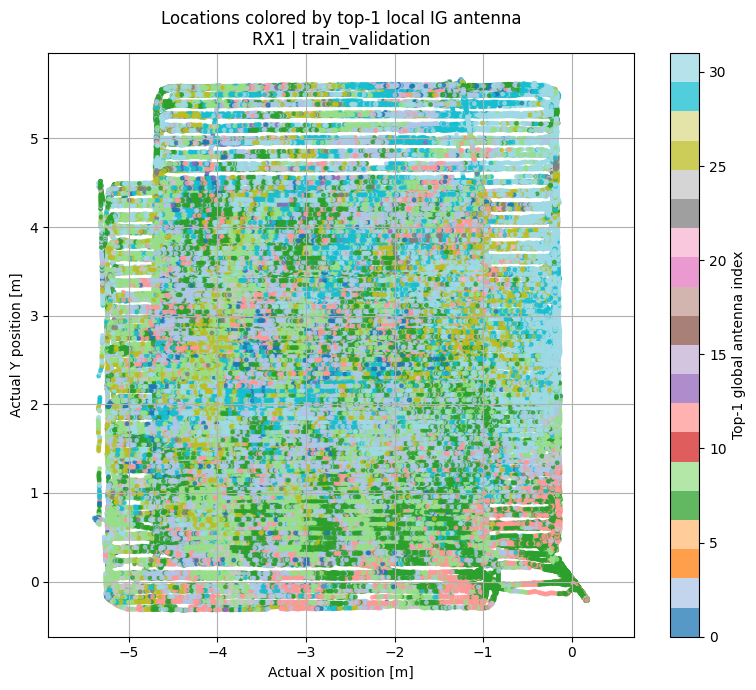

Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/RX1/locations_top1_local_ig_RX1_train_validation.png
Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/RX1/locations_top1_local_ig_RX1_test.png


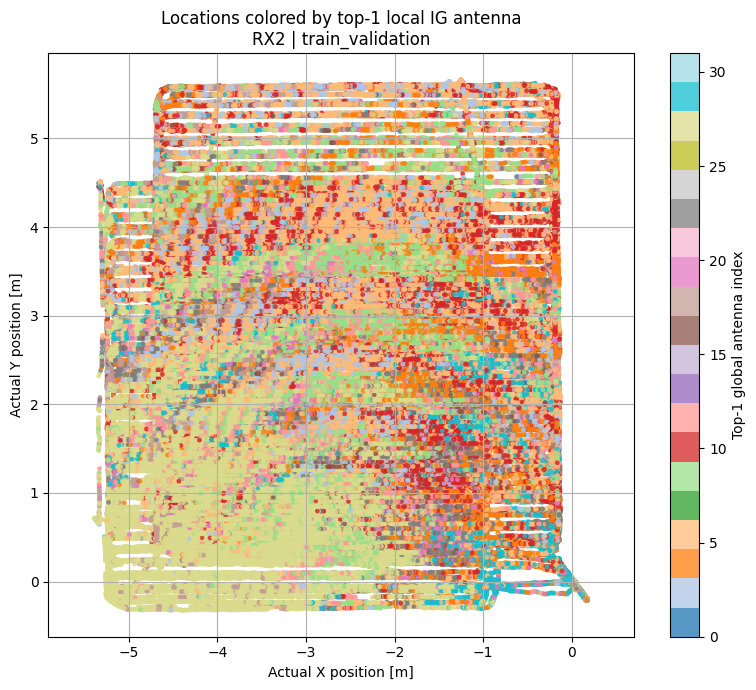

Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/RX2/locations_top1_local_ig_RX2_train_validation.png
Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/RX2/locations_top1_local_ig_RX2_test.png


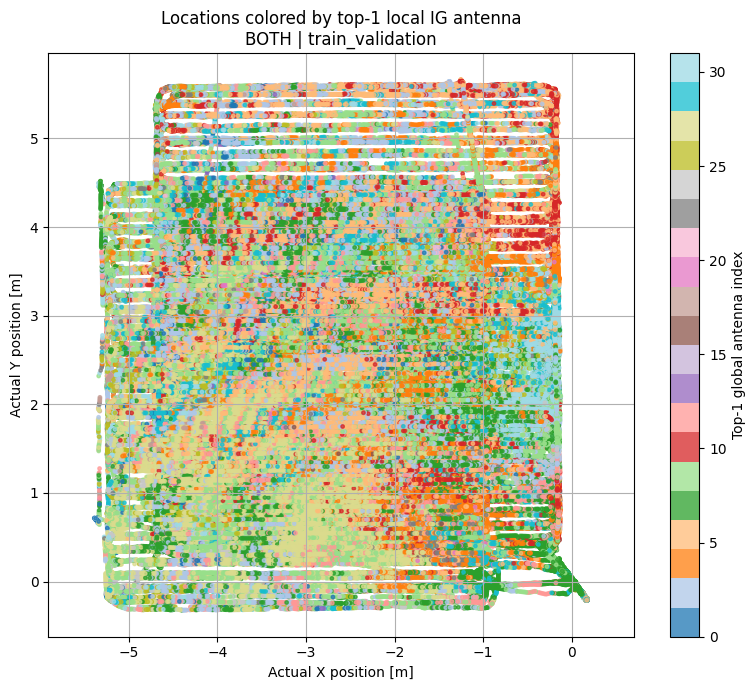

Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/BOTH/locations_top1_local_ig_BOTH_train_validation.png
Saved plot:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/plots/BOTH/locations_top1_local_ig_BOTH_test.png

LOCATION-WISE LOCAL IG RANKING COMPLETED
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Total antennas: 32
Output directory: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking

Combined CSV files:

RX1:
Train: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/location_wise_local_ig_train_RX1.csv
Validation: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/v

In [26]:
# ============================================================
# STREAMING LOCATION-WISE LOCAL IG ANTENNA RANKING REPORT
# SHARED MODEL FOR RX1, RX2, AND BOTH
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "train_run_datasets",
    "val_run_datasets",
    "test_run_datasets",
    "train_local_ig_runs",
    "val_local_ig_runs",
    "test_local_ig_runs",
    "train_files",
    "val_files",
    "test_files",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "EXPERIMENT_NAME",
    "RECEIVER_CONFIGS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Configuration
# ============================================================

SAVE_DIR = os.path.join(
    "/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "location_wise_local_ig_ranking"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)

TOP_K_TO_PRINT = 10
SHOW_PLOTS = True
CREATE_GLOBAL_REPORTS = True

RECEIVER_MODES = [
    "RX1",
    "RX2",
    "BOTH",
]

print("Experiment:", EXPERIMENT_NAME)
print("Total antennas:", NUM_TOTAL_ANTENNAS)
print("Output directory:", SAVE_DIR)
print("Receiver modes:", RECEIVER_MODES)


# ============================================================
# Extract metadata from one streaming run
# ============================================================

def extract_run_metadata_streaming(
    run_dataset,
    metadata_batch_size=1024
):
    position_batches = []
    time_batches = []
    rotation_batches = []
    snr_batches = []

    processed_samples = 0

    batched_dataset = (
        run_dataset
        .map(
            lambda sample: (
                sample["position"],
                sample["time"],
                sample["rotation"],
                sample["snr"],
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True
        )
        .batch(
            metadata_batch_size,
            drop_remainder=False
        )
        .prefetch(1)
    )

    for (
        position_batch,
        time_batch,
        rotation_batch,
        snr_batch
    ) in batched_dataset:

        position_batches.append(
            position_batch.numpy().astype(
                np.float32
            )
        )

        time_batches.append(
            time_batch.numpy().astype(
                np.float32
            )
        )

        rotation_batches.append(
            rotation_batch.numpy().astype(
                np.float32
            )
        )

        snr_batches.append(
            snr_batch.numpy().astype(
                np.float32
            )
        )

        processed_samples += int(
            position_batch.shape[0]
        )

    if not position_batches:
        raise RuntimeError(
            "No samples were found in the streaming run dataset."
        )

    positions = np.concatenate(
        position_batches,
        axis=0
    ).astype(np.float32)

    times = np.concatenate(
        time_batches,
        axis=0
    ).astype(np.float32)

    rotations = np.concatenate(
        rotation_batches,
        axis=0
    ).astype(np.float32)

    snr = np.concatenate(
        snr_batches,
        axis=0
    ).astype(np.float32)

    if positions.shape != (
        processed_samples,
        2
    ):
        raise RuntimeError(
            f"Unexpected position shape: {positions.shape}"
        )

    if times.shape != (
        processed_samples,
    ):
        raise RuntimeError(
            f"Unexpected time shape: {times.shape}"
        )

    if rotations.shape != (
        processed_samples,
    ):
        raise RuntimeError(
            f"Unexpected rotation shape: {rotations.shape}"
        )

    if snr.shape != (
        processed_samples,
        NUM_TOTAL_ANTENNAS
    ):
        raise RuntimeError(
            f"Unexpected SNR shape: {snr.shape}"
        )

    return {
        "position": positions,
        "time": times,
        "rotation": rotations,
        "snr": snr,
        "num_samples": processed_samples,
    }


# ============================================================
# Build one location-wise dataframe
# ============================================================

def build_location_wise_ranking_dataframe(
    source_name,
    receiver_mode,
    run_index,
    filename,
    metadata,
    local_ig_result
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            f"Unknown receiver mode: {receiver_mode}"
        )

    positions = metadata[
        "position"
    ]

    times = metadata[
        "time"
    ]

    rotations = metadata[
        "rotation"
    ]

    snr = metadata[
        "snr"
    ]

    importance = np.asarray(
        local_ig_result["importance"],
        dtype=np.float32
    )

    ranking_indices = np.asarray(
        local_ig_result["ranking_indices"],
        dtype=np.int32
    )

    active_ranking_indices = np.asarray(
        local_ig_result[
            "active_ranking_indices"
        ],
        dtype=np.int32
    )

    availability_mask = np.asarray(
        local_ig_result[
            "availability_mask"
        ],
        dtype=np.float32
    )

    receiver_mode_vector = np.asarray(
        local_ig_result[
            "receiver_mode_vector"
        ],
        dtype=np.float32
    )

    expected_availability_mask = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .astype(np.float32)
    )

    expected_mode_vector = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["mode_vector"]
        .numpy()
        .astype(np.float32)
    )

    expected_active_count = int(
        np.sum(
            expected_availability_mask >= 0.5
        )
    )

    num_samples = positions.shape[0]

    if importance.shape != (
        num_samples,
        NUM_TOTAL_ANTENNAS
    ):
        raise ValueError(
            f"Unexpected importance shape: {importance.shape}"
        )

    if ranking_indices.shape != (
        num_samples,
        NUM_TOTAL_ANTENNAS
    ):
        raise ValueError(
            f"Unexpected full ranking shape: "
            f"{ranking_indices.shape}"
        )

    if active_ranking_indices.shape != (
        num_samples,
        expected_active_count
    ):
        raise ValueError(
            f"Unexpected active ranking shape: "
            f"{active_ranking_indices.shape}"
        )

    if not np.array_equal(
        availability_mask,
        expected_availability_mask
    ):
        raise ValueError(
            "Availability mask mismatch."
        )

    if not np.array_equal(
        receiver_mode_vector,
        expected_mode_vector
    ):
        raise ValueError(
            "Receiver mode vector mismatch."
        )

    if not np.array_equal(
        active_ranking_indices,
        ranking_indices[
            :,
            :expected_active_count
        ]
    ):
        raise ValueError(
            "Active ranking does not match full ranking."
        )

    if not np.all(
        availability_mask[
            active_ranking_indices
        ] >= 0.5
    ):
        raise ValueError(
            "Inactive antennas appeared inside active ranking."
        )

    active_indices = np.where(
        availability_mask >= 0.5
    )[0].astype(np.int32)

    top1_indices = active_ranking_indices[
        :,
        0
    ]

    run_name = os.path.basename(
        filename
    )

    dataframe_data = {
        "source": np.repeat(
            source_name,
            num_samples
        ),
        "receiver_mode": np.repeat(
            receiver_mode,
            num_samples
        ),
        "run_index": np.repeat(
            run_index,
            num_samples
        ),
        "run_name": np.repeat(
            run_name,
            num_samples
        ),
        "sample_index": np.arange(
            num_samples,
            dtype=np.int32
        ),
        "timestamp": times,
        "actual_x": positions[:, 0],
        "actual_y": positions[:, 1],
        "rotation": rotations,
        "num_active_antennas": np.repeat(
            expected_active_count,
            num_samples
        ),
        "importance_sum_active": np.sum(
            importance[
                :,
                active_indices
            ],
            axis=1
        ),
        "importance_max_active": np.max(
            importance[
                :,
                active_indices
            ],
            axis=1
        ),
        "top1_global_index_zero_based":
            top1_indices,
        "top1_antenna": np.asarray(
            [
                f"CH{index:02d}"
                for index in top1_indices
            ]
        ),
        "top1_importance": np.take_along_axis(
            importance,
            top1_indices[:, None],
            axis=1
        )[:, 0],
        "top1_snr": np.take_along_axis(
            snr,
            top1_indices[:, None],
            axis=1
        )[:, 0],
    }

    for antenna_index in range(
        NUM_TOTAL_ANTENNAS
    ):
        antenna_name = (
            f"CH{antenna_index:02d}"
        )

        dataframe_data[
            f"{antenna_name}_available"
        ] = np.repeat(
            int(
                availability_mask[
                    antenna_index
                ] >= 0.5
            ),
            num_samples
        )

        dataframe_data[
            f"{antenna_name}_importance"
        ] = importance[
            :,
            antenna_index
        ]

        dataframe_data[
            f"{antenna_name}_snr"
        ] = snr[
            :,
            antenna_index
        ]

    for rank_index in range(
        expected_active_count
    ):
        ranked_indices = (
            active_ranking_indices[
                :,
                rank_index
            ]
        )

        dataframe_data[
            f"rank{rank_index + 1}_global_index_zero_based"
        ] = ranked_indices

        dataframe_data[
            f"rank{rank_index + 1}_antenna"
        ] = np.asarray(
            [
                f"CH{index:02d}"
                for index in ranked_indices
            ]
        )

        dataframe_data[
            f"rank{rank_index + 1}_score"
        ] = np.take_along_axis(
            importance,
            ranked_indices[:, None],
            axis=1
        )[:, 0]

        dataframe_data[
            f"rank{rank_index + 1}_snr"
        ] = np.take_along_axis(
            snr,
            ranked_indices[:, None],
            axis=1
        )[:, 0]

    ranking_dataframe = pd.DataFrame(
        dataframe_data
    )

    return ranking_dataframe


# ============================================================
# Save per-run and per-split reports
# ============================================================

def build_and_save_split_location_rankings(
    run_datasets,
    filenames,
    local_ig_results,
    source_name
):
    if len(run_datasets) != len(filenames):
        raise ValueError(
            f"{source_name}: dataset/file count mismatch."
        )

    result_metadata = {
        "RX1": [],
        "RX2": [],
        "BOTH": [],
    }

    split_csv_paths = {}

    metadata_cache = {}

    for run_index, run_dataset in enumerate(
        run_datasets
    ):
        metadata_cache[
            run_index
        ] = extract_run_metadata_streaming(
            run_dataset
        )

    for receiver_mode in RECEIVER_MODES:
        mode_results = local_ig_results[
            receiver_mode
        ]

        if len(mode_results) != len(
            run_datasets
        ):
            raise ValueError(
                f"{source_name}/{receiver_mode}: "
                "dataset/local-IG run count mismatch."
            )

        mode_dir = os.path.join(
            SAVE_DIR,
            source_name,
            receiver_mode
        )

        os.makedirs(
            mode_dir,
            exist_ok=True
        )

        split_csv_path = os.path.join(
            SAVE_DIR,
            source_name,
            (
                f"location_wise_local_ig_"
                f"{source_name}_{receiver_mode}.csv"
            )
        )

        if os.path.isfile(
            split_csv_path
        ):
            os.remove(
                split_csv_path
            )

        first_csv_write = True

        for run_index, (
            filename,
            local_ig_result
        ) in enumerate(
            zip(
                filenames,
                mode_results
            )
        ):
            print("\n" + "=" * 100)
            print(
                f"Processing {source_name} | "
                f"{receiver_mode} | "
                f"run {run_index}"
            )
            print("File:", filename)
            print("=" * 100)

            metadata = metadata_cache[
                run_index
            ]

            if (
                metadata["num_samples"]
                != local_ig_result[
                    "num_samples"
                ]
            ):
                raise ValueError(
                    f"{source_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "metadata/local-IG sample count mismatch."
                )

            ranking_dataframe = (
                build_location_wise_ranking_dataframe(
                    source_name=source_name,
                    receiver_mode=receiver_mode,
                    run_index=run_index,
                    filename=filename,
                    metadata=metadata,
                    local_ig_result=
                        local_ig_result
                )
            )

            run_stem = os.path.splitext(
                os.path.basename(filename)
            )[0]

            run_csv_path = os.path.join(
                mode_dir,
                (
                    f"{run_stem}_"
                    f"{receiver_mode}_"
                    f"location_wise_ranking.csv"
                )
            )

            run_npz_path = os.path.join(
                mode_dir,
                (
                    f"{run_stem}_"
                    f"{receiver_mode}_"
                    f"location_wise_ranking.npz"
                )
            )

            ranking_dataframe.to_csv(
                run_csv_path,
                index=False
            )

            ranking_dataframe.to_csv(
                split_csv_path,
                mode=(
                    "w"
                    if first_csv_write
                    else "a"
                ),
                header=first_csv_write,
                index=False
            )

            first_csv_write = False

            np.savez_compressed(
                run_npz_path,
                source=np.asarray(
                    source_name
                ),
                receiver_mode=np.asarray(
                    receiver_mode
                ),
                filename=np.asarray(
                    filename
                ),
                run_index=np.int32(
                    run_index
                ),
                positions=metadata[
                    "position"
                ],
                timestamps=metadata[
                    "time"
                ],
                rotations=metadata[
                    "rotation"
                ],
                snr=metadata[
                    "snr"
                ],
                importance=local_ig_result[
                    "importance"
                ].astype(np.float32),
                ranking_indices=local_ig_result[
                    "ranking_indices"
                ].astype(np.int32),
                active_ranking_indices=
                    local_ig_result[
                        "active_ranking_indices"
                    ].astype(np.int32),
                availability_mask=
                    local_ig_result[
                        "availability_mask"
                    ].astype(np.float32),
                receiver_mode_vector=
                    local_ig_result[
                        "receiver_mode_vector"
                    ].astype(np.float32),
                num_active_antennas=np.int32(
                    local_ig_result[
                        "active_ranking_indices"
                    ].shape[1]
                )
            )

            result_metadata[
                receiver_mode
            ].append({
                "source": source_name,
                "receiver_mode":
                    receiver_mode,
                "run_index": run_index,
                "filename": filename,
                "csv_path": run_csv_path,
                "npz_path": run_npz_path,
                "num_samples":
                    local_ig_result[
                        "num_samples"
                    ],
                "num_active_antennas":
                    local_ig_result[
                        "active_ranking_indices"
                    ].shape[1],
            })

            print(
                "Samples:",
                local_ig_result[
                    "num_samples"
                ]
            )

            print(
                "Active ranking shape:",
                local_ig_result[
                    "active_ranking_indices"
                ].shape
            )

            print("CSV:", run_csv_path)
            print("NPZ:", run_npz_path)

            del ranking_dataframe

        split_csv_paths[
            receiver_mode
        ] = split_csv_path

        print(
            f"\nCombined CSV "
            f"{source_name}/{receiver_mode}:"
        )
        print(split_csv_path)

    return (
        result_metadata,
        split_csv_paths
    )


train_location_ranking_runs, train_location_ranking_csvs = (
    build_and_save_split_location_rankings(
        run_datasets=train_run_datasets,
        filenames=train_files,
        local_ig_results=
            train_local_ig_runs,
        source_name="train"
    )
)

val_location_ranking_runs, val_location_ranking_csvs = (
    build_and_save_split_location_rankings(
        run_datasets=val_run_datasets,
        filenames=val_files,
        local_ig_results=
            val_local_ig_runs,
        source_name="validation"
    )
)

test_location_ranking_runs, test_location_ranking_csvs = (
    build_and_save_split_location_rankings(
        run_datasets=test_run_datasets,
        filenames=test_files,
        local_ig_results=
            test_local_ig_runs,
        source_name="test"
    )
)


# ============================================================
# Global reports
# Report only
# Never used by tracking
# ============================================================

def compute_global_summary_for_mode(
    local_ig_groups,
    receiver_mode,
    tag
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            f"Unknown receiver mode: {receiver_mode}"
        )

    availability_mask = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .astype(np.float32)
    )

    active_indices = np.where(
        availability_mask >= 0.5
    )[0].astype(np.int32)

    active_count = active_indices.shape[0]

    total_sum = np.zeros(
        (NUM_TOTAL_ANTENNAS,),
        dtype=np.float64
    )

    total_squared_sum = np.zeros(
        (NUM_TOTAL_ANTENNAS,),
        dtype=np.float64
    )

    total_top1_count = np.zeros(
        (NUM_TOTAL_ANTENNAS,),
        dtype=np.int64
    )

    all_min = np.full(
        (NUM_TOTAL_ANTENNAS,),
        np.inf,
        dtype=np.float64
    )

    all_max = np.full(
        (NUM_TOTAL_ANTENNAS,),
        -np.inf,
        dtype=np.float64
    )

    importance_arrays = []
    total_samples = 0

    for local_ig_group in local_ig_groups:
        run_results = local_ig_group[
            receiver_mode
        ]

        for run_result in run_results:
            importance = run_result[
                "importance"
            ].astype(np.float32)

            active_ranking = run_result[
                "active_ranking_indices"
            ].astype(np.int32)

            importance_arrays.append(
                importance
            )

            total_sum += np.sum(
                importance,
                axis=0,
                dtype=np.float64
            )

            total_squared_sum += np.sum(
                np.square(
                    importance
                ),
                axis=0,
                dtype=np.float64
            )

            top1_indices = active_ranking[
                :,
                0
            ]

            total_top1_count += np.bincount(
                top1_indices,
                minlength=NUM_TOTAL_ANTENNAS
            )

            all_min = np.minimum(
                all_min,
                np.min(
                    importance,
                    axis=0
                )
            )

            all_max = np.maximum(
                all_max,
                np.max(
                    importance,
                    axis=0
                )
            )

            total_samples += (
                importance.shape[0]
            )

    if total_samples == 0:
        raise RuntimeError(
            f"No importance samples found "
            f"for {tag}/{receiver_mode}."
        )

    mean_importance = (
        total_sum
        / float(total_samples)
    )

    variance = (
        total_squared_sum
        / float(total_samples)
        - np.square(
            mean_importance
        )
    )

    variance = np.maximum(
        variance,
        0.0
    )

    std_importance = np.sqrt(
        variance
    )

    combined_importance = np.concatenate(
        importance_arrays,
        axis=0
    )

    median_importance = np.median(
        combined_importance,
        axis=0
    )

    active_mean_importance = (
        mean_importance[
            active_indices
        ]
    )

    active_order = np.argsort(
        -active_mean_importance,
        kind="stable"
    )

    global_active_ranking = (
        active_indices[
            active_order
        ]
    )

    summary_dataframe = pd.DataFrame({
        "receiver_mode": np.repeat(
            receiver_mode,
            active_count
        ),
        "antenna": [
            f"CH{index:02d}"
            for index in active_indices
        ],
        "global_index_zero_based":
            active_indices,
        "mean_importance":
            mean_importance[
                active_indices
            ],
        "median_importance":
            median_importance[
                active_indices
            ],
        "std_importance":
            std_importance[
                active_indices
            ],
        "min_importance":
            all_min[
                active_indices
            ],
        "max_importance":
            all_max[
                active_indices
            ],
        "top1_count":
            total_top1_count[
                active_indices
            ],
        "top1_percent": (
            100.0
            * total_top1_count[
                active_indices
            ]
            / float(total_samples)
        ),
    })

    summary_dataframe = (
        summary_dataframe
        .sort_values(
            [
                "mean_importance",
                "top1_count"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

    ranking_dataframe = pd.DataFrame({
        "receiver_mode": np.repeat(
            receiver_mode,
            active_count
        ),
        "global_rank": np.arange(
            1,
            active_count + 1,
            dtype=np.int32
        ),
        "antenna": [
            f"CH{index:02d}"
            for index in global_active_ranking
        ],
        "global_index_zero_based":
            global_active_ranking,
        "global_importance":
            mean_importance[
                global_active_ranking
            ],
        "top1_count":
            total_top1_count[
                global_active_ranking
            ],
    })

    report_dir = os.path.join(
        SAVE_DIR,
        "global_reports",
        receiver_mode
    )

    os.makedirs(
        report_dir,
        exist_ok=True
    )

    summary_path = os.path.join(
        report_dir,
        (
            f"antenna_summary_"
            f"{tag}_{receiver_mode}.csv"
        )
    )

    ranking_path = os.path.join(
        report_dir,
        (
            f"global_ranking_"
            f"{tag}_{receiver_mode}.csv"
        )
    )

    summary_dataframe.to_csv(
        summary_path,
        index=False
    )

    ranking_dataframe.to_csv(
        ranking_path,
        index=False
    )

    print("\n" + "=" * 100)
    print(
        "Global report:",
        tag,
        "|",
        receiver_mode
    )
    print("Samples:", total_samples)
    print("Summary CSV:", summary_path)
    print("Ranking CSV:", ranking_path)

    try:
        display(
            ranking_dataframe
        )
    except NameError:
        print(
            ranking_dataframe.head(
                TOP_K_TO_PRINT
            )
        )

    del combined_importance

    return {
        "summary_dataframe":
            summary_dataframe,
        "ranking_dataframe":
            ranking_dataframe,
        "summary_path":
            summary_path,
        "ranking_path":
            ranking_path,
        "total_samples":
            total_samples,
    }


global_report_results = {}

if CREATE_GLOBAL_REPORTS:
    for receiver_mode in RECEIVER_MODES:
        global_report_results[
            receiver_mode
        ] = {
            "train_only":
                compute_global_summary_for_mode(
                    local_ig_groups=[
                        train_local_ig_runs
                    ],
                    receiver_mode=
                        receiver_mode,
                    tag="train_only"
                ),
            "train_validation":
                compute_global_summary_for_mode(
                    local_ig_groups=[
                        train_local_ig_runs,
                        val_local_ig_runs
                    ],
                    receiver_mode=
                        receiver_mode,
                    tag="train_validation"
                ),
            "test_only":
                compute_global_summary_for_mode(
                    local_ig_groups=[
                        test_local_ig_runs
                    ],
                    receiver_mode=
                        receiver_mode,
                    tag="test_only"
                ),
            "all_sources":
                compute_global_summary_for_mode(
                    local_ig_groups=[
                        train_local_ig_runs,
                        val_local_ig_runs,
                        test_local_ig_runs
                    ],
                    receiver_mode=
                        receiver_mode,
                    tag="all_sources"
                ),
        }


# ============================================================
# Nearest-location query
# ============================================================

def query_nearest_location_ranking(
    ranking_run_metadata,
    receiver_mode,
    x,
    y,
    top_k=10
):
    if receiver_mode not in RECEIVER_MODES:
        raise ValueError(
            f"receiver_mode must be one of "
            f"{RECEIVER_MODES}."
        )

    mode_metadata = ranking_run_metadata[
        receiver_mode
    ]

    if not mode_metadata:
        raise RuntimeError(
            f"No ranking runs are available "
            f"for {receiver_mode}."
        )

    target = np.asarray(
        [x, y],
        dtype=np.float32
    )

    best_distance = np.inf
    best_result = None

    for run_info in mode_metadata:
        with np.load(
            run_info["npz_path"],
            allow_pickle=True
        ) as loaded:

            positions = loaded[
                "positions"
            ].astype(np.float32)

            importance = loaded[
                "importance"
            ].astype(np.float32)

            active_ranking_indices = loaded[
                "active_ranking_indices"
            ].astype(np.int32)

            distances = np.sqrt(
                np.sum(
                    np.square(
                        positions
                        - target[None, :]
                    ),
                    axis=1
                )
            )

            local_sample_index = int(
                np.argmin(
                    distances
                )
            )

            local_distance = float(
                distances[
                    local_sample_index
                ]
            )

            if local_distance < best_distance:
                best_distance = local_distance

                best_result = {
                    "run_info":
                        run_info,
                    "sample_index":
                        local_sample_index,
                    "position":
                        positions[
                            local_sample_index
                        ],
                    "importance":
                        importance[
                            local_sample_index
                        ],
                    "active_ranking":
                        active_ranking_indices[
                            local_sample_index
                        ],
                }

    if best_result is None:
        raise RuntimeError(
            "No nearest-location result was found."
        )

    active_count = (
        best_result[
            "active_ranking"
        ].shape[0]
    )

    top_k = min(
        int(top_k),
        int(active_count)
    )

    query_records = []

    print("\n" + "=" * 80)
    print("Nearest location query")
    print("=" * 80)
    print("Receiver mode:", receiver_mode)
    print("Query:", x, y)
    print(
        "Run:",
        best_result[
            "run_info"
        ]["filename"]
    )
    print(
        "Sample index:",
        best_result[
            "sample_index"
        ]
    )
    print(
        "Actual position:",
        best_result[
            "position"
        ]
    )
    print(
        "Distance:",
        best_distance
    )
    print("-" * 80)

    for rank_position in range(
        top_k
    ):
        antenna_index = int(
            best_result[
                "active_ranking"
            ][rank_position]
        )

        score = float(
            best_result[
                "importance"
            ][antenna_index]
        )

        print(
            f"{rank_position + 1:02d}) "
            f"CH{antenna_index:02d} | "
            f"importance = {score:.8f}"
        )

        query_records.append({
            "receiver_mode":
                receiver_mode,
            "rank":
                rank_position + 1,
            "antenna":
                f"CH{antenna_index:02d}",
            "global_index_zero_based":
                antenna_index,
            "importance":
                score,
            "nearest_distance":
                best_distance,
            "sample_index":
                best_result[
                    "sample_index"
                ],
            "actual_x":
                float(
                    best_result[
                        "position"
                    ][0]
                ),
            "actual_y":
                float(
                    best_result[
                        "position"
                    ][1]
                ),
        })

    return pd.DataFrame(
        query_records
    )


example_query_results = {}

combined_train_val_metadata = {
    receiver_mode: (
        train_location_ranking_runs[
            receiver_mode
        ]
        + val_location_ranking_runs[
            receiver_mode
        ]
    )
    for receiver_mode in RECEIVER_MODES
}

for receiver_mode in RECEIVER_MODES:
    example_query_results[
        receiver_mode
    ] = query_nearest_location_ranking(
        ranking_run_metadata=
            combined_train_val_metadata,
        receiver_mode=receiver_mode,
        x=0.0,
        y=0.0,
        top_k=TOP_K_TO_PRINT
    )

    try:
        display(
            example_query_results[
                receiver_mode
            ]
        )
    except NameError:
        print(
            example_query_results[
                receiver_mode
            ]
        )


# ============================================================
# Top-1 location plots
# ============================================================

def plot_top1_locations_from_npz(
    ranking_run_metadata,
    receiver_mode,
    tag,
    show=True
):
    if receiver_mode not in RECEIVER_MODES:
        raise ValueError(
            f"Unknown receiver mode: "
            f"{receiver_mode}"
        )

    mode_metadata = ranking_run_metadata[
        receiver_mode
    ]

    if not mode_metadata:
        raise RuntimeError(
            f"No plot data found for "
            f"{receiver_mode}."
        )

    plt.figure(
        figsize=(8, 7)
    )

    for run_info in mode_metadata:
        with np.load(
            run_info["npz_path"],
            allow_pickle=True
        ) as loaded:

            positions = loaded[
                "positions"
            ].astype(np.float32)

            active_ranking_indices = loaded[
                "active_ranking_indices"
            ].astype(np.int32)

            plt.scatter(
                positions[:, 0],
                positions[:, 1],
                c=active_ranking_indices[
                    :,
                    0
                ],
                s=6,
                cmap="tab20",
                vmin=0,
                vmax=max(
                    NUM_TOTAL_ANTENNAS - 1,
                    1
                ),
                alpha=0.75
            )

    plt.xlabel(
        "Actual X position [m]"
    )

    plt.ylabel(
        "Actual Y position [m]"
    )

    plt.title(
        (
            f"Locations colored by "
            f"top-1 local IG antenna\n"
            f"{receiver_mode} | {tag}"
        )
    )

    plt.axis(
        "equal"
    )

    plt.grid(
        True
    )

    colorbar = plt.colorbar()

    colorbar.set_label(
        "Top-1 global antenna index"
    )

    plt.tight_layout()

    plot_dir = os.path.join(
        SAVE_DIR,
        "plots",
        receiver_mode
    )

    os.makedirs(
        plot_dir,
        exist_ok=True
    )

    plot_path = os.path.join(
        plot_dir,
        (
            f"locations_top1_local_ig_"
            f"{receiver_mode}_{tag}.png"
        )
    )

    plt.savefig(
        plot_path,
        dpi=200,
        bbox_inches="tight"
    )

    if show:
        plt.show()

    plt.close()

    print("Saved plot:")
    print(plot_path)

    return plot_path


top1_plot_paths = {
    "train_validation": {},
    "test": {},
}

combined_test_metadata = {
    receiver_mode:
        test_location_ranking_runs[
            receiver_mode
        ]
    for receiver_mode in RECEIVER_MODES
}

for receiver_mode in RECEIVER_MODES:
    top1_plot_paths[
        "train_validation"
    ][receiver_mode] = (
        plot_top1_locations_from_npz(
            ranking_run_metadata=
                combined_train_val_metadata,
            receiver_mode=receiver_mode,
            tag="train_validation",
            show=SHOW_PLOTS
        )
    )

    top1_plot_paths[
        "test"
    ][receiver_mode] = (
        plot_top1_locations_from_npz(
            ranking_run_metadata=
                combined_test_metadata,
            receiver_mode=receiver_mode,
            tag="test",
            show=False
        )
    )


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 100)
print(
    "LOCATION-WISE LOCAL IG RANKING COMPLETED"
)
print("=" * 100)

print("Experiment:", EXPERIMENT_NAME)
print(
    "Total antennas:",
    NUM_TOTAL_ANTENNAS
)
print(
    "Output directory:",
    SAVE_DIR
)

print("\nCombined CSV files:")

for receiver_mode in RECEIVER_MODES:
    print(
        f"\n{receiver_mode}:"
    )

    print(
        "Train:",
        train_location_ranking_csvs[
            receiver_mode
        ]
    )

    print(
        "Validation:",
        val_location_ranking_csvs[
            receiver_mode
        ]
    )

    print(
        "Test:",
        test_location_ranking_csvs[
            receiver_mode
        ]
    )

print("\nGenerated metadata objects:")
print("train_location_ranking_runs")
print("val_location_ranking_runs")
print("test_location_ranking_runs")

print("\nTracking input source:")
print(
    'local_ig_result["active_ranking_indices"][t]'
)

print(
    "\nGlobal rankings are report-only "
    "and must not be used by tracking."
)

In [24]:
import os
import shutil

LOCATION_RANKING_DIR = os.path.join(
    "/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "location_wise_local_ig_ranking"
)

if os.path.isdir(LOCATION_RANKING_DIR):
    shutil.rmtree(LOCATION_RANKING_DIR)
    print("Deleted:")
    print(LOCATION_RANKING_DIR)
else:
    print("Directory does not exist.")

os.makedirs(
    LOCATION_RANKING_DIR,
    exist_ok=True
)

print("Location-ranking output directory reset.")

Deleted:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking
Location-ranking output directory reset.


In [27]:
# ============================================================
# DIAGNOSE RECEIVER_MODE MISMATCH IN BOTH RANKING CSV
# ============================================================

import os
import pandas as pd


required_objects = [
    "EXPERIMENT_NAME",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


ranking_csv_path = os.path.join(
    "/content/drive/MyDrive/"
    "DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "location_wise_local_ig_ranking",
    "train",
    "location_wise_local_ig_train_BOTH.csv"
)


if not os.path.isfile(
    ranking_csv_path
):
    raise FileNotFoundError(
        f"Ranking CSV was not found:\n{ranking_csv_path}"
    )


dataframe = pd.read_csv(
    ranking_csv_path,
    low_memory=False
)


print("=" * 100)
print("BOTH RANKING CSV DIAGNOSTIC")
print("=" * 100)

print("\nCSV path:")
print(ranking_csv_path)

print("\nDataFrame shape:")
print(dataframe.shape)

print("\nNumber of columns:")
print(len(dataframe.columns))

print("\nFirst 30 column names:")
print(
    dataframe.columns[:30].tolist()
)

print("\nLast 30 column names:")
print(
    dataframe.columns[-30:].tolist()
)


if "receiver_mode" not in dataframe.columns:
    raise RuntimeError(
        "The receiver_mode column is missing from the CSV."
    )


receiver_mode_as_text = (
    dataframe["receiver_mode"]
    .astype(str)
    .str.strip()
)


print("\nreceiver_mode value counts:")
print(
    receiver_mode_as_text.value_counts(
        dropna=False
    )
)


invalid_mask = (
    receiver_mode_as_text != "BOTH"
)

invalid_indices = dataframe.index[
    invalid_mask
].to_numpy()


print("\nNumber of invalid receiver_mode rows:")
print(
    len(invalid_indices)
)

print("\nFirst invalid row indices:")
print(
    invalid_indices[:30].tolist()
)


if len(invalid_indices) > 0:
    columns_to_show = []

    candidate_columns = [
        "run_id",
        "sample_index",
        "location_index",
        "position_x",
        "position_y",
        "timestamp",
        "receiver_mode",
        "filename",
    ]

    for column_name in candidate_columns:
        if column_name in dataframe.columns:
            columns_to_show.append(
                column_name
            )

    if not columns_to_show:
        columns_to_show = dataframe.columns[
            :min(
                20,
                len(dataframe.columns)
            )
        ].tolist()

    print("\nInvalid rows:")
    print(
        dataframe.loc[
            invalid_indices[:30],
            columns_to_show
        ].to_string()
    )

    first_invalid_index = int(
        invalid_indices[0]
    )

    start_index = max(
        0,
        first_invalid_index - 3
    )

    end_index = min(
        len(dataframe),
        first_invalid_index + 4
    )

    print("\nRows around the first invalid row:")
    print(
        dataframe.iloc[
            start_index:end_index
        ][
            columns_to_show
        ].to_string()
    )


print("\nRows with missing values:")
print(
    int(
        dataframe.isna().any(
            axis=1
        ).sum()
    )
)

print("\nCompletely duplicated rows:")
print(
    int(
        dataframe.duplicated().sum()
    )
)

print("\nDiagnostic completed.")

BOTH RANKING CSV DIAGNOSTIC

CSV path:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/location_wise_local_ig_train_BOTH.csv

DataFrame shape:
(118085, 240)

Number of columns:
240

First 30 column names:
['source', 'receiver_mode', 'run_index', 'run_name', 'sample_index', 'timestamp', 'actual_x', 'actual_y', 'rotation', 'num_active_antennas', 'importance_sum_active', 'importance_max_active', 'top1_global_index_zero_based', 'top1_antenna', 'top1_importance', 'top1_snr', 'CH00_available', 'CH00_importance', 'CH00_snr', 'CH01_available', 'CH01_importance', 'CH01_snr', 'CH02_available', 'CH02_importance', 'CH02_snr', 'CH03_available', 'CH03_importance', 'CH03_snr', 'CH04_available', 'CH04_importance']

Last 30 column names:
['rank25_score', 'rank25_snr', 'rank26_global_index_zero_based', 'rank26_antenna', 'rank26_score', 'rank26_snr', 'rank27_global_index_zero_based', 'rank27_antenna', 'rank27_score', '

In [30]:
# ============================================================
# LOAD LOCATION-WISE LOCAL IG RANKING OUTPUTS
# FOR RX1, RX2, AND BOTH
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "EXPERIMENT_NAME",
    "NUM_TOTAL_ANTENNAS",
    "RECEIVER_CONFIGS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Configuration
# ============================================================

RANKING_DIR = os.path.join(
    "/content/drive/MyDrive/"
    "DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "location_wise_local_ig_ranking"
)

RECEIVER_MODES = [
    "RX1",
    "RX2",
    "BOTH",
]

SPLIT_NAMES = [
    "train",
    "validation",
    "test",
]


# ============================================================
# Expected files
# ============================================================

location_ranking_files = {
    split_name: {
        receiver_mode: os.path.join(
            RANKING_DIR,
            split_name,
            (
                f"location_wise_local_ig_"
                f"{split_name}_{receiver_mode}.csv"
            )
        )
        for receiver_mode in RECEIVER_MODES
    }
    for split_name in SPLIT_NAMES
}


# ============================================================
# Load all ranking files
# ============================================================

loaded_location_rankings = {
    split_name: {}
    for split_name in SPLIT_NAMES
}


print("Ranking directory:")
print(RANKING_DIR)

print(
    "\nLoading location-wise local IG ranking files:"
)

print("-" * 100)


for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        file_path = location_ranking_files[
            split_name
        ][receiver_mode]

        if not os.path.isfile(
            file_path
        ):
            raise FileNotFoundError(
                "Location-wise local IG ranking file "
                f"was not found:\n{file_path}"
            )

        dataframe = pd.read_csv(
            file_path,
            low_memory=False
        )

        if dataframe.empty:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "ranking dataframe is empty."
            )

        loaded_location_rankings[
            split_name
        ][receiver_mode] = dataframe

        print(
            f"{split_name:10s} | "
            f"{receiver_mode:4s} | "
            f"LOADED | "
            f"shape={dataframe.shape}"
        )

        print(file_path)


print("-" * 100)


# ============================================================
# Convenient dataframe aliases
# ============================================================

location_ranking_train_rx1_df = (
    loaded_location_rankings[
        "train"
    ]["RX1"]
)

location_ranking_train_rx2_df = (
    loaded_location_rankings[
        "train"
    ]["RX2"]
)

location_ranking_train_both_df = (
    loaded_location_rankings[
        "train"
    ]["BOTH"]
)


location_ranking_validation_rx1_df = (
    loaded_location_rankings[
        "validation"
    ]["RX1"]
)

location_ranking_validation_rx2_df = (
    loaded_location_rankings[
        "validation"
    ]["RX2"]
)

location_ranking_validation_both_df = (
    loaded_location_rankings[
        "validation"
    ]["BOTH"]
)


location_ranking_test_rx1_df = (
    loaded_location_rankings[
        "test"
    ]["RX1"]
)

location_ranking_test_rx2_df = (
    loaded_location_rankings[
        "test"
    ]["RX2"]
)

location_ranking_test_both_df = (
    loaded_location_rankings[
        "test"
    ]["BOTH"]
)


# ============================================================
# Validate base columns
# ============================================================

base_required_columns = [
    "source",
    "receiver_mode",
    "run_index",
    "run_name",
    "sample_index",
    "timestamp",
    "actual_x",
    "actual_y",
    "rotation",
    "num_active_antennas",
    "importance_sum_active",
    "importance_max_active",
    "top1_global_index_zero_based",
    "top1_antenna",
    "top1_importance",
    "top1_snr",
]


for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        missing_columns = [
            column_name
            for column_name in base_required_columns
            if column_name not in dataframe.columns
        ]

        if missing_columns:
            raise KeyError(
                f"{split_name}/{receiver_mode} "
                "is missing required columns: "
                f"{missing_columns}"
            )


print(
    "\nAll required base columns were found."
)


# ============================================================
# Normalize and validate metadata columns
# ============================================================

numeric_metadata_columns = [
    "run_index",
    "sample_index",
    "timestamp",
    "actual_x",
    "actual_y",
    "rotation",
    "num_active_antennas",
    "importance_sum_active",
    "importance_max_active",
    "top1_global_index_zero_based",
    "top1_importance",
    "top1_snr",
]


for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        dataframe["receiver_mode"] = (
            dataframe["receiver_mode"]
            .astype(str)
            .str.strip()
        )

        dataframe["run_name"] = (
            dataframe["run_name"]
            .astype(str)
            .str.strip()
        )

        for column_name in numeric_metadata_columns:
            converted_values = pd.to_numeric(
                dataframe[column_name],
                errors="coerce"
            )

            invalid_mask = converted_values.isna()

            if invalid_mask.any():
                invalid_indices = dataframe.index[
                    invalid_mask
                ].tolist()

                raise ValueError(
                    f"{split_name}/{receiver_mode}: "
                    f"column {column_name} contains "
                    "invalid numeric values at rows "
                    f"{invalid_indices[:20]}."
                )

            dataframe[column_name] = converted_values


# ============================================================
# Validate receiver modes
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        unique_receiver_modes = set(
            dataframe[
                "receiver_mode"
            ].unique()
        )

        if unique_receiver_modes != {
            receiver_mode
        }:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "receiver_mode column mismatch. "
                f"Found: {sorted(unique_receiver_modes)}"
            )


print(
    "Receiver-mode metadata is valid."
)


# ============================================================
# Validate run and sample indices
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        run_index_values = dataframe[
            "run_index"
        ].to_numpy(
            dtype=np.float64
        )

        sample_index_values = dataframe[
            "sample_index"
        ].to_numpy(
            dtype=np.float64
        )

        run_indices_are_integer = np.all(
            np.isclose(
                run_index_values,
                np.round(
                    run_index_values
                )
            )
        )

        if not run_indices_are_integer:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "run_index contains non-integer values."
            )

        sample_indices_are_integer = np.all(
            np.isclose(
                sample_index_values,
                np.round(
                    sample_index_values
                )
            )
        )

        if not sample_indices_are_integer:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "sample_index contains non-integer values."
            )

        dataframe["run_index"] = (
            dataframe["run_index"]
            .round()
            .astype(np.int64)
        )

        dataframe["sample_index"] = (
            dataframe["sample_index"]
            .round()
            .astype(np.int64)
        )

        if (
            dataframe["run_index"] < 0
        ).any():
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "run_index contains negative values."
            )

        if (
            dataframe["sample_index"] < 0
        ).any():
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "sample_index contains negative values."
            )


print(
    "Run and sample index metadata is valid."
)


# ============================================================
# Validate active antenna counts
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        availability_mask = RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]

        if hasattr(
            availability_mask,
            "numpy"
        ):
            availability_mask = (
                availability_mask.numpy()
            )

        expected_active_count = int(
            np.sum(
                availability_mask
            )
        )

        active_count_values = dataframe[
            "num_active_antennas"
        ].to_numpy(
            dtype=np.float64
        )

        active_counts_are_integer = np.all(
            np.isclose(
                active_count_values,
                np.round(
                    active_count_values
                )
            )
        )

        if not active_counts_are_integer:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "num_active_antennas contains "
                "non-integer values."
            )

        unique_active_counts = set(
            np.round(
                active_count_values
            ).astype(
                np.int64
            ).tolist()
        )

        if unique_active_counts != {
            expected_active_count
        }:
            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "active antenna count mismatch. "
                f"Expected {expected_active_count}, "
                f"found {sorted(unique_active_counts)}"
            )

        dataframe[
            "num_active_antennas"
        ] = (
            dataframe[
                "num_active_antennas"
            ]
            .round()
            .astype(np.int64)
        )


print(
    "Active antenna counts are valid."
)


# ============================================================
# Validate ranking columns
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        availability_mask = RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]

        if hasattr(
            availability_mask,
            "numpy"
        ):
            availability_mask = (
                availability_mask.numpy()
            )

        expected_active_count = int(
            np.sum(
                availability_mask
            )
        )

        for rank_index in range(
            expected_active_count
        ):
            rank_number = (
                rank_index + 1
            )

            ranking_column = (
                f"rank{rank_number}_"
                "global_index_zero_based"
            )

            antenna_column = (
                f"rank{rank_number}_antenna"
            )

            score_column = (
                f"rank{rank_number}_score"
            )

            snr_column = (
                f"rank{rank_number}_snr"
            )

            required_rank_columns = [
                ranking_column,
                antenna_column,
                score_column,
                snr_column,
            ]

            missing_rank_columns = [
                column_name
                for column_name
                in required_rank_columns
                if column_name
                not in dataframe.columns
            ]

            if missing_rank_columns:
                raise KeyError(
                    f"{split_name}/{receiver_mode} "
                    "is missing ranking columns: "
                    f"{missing_rank_columns}"
                )


print(
    "All required local-ranking columns "
    "were found."
)


# ============================================================
# Validate finite metadata values
# ============================================================

finite_columns = [
    "timestamp",
    "actual_x",
    "actual_y",
    "rotation",
    "importance_sum_active",
    "importance_max_active",
    "top1_global_index_zero_based",
    "top1_importance",
    "top1_snr",
]


for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        for column_name in finite_columns:
            column_values = dataframe[
                column_name
            ].to_numpy(
                dtype=np.float64
            )

            if not np.isfinite(
                column_values
            ).all():
                invalid_indices = dataframe.index[
                    ~np.isfinite(
                        column_values
                    )
                ].tolist()

                raise ValueError(
                    f"{split_name}/{receiver_mode}: "
                    f"column {column_name} contains "
                    "non-finite values at rows "
                    f"{invalid_indices[:20]}."
                )


print(
    "Finite metadata validation passed."
)


# ============================================================
# Validate sample ordering within each run
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        grouped = dataframe.groupby(
            [
                "run_index",
                "run_name",
            ],
            sort=False,
            dropna=False
        )

        for (
            run_index,
            run_name
        ), run_dataframe in grouped:
            sample_indices = run_dataframe[
                "sample_index"
            ].to_numpy(
                dtype=np.int64
            )

            if len(
                sample_indices
            ) == 0:
                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "run contains no samples."
                )

            if len(
                np.unique(
                    sample_indices
                )
            ) != len(
                sample_indices
            ):
                duplicated_values = (
                    run_dataframe.loc[
                        run_dataframe[
                            "sample_index"
                        ].duplicated(
                            keep=False
                        ),
                        "sample_index"
                    ]
                    .unique()
                    .tolist()
                )

                raise ValueError(
                    f"{split_name}/{receiver_mode}/"
                    f"run {run_index}: "
                    "duplicate sample_index values "
                    f"were found: "
                    f"{duplicated_values[:20]}"
                )

            if len(
                sample_indices
            ) > 1:
                sample_differences = np.diff(
                    sample_indices
                )

                if not np.all(
                    sample_differences > 0
                ):
                    invalid_positions = np.flatnonzero(
                        sample_differences <= 0
                    )

                    raise ValueError(
                        f"{split_name}/{receiver_mode}/"
                        f"run {run_index}: "
                        "sample_index values are not "
                        "strictly increasing. "
                        "Invalid transitions at local "
                        "positions "
                        f"{invalid_positions[:20].tolist()}."
                    )


print(
    "Sample ordering is valid for all "
    "splits and receiver modes."
)


# ============================================================
# Validate run/sample key uniqueness
# ============================================================

for split_name in SPLIT_NAMES:
    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        duplicate_key_mask = dataframe.duplicated(
            subset=[
                "run_index",
                "run_name",
                "sample_index",
            ],
            keep=False
        )

        if duplicate_key_mask.any():
            duplicate_rows = dataframe.loc[
                duplicate_key_mask,
                [
                    "run_index",
                    "run_name",
                    "sample_index",
                ]
            ]

            raise ValueError(
                f"{split_name}/{receiver_mode}: "
                "duplicate run/sample keys found:\n"
                f"{duplicate_rows.head(20).to_string()}"
            )


print(
    "Run/sample keys are unique."
)


# ============================================================
# Summary
# ============================================================

print("\nLoaded dataframe summary:")
print("-" * 100)


for split_name in SPLIT_NAMES:
    print(
        f"\n{split_name.upper()}:"
    )

    for receiver_mode in RECEIVER_MODES:
        dataframe = loaded_location_rankings[
            split_name
        ][receiver_mode]

        number_of_runs = dataframe[
            [
                "run_index",
                "run_name",
            ]
        ].drop_duplicates().shape[0]

        print(
            f"{receiver_mode}: "
            f"shape={dataframe.shape} | "
            f"runs={number_of_runs} | "
            "active antennas="
            f"{dataframe['num_active_antennas'].iloc[0]}"
        )


# ============================================================
# Preview
# ============================================================

for receiver_mode in RECEIVER_MODES:
    print(
        f"\nTrain location-wise ranking "
        f"for {receiver_mode}:"
    )

    display(
        loaded_location_rankings[
            "train"
        ][receiver_mode].head()
    )


print(
    "\nLocation-wise local IG ranking "
    "outputs loaded successfully."
)

print(
    "These CSV files are report outputs only."
)

print(
    "Tracking must use cached or in-memory "
    "active_ranking_indices arrays."
)

Ranking directory:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking

Loading location-wise local IG ranking files:
----------------------------------------------------------------------------------------------------
train      | RX1  | LOADED | shape=(118085, 176)
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/location_wise_local_ig_train_RX1.csv
train      | RX2  | LOADED | shape=(118085, 176)
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/location_wise_local_ig_train_RX2.csv
train      | BOTH | LOADED | shape=(118085, 240)
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/train/location_wise_local_ig_train_BOTH.csv
validation | RX1  | LOADED | shape=(2220

,source,receiver_mode,run_index,run_name,sample_index,timestamp,actual_x,actual_y,rotation,num_active_antennas,...,rank14_score,rank14_snr,rank15_global_index_zero_based,rank15_antenna,rank15_score,rank15_snr,rank16_global_index_zero_based,rank16_antenna,rank16_score,rank16_snr
0,train,RX1,0,dichasus-0d51.tfrecords,0,3329.688,0.16952,-0.20411,-0.921,16,...,0.021564,15.811147,21,CH21,0.020344,12.800950,0,CH00,0.017833,10.211757
1,train,RX1,0,dichasus-0d51.tfrecords,1,3329.736,0.16952,-0.20411,-0.921,16,...,0.022991,7.974836,21,CH21,0.022175,12.114047,0,CH00,0.017819,8.766484
2,train,RX1,0,dichasus-0d51.tfrecords,2,3329.832,0.16952,-0.20411,-0.921,16,...,0.019132,11.478413,13,CH13,0.017396,15.678508,0,CH00,0.014023,10.227518
3,train,RX1,0,dichasus-0d51.tfrecords,3,3329.880,0.16952,-0.20411,-0.921,16,...,0.023784,10.473570,13,CH13,0.019755,16.805150,0,CH00,0.016889,9.369270
4,train,RX1,0,dichasus-0d51.tfrecords,4,3326.616,0.16952,-0.20411,-0.921,16,...,0.020525,5.241115,21,CH21,0.018635,11.361445,0,CH00,0.016266,9.930921



Train location-wise ranking for RX2:


,source,receiver_mode,run_index,run_name,sample_index,timestamp,actual_x,actual_y,rotation,num_active_antennas,...,rank14_score,rank14_snr,rank15_global_index_zero_based,rank15_antenna,rank15_score,rank15_snr,rank16_global_index_zero_based,rank16_antenna,rank16_score,rank16_snr
0,train,RX2,0,dichasus-0d51.tfrecords,0,3329.688,0.16952,-0.20411,-0.921,16,...,0.011590,6.327395,18,CH18,0.011495,10.299461,17,CH17,0.010076,12.566341
1,train,RX2,0,dichasus-0d51.tfrecords,1,3329.736,0.16952,-0.20411,-0.921,16,...,0.012067,5.734273,18,CH18,0.010073,11.724118,17,CH17,0.008725,11.201093
2,train,RX2,0,dichasus-0d51.tfrecords,2,3329.832,0.16952,-0.20411,-0.921,16,...,0.011357,2.921136,18,CH18,0.010266,10.410121,17,CH17,0.008946,14.923944
3,train,RX2,0,dichasus-0d51.tfrecords,3,3329.880,0.16952,-0.20411,-0.921,16,...,0.010305,5.047422,17,CH17,0.010037,14.698145,18,CH18,0.009936,9.329213
4,train,RX2,0,dichasus-0d51.tfrecords,4,3326.616,0.16952,-0.20411,-0.921,16,...,0.014054,13.506825,18,CH18,0.012431,13.689107,20,CH20,0.010902,-9.450397



Train location-wise ranking for BOTH:


,source,receiver_mode,run_index,run_name,sample_index,timestamp,actual_x,actual_y,rotation,num_active_antennas,...,rank30_score,rank30_snr,rank31_global_index_zero_based,rank31_antenna,rank31_score,rank31_snr,rank32_global_index_zero_based,rank32_antenna,rank32_score,rank32_snr
0,train,BOTH,0,dichasus-0d51.tfrecords,0,3329.688,0.16952,-0.20411,-0.921,32,...,0.008696,6.327395,18,CH18,0.006594,10.299461,17,CH17,0.006169,12.566341
1,train,BOTH,0,dichasus-0d51.tfrecords,1,3329.736,0.16952,-0.20411,-0.921,32,...,0.009753,12.114047,17,CH17,0.008225,11.201093,18,CH18,0.008011,11.724118
2,train,BOTH,0,dichasus-0d51.tfrecords,2,3329.832,0.16952,-0.20411,-0.921,32,...,0.007853,2.921136,18,CH18,0.006633,10.410121,17,CH17,0.004636,14.923944
3,train,BOTH,0,dichasus-0d51.tfrecords,3,3329.880,0.16952,-0.20411,-0.921,32,...,0.008754,5.047422,18,CH18,0.008658,9.329213,17,CH17,0.006254,14.698145
4,train,BOTH,0,dichasus-0d51.tfrecords,4,3326.616,0.16952,-0.20411,-0.921,32,...,0.008414,11.361445,17,CH17,0.007335,13.506825,20,CH20,0.006470,-9.450397



Location-wise local IG ranking outputs loaded successfully.
These CSV files are report outputs only.
Tracking must use cached or in-memory active_ranking_indices arrays.


In [31]:
# ============================================================
# QUERY NEAREST VALIDATION LOCATION USING LOCAL IG RANKING
# ============================================================

query_results = {}

for receiver_mode in [
    "RX1",
    "RX2",
    "BOTH",
]:
    expected_active_count = int(
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .sum()
    )

    query_df = query_nearest_location_ranking(
        ranking_run_metadata=
            val_location_ranking_runs,
        receiver_mode=receiver_mode,
        x=1.0,
        y=3.0,
        top_k=expected_active_count
    )

    query_results[
        receiver_mode
    ] = query_df

    print(
        f"\nNearest validation ranking for "
        f"{receiver_mode}:"
    )

    display(
        query_df
    )


Nearest location query
Receiver mode: RX1
Query: 1.0 3.0
Run: dichasus-0d56.tfrecords
Sample index: 11509
Actual position: [-0.18556935  2.977482  ]
Distance: 1.1857831478118896
--------------------------------------------------------------------------------
01) CH30 | importance = 0.07112934
02) CH31 | importance = 0.06575613
03) CH29 | importance = 0.05161898
04) CH26 | importance = 0.04792645
05) CH07 | importance = 0.04444439
06) CH25 | importance = 0.03863598
07) CH03 | importance = 0.03329720
08) CH13 | importance = 0.02925288
09) CH08 | importance = 0.02781234
10) CH24 | importance = 0.02634904
11) CH21 | importance = 0.02571749
12) CH00 | importance = 0.02509672
13) CH01 | importance = 0.02506707
14) CH12 | importance = 0.02485685
15) CH15 | importance = 0.01667641
16) CH22 | importance = 0.01537063

Nearest validation ranking for RX1:


,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,RX1,1,CH30,30,0.071129,1.185783,11509,-0.185569,2.977482
1,RX1,2,CH31,31,0.065756,1.185783,11509,-0.185569,2.977482
2,RX1,3,CH29,29,0.051619,1.185783,11509,-0.185569,2.977482
3,RX1,4,CH26,26,0.047926,1.185783,11509,-0.185569,2.977482
4,RX1,5,CH07,7,0.044444,1.185783,11509,-0.185569,2.977482
5,RX1,6,CH25,25,0.038636,1.185783,11509,-0.185569,2.977482
6,RX1,7,CH03,3,0.033297,1.185783,11509,-0.185569,2.977482
7,RX1,8,CH13,13,0.029253,1.185783,11509,-0.185569,2.977482
8,RX1,9,CH08,8,0.027812,1.185783,11509,-0.185569,2.977482
9,RX1,10,CH24,24,0.026349,1.185783,11509,-0.185569,2.977482



Nearest location query
Receiver mode: RX2
Query: 1.0 3.0
Run: dichasus-0d56.tfrecords
Sample index: 11509
Actual position: [-0.18556935  2.977482  ]
Distance: 1.1857831478118896
--------------------------------------------------------------------------------
01) CH05 | importance = 0.07613510
02) CH06 | importance = 0.07474075
03) CH10 | importance = 0.06444702
04) CH09 | importance = 0.06318048
05) CH02 | importance = 0.05948415
06) CH04 | importance = 0.05572750
07) CH11 | importance = 0.05488241
08) CH28 | importance = 0.05258700
09) CH14 | importance = 0.05050905
10) CH23 | importance = 0.04880486
11) CH17 | importance = 0.03860030
12) CH19 | importance = 0.03749500
13) CH27 | importance = 0.03732884
14) CH20 | importance = 0.03187376
15) CH18 | importance = 0.02620104
16) CH16 | importance = 0.02311978

Nearest validation ranking for RX2:


,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,RX2,1,CH05,5,0.076135,1.185783,11509,-0.185569,2.977482
1,RX2,2,CH06,6,0.074741,1.185783,11509,-0.185569,2.977482
2,RX2,3,CH10,10,0.064447,1.185783,11509,-0.185569,2.977482
3,RX2,4,CH09,9,0.063180,1.185783,11509,-0.185569,2.977482
4,RX2,5,CH02,2,0.059484,1.185783,11509,-0.185569,2.977482
5,RX2,6,CH04,4,0.055728,1.185783,11509,-0.185569,2.977482
6,RX2,7,CH11,11,0.054882,1.185783,11509,-0.185569,2.977482
7,RX2,8,CH28,28,0.052587,1.185783,11509,-0.185569,2.977482
8,RX2,9,CH14,14,0.050509,1.185783,11509,-0.185569,2.977482
9,RX2,10,CH23,23,0.048805,1.185783,11509,-0.185569,2.977482



Nearest location query
Receiver mode: BOTH
Query: 1.0 3.0
Run: dichasus-0d56.tfrecords
Sample index: 11509
Actual position: [-0.18556935  2.977482  ]
Distance: 1.1857831478118896
--------------------------------------------------------------------------------
01) CH31 | importance = 0.04934613
02) CH30 | importance = 0.04818605
03) CH06 | importance = 0.03870850
04) CH29 | importance = 0.03836177
05) CH25 | importance = 0.03682620
06) CH28 | importance = 0.03503326
07) CH07 | importance = 0.03456728
08) CH05 | importance = 0.03412725
09) CH26 | importance = 0.03328492
10) CH13 | importance = 0.03277179
11) CH10 | importance = 0.03104950
12) CH09 | importance = 0.02870584
13) CH03 | importance = 0.02866039
14) CH04 | importance = 0.02758026
15) CH11 | importance = 0.02727087
16) CH02 | importance = 0.02562286
17) CH27 | importance = 0.02542373
18) CH21 | importance = 0.02274240
19) CH08 | importance = 0.02272081
20) CH00 | importance = 0.02158650
21) CH12 | importance = 0.02109727
22) 

,receiver_mode,rank,antenna,global_index_zero_based,importance,nearest_distance,sample_index,actual_x,actual_y
0,BOTH,1,CH31,31,0.049346,1.185783,11509,-0.185569,2.977482
1,BOTH,2,CH30,30,0.048186,1.185783,11509,-0.185569,2.977482
2,BOTH,3,CH06,6,0.038708,1.185783,11509,-0.185569,2.977482
3,BOTH,4,CH29,29,0.038362,1.185783,11509,-0.185569,2.977482
4,BOTH,5,CH25,25,0.036826,1.185783,11509,-0.185569,2.977482
5,BOTH,6,CH28,28,0.035033,1.185783,11509,-0.185569,2.977482
6,BOTH,7,CH07,7,0.034567,1.185783,11509,-0.185569,2.977482
7,BOTH,8,CH05,5,0.034127,1.185783,11509,-0.185569,2.977482
8,BOTH,9,CH26,26,0.033285,1.185783,11509,-0.185569,2.977482
9,BOTH,10,CH13,13,0.032772,1.185783,11509,-0.185569,2.977482


**Model**

In [32]:
# ============================================================
# BUILD NORMALIZATION HELPERS FROM STREAMING TRAIN RUNS
# ============================================================

import numpy as np
import tensorflow as tf


required_objects = [
    "train_run_datasets",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Expected shapes
# ============================================================

EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)

EXPECTED_POSITION_SHAPE = (
    2,
)


# ============================================================
# Position statistics
# ============================================================

position_sum = np.zeros(
    (2,),
    dtype=np.float64
)

position_squared_sum = np.zeros(
    (2,),
    dtype=np.float64
)

position_sample_count = 0


# ============================================================
# CSI statistics
# ============================================================

csi_sum = np.zeros(
    EXPECTED_CSI_SHAPE,
    dtype=np.float64
)

csi_squared_sum = np.zeros(
    EXPECTED_CSI_SHAPE,
    dtype=np.float64
)

csi_sample_count = 0


# ============================================================
# Compute statistics from train runs
# ============================================================

print(
    "Computing normalization statistics "
    "from train datasets..."
)

print("-" * 80)

for run_index, run_dataset in enumerate(
    train_run_datasets
):
    run_sample_count = 0

    batched_dataset = (
        run_dataset
        .map(
            lambda sample: (
                tf.ensure_shape(
                    tf.cast(
                        sample["position"],
                        tf.float32
                    ),
                    EXPECTED_POSITION_SHAPE
                ),
                tf.ensure_shape(
                    tf.cast(
                        sample["csi"],
                        tf.float32
                    ),
                    EXPECTED_CSI_SHAPE
                ),
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True
        )
        .batch(
            512,
            drop_remainder=False
        )
        .prefetch(1)
    )

    for position_batch, csi_batch in batched_dataset:
        positions = (
            position_batch
            .numpy()
            .astype(np.float64)
        )

        csi = (
            csi_batch
            .numpy()
            .astype(np.float64)
        )

        if positions.ndim != 2:
            raise ValueError(
                "Position batch must be two-dimensional. "
                f"Received shape: {positions.shape}"
            )

        if positions.shape[1:] != EXPECTED_POSITION_SHAPE:
            raise ValueError(
                "Unexpected position batch shape. "
                f"Expected (*, {EXPECTED_POSITION_SHAPE}), "
                f"received {positions.shape}"
            )

        if csi.ndim != 4:
            raise ValueError(
                "CSI batch must be four-dimensional. "
                f"Received shape: {csi.shape}"
            )

        if csi.shape[1:] != EXPECTED_CSI_SHAPE:
            raise ValueError(
                "Unexpected CSI batch shape. "
                f"Expected (*, {EXPECTED_CSI_SHAPE}), "
                f"received {csi.shape}"
            )

        if positions.shape[0] != csi.shape[0]:
            raise ValueError(
                "Position and CSI batch sizes differ: "
                f"{positions.shape[0]} vs {csi.shape[0]}"
            )

        if not np.all(
            np.isfinite(
                positions
            )
        ):
            raise ValueError(
                "Non-finite position values were found."
            )

        if not np.all(
            np.isfinite(
                csi
            )
        ):
            raise ValueError(
                "Non-finite CSI values were found."
            )

        position_sum += np.sum(
            positions,
            axis=0,
            dtype=np.float64
        )

        position_squared_sum += np.sum(
            np.square(
                positions
            ),
            axis=0,
            dtype=np.float64
        )

        csi_sum += np.sum(
            csi,
            axis=0,
            dtype=np.float64
        )

        csi_squared_sum += np.sum(
            np.square(
                csi
            ),
            axis=0,
            dtype=np.float64
        )

        batch_size = int(
            positions.shape[0]
        )

        position_sample_count += batch_size
        csi_sample_count += batch_size
        run_sample_count += batch_size

    print(
        f"Train run {run_index}: "
        f"{run_sample_count} samples processed"
    )


# ============================================================
# Validate counts
# ============================================================

if position_sample_count == 0:
    raise RuntimeError(
        "No position samples were found "
        "in train_run_datasets."
    )

if csi_sample_count == 0:
    raise RuntimeError(
        "No CSI samples were found "
        "in train_run_datasets."
    )

if position_sample_count != csi_sample_count:
    raise ValueError(
        "Position and CSI sample counts differ: "
        f"{position_sample_count} vs {csi_sample_count}"
    )


# ============================================================
# Final position statistics
# ============================================================

position_mean_1d = (
    position_sum
    / float(position_sample_count)
)

position_variance_1d = (
    position_squared_sum
    / float(position_sample_count)
    - np.square(
        position_mean_1d
    )
)

position_variance_1d = np.maximum(
    position_variance_1d,
    0.0
)

pos_mean = (
    position_mean_1d
    .astype(np.float32)
    .reshape(1, 2)
)

pos_std = (
    np.sqrt(
        position_variance_1d
    )
    .astype(np.float32)
    .reshape(1, 2)
)

pos_std = np.maximum(
    pos_std,
    np.float32(1e-8)
)


# ============================================================
# Final CSI statistics
# ============================================================

csi_mean_without_batch = (
    csi_sum
    / float(csi_sample_count)
)

csi_variance_without_batch = (
    csi_squared_sum
    / float(csi_sample_count)
    - np.square(
        csi_mean_without_batch
    )
)

csi_variance_without_batch = np.maximum(
    csi_variance_without_batch,
    0.0
)

csi_mean = (
    csi_mean_without_batch
    .astype(np.float32)
    [None, ...]
)

csi_std = (
    np.sqrt(
        csi_variance_without_batch
    )
    .astype(np.float32)
    [None, ...]
)

csi_std = np.maximum(
    csi_std,
    np.float32(1e-8)
)


# ============================================================
# TensorFlow constants
# ============================================================

pos_mean_tf = tf.constant(
    pos_mean,
    dtype=tf.float32
)

pos_std_tf = tf.constant(
    pos_std,
    dtype=tf.float32
)

csi_mean_tf = tf.constant(
    csi_mean,
    dtype=tf.float32
)

csi_std_tf = tf.constant(
    csi_std,
    dtype=tf.float32
)


# ============================================================
# NumPy normalization helpers
# ============================================================

def normalize_pos_loaded(x):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    if x.shape[-1] != 2:
        raise ValueError(
            "Position input must have final dimension 2. "
            f"Received shape: {x.shape}"
        )

    normalized = (
        x - pos_mean
    ) / pos_std

    return normalized.astype(
        np.float32
    )


def denormalize_pos_loaded(x):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    if x.shape[-1] != 2:
        raise ValueError(
            "Position input must have final dimension 2. "
            f"Received shape: {x.shape}"
        )

    denormalized = (
        x * pos_std
    ) + pos_mean

    return denormalized.astype(
        np.float32
    )


def normalize_csi_loaded(x):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    if x.ndim == 3:
        if x.shape != EXPECTED_CSI_SHAPE:
            raise ValueError(
                "Unexpected single-sample CSI shape. "
                f"Expected {EXPECTED_CSI_SHAPE}, "
                f"received {x.shape}"
            )

    elif x.ndim == 4:
        if x.shape[1:] != EXPECTED_CSI_SHAPE:
            raise ValueError(
                "Unexpected batched CSI shape. "
                f"Expected (*, {EXPECTED_CSI_SHAPE}), "
                f"received {x.shape}"
            )

    else:
        raise ValueError(
            "CSI input must be three-dimensional "
            "or four-dimensional. "
            f"Received shape: {x.shape}"
        )

    normalized = (
        x - csi_mean
    ) / csi_std

    return normalized.astype(
        np.float32
    )


def denormalize_csi_loaded(x):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    if x.ndim == 3:
        if x.shape != EXPECTED_CSI_SHAPE:
            raise ValueError(
                "Unexpected single-sample CSI shape. "
                f"Expected {EXPECTED_CSI_SHAPE}, "
                f"received {x.shape}"
            )

    elif x.ndim == 4:
        if x.shape[1:] != EXPECTED_CSI_SHAPE:
            raise ValueError(
                "Unexpected batched CSI shape. "
                f"Expected (*, {EXPECTED_CSI_SHAPE}), "
                f"received {x.shape}"
            )

    else:
        raise ValueError(
            "CSI input must be three-dimensional "
            "or four-dimensional. "
            f"Received shape: {x.shape}"
        )

    denormalized = (
        x * csi_std
    ) + csi_mean

    return denormalized.astype(
        np.float32
    )


# ============================================================
# TensorFlow normalization helpers
# ============================================================

def normalize_position_tf(position):
    position = tf.cast(
        position,
        tf.float32
    )

    normalized = (
        position - pos_mean_tf
    ) / pos_std_tf

    return tf.cast(
        normalized,
        tf.float32
    )


def denormalize_position_tf(position):
    position = tf.cast(
        position,
        tf.float32
    )

    denormalized = (
        position * pos_std_tf
    ) + pos_mean_tf

    return tf.cast(
        denormalized,
        tf.float32
    )


def normalize_csi_tf(csi):
    csi = tf.cast(
        csi,
        tf.float32
    )

    if csi.shape.rank == 3:
        csi = tf.ensure_shape(
            csi,
            EXPECTED_CSI_SHAPE
        )

        normalized = (
            csi - csi_mean_tf[0]
        ) / csi_std_tf[0]

        return tf.ensure_shape(
            tf.cast(
                normalized,
                tf.float32
            ),
            EXPECTED_CSI_SHAPE
        )

    if csi.shape.rank == 4:
        csi = tf.ensure_shape(
            csi,
            (
                None,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            )
        )

        normalized = (
            csi - csi_mean_tf
        ) / csi_std_tf

        return tf.ensure_shape(
            tf.cast(
                normalized,
                tf.float32
            ),
            (
                None,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            )
        )

    raise ValueError(
        "CSI tensor rank must be 3 or 4. "
        f"Received rank: {csi.shape.rank}"
    )


# ============================================================
# Sanity checks
# ============================================================

if pos_mean.shape != (
    1,
    2
):
    raise RuntimeError(
        f"Unexpected pos_mean shape: {pos_mean.shape}"
    )

if pos_std.shape != (
    1,
    2
):
    raise RuntimeError(
        f"Unexpected pos_std shape: {pos_std.shape}"
    )

if csi_mean.shape != (
    1,
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
):
    raise RuntimeError(
        f"Unexpected csi_mean shape: {csi_mean.shape}"
    )

if csi_std.shape != (
    1,
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
):
    raise RuntimeError(
        f"Unexpected csi_std shape: {csi_std.shape}"
    )

if not np.all(
    np.isfinite(
        pos_mean
    )
):
    raise RuntimeError(
        "Non-finite values were found in pos_mean."
    )

if not np.all(
    np.isfinite(
        pos_std
    )
):
    raise RuntimeError(
        "Non-finite values were found in pos_std."
    )

if not np.all(
    np.isfinite(
        csi_mean
    )
):
    raise RuntimeError(
        "Non-finite values were found in csi_mean."
    )

if not np.all(
    np.isfinite(
        csi_std
    )
):
    raise RuntimeError(
        "Non-finite values were found in csi_std."
    )

if np.any(
    pos_std <= 0.0
):
    raise RuntimeError(
        "Non-positive values were found in pos_std."
    )

if np.any(
    csi_std <= 0.0
):
    raise RuntimeError(
        "Non-positive values were found in csi_std."
    )


# ============================================================
# Cleanup
# ============================================================

del position_sum
del position_squared_sum
del csi_sum
del csi_squared_sum
del position_mean_1d
del position_variance_1d
del csi_mean_without_batch
del csi_variance_without_batch


# ============================================================
# Summary
# ============================================================

print("-" * 80)

print(
    "Normalization helpers created from "
    "streaming train datasets."
)

print(
    "Training samples:",
    position_sample_count
)

print(
    "Expected CSI shape:",
    EXPECTED_CSI_SHAPE
)

print(
    "pos_mean:",
    pos_mean
)

print(
    "pos_std:",
    pos_std
)

print(
    "csi_mean shape:",
    csi_mean.shape
)

print(
    "csi_std shape:",
    csi_std.shape
)

print("\nCreated NumPy helpers:")
print("normalize_pos_loaded")
print("denormalize_pos_loaded")
print("normalize_csi_loaded")
print("denormalize_csi_loaded")

print("\nCreated TensorFlow helpers:")
print("normalize_position_tf")
print("denormalize_position_tf")
print("normalize_csi_tf")

Computing normalization statistics from train datasets...
--------------------------------------------------------------------------------
Train run 0: 22332 samples processed
Train run 1: 26033 samples processed
Train run 2: 24416 samples processed
Train run 3: 21894 samples processed
Train run 4: 23410 samples processed
--------------------------------------------------------------------------------
Normalization helpers created from streaming train datasets.
Training samples: 118085
Expected CSI shape: (32, 32, 2)
pos_mean: [[-2.5326378  2.3863566]]
pos_std: [[1.6205478 1.7171439]]
csi_mean shape: (1, 32, 32, 2)
csi_std shape: (1, 32, 32, 2)

Created NumPy helpers:
normalize_pos_loaded
denormalize_pos_loaded
normalize_csi_loaded
denormalize_csi_loaded

Created TensorFlow helpers:
normalize_position_tf
denormalize_position_tf
normalize_csi_tf


In [33]:
# ============================================================
# ANTENNA PERCENTAGE HELPER
# FOR RX1, RX2, AND BOTH
# ============================================================

import numpy as np


required_objects = [
    "RECEIVER_CONFIGS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


def get_num_active_antennas(
    receiver_mode
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            "receiver_mode must be one of "
            f"{sorted(RECEIVER_CONFIGS.keys())}. "
            f"Received: {receiver_mode}"
        )

    availability_mask = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .astype(np.float32)
    )

    num_active_antennas = int(
        np.sum(
            availability_mask >= 0.5
        )
    )

    if num_active_antennas < 1:
        raise RuntimeError(
            f"{receiver_mode} has no active antennas."
        )

    return num_active_antennas


def percentage_to_k(
    percentage,
    receiver_mode
):
    percentage = float(
        percentage
    )

    if not np.isfinite(
        percentage
    ):
        raise ValueError(
            "percentage must be finite."
        )

    if percentage < 0.0 or percentage > 100.0:
        raise ValueError(
            "percentage must be between 0 and 100."
        )

    num_active_antennas = (
        get_num_active_antennas(
            receiver_mode
        )
    )

    k = int(
        np.ceil(
            (
                percentage
                / 100.0
            )
            * num_active_antennas
        )
    )

    k = max(
        1,
        min(
            k,
            num_active_antennas
        )
    )

    return k


def build_percentage_k_table(
    percentages
):
    result = {}

    for receiver_mode in [
        "RX1",
        "RX2",
        "BOTH",
    ]:
        result[
            receiver_mode
        ] = {
            float(percentage):
                percentage_to_k(
                    percentage=percentage,
                    receiver_mode=receiver_mode
                )
            for percentage in percentages
        }

    return result


print("Antenna percentage helpers loaded.")

for receiver_mode in [
    "RX1",
    "RX2",
    "BOTH",
]:
    print(
        f"{receiver_mode}: "
        f"{get_num_active_antennas(receiver_mode)} "
        "active antennas"
    )


example_percentage_table = (
    build_percentage_k_table(
        percentages=[
            25,
            50,
            75,
            100,
        ]
    )
)

print("\nPercentage-to-k examples:")

for receiver_mode, mode_results in (
    example_percentage_table.items()
):
    print(
        receiver_mode,
        mode_results
    )

Antenna percentage helpers loaded.
RX1: 16 active antennas
RX2: 16 active antennas
BOTH: 32 active antennas

Percentage-to-k examples:
RX1 {25.0: 4, 50.0: 8, 75.0: 12, 100.0: 16}
RX2 {25.0: 4, 50.0: 8, 75.0: 12, 100.0: 16}
BOTH {25.0: 8, 50.0: 16, 75.0: 24, 100.0: 32}


In [34]:
# ============================================================
# LOCAL RANKING BINARY MASK HELPERS
# FOR RX1, RX2, AND BOTH
# ============================================================

import numpy as np


required_objects = [
    "NUM_TOTAL_ANTENNAS",
    "RECEIVER_CONFIGS",
    "percentage_to_k",
    "get_num_active_antennas",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Receiver availability mask
# ============================================================

def get_receiver_availability_mask(
    receiver_mode
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            "receiver_mode must be one of "
            f"{sorted(RECEIVER_CONFIGS.keys())}. "
            f"Received: {receiver_mode}"
        )

    availability_mask = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .astype(np.float32)
    )

    if availability_mask.shape != (
        NUM_TOTAL_ANTENNAS,
    ):
        raise ValueError(
            "Unexpected availability-mask shape. "
            f"Expected {(NUM_TOTAL_ANTENNAS,)}, "
            f"received {availability_mask.shape}"
        )

    return availability_mask


# ============================================================
# Validate one active local ranking
# ============================================================

def validate_active_ranking_indices(
    active_ranking_indices_t,
    receiver_mode
):
    active_ranking_indices_t = np.asarray(
        active_ranking_indices_t,
        dtype=np.int32
    )

    if active_ranking_indices_t.ndim != 1:
        raise ValueError(
            "active_ranking_indices_t must be a 1D array."
        )

    expected_active_count = (
        get_num_active_antennas(
            receiver_mode
        )
    )

    if active_ranking_indices_t.shape[0] != expected_active_count:
        raise ValueError(
            "Unexpected active ranking length. "
            f"Expected {expected_active_count} for "
            f"{receiver_mode}, received "
            f"{active_ranking_indices_t.shape[0]}"
        )

    if np.unique(
        active_ranking_indices_t
    ).shape[0] != expected_active_count:
        raise ValueError(
            "active_ranking_indices_t contains "
            "duplicate antenna indices."
        )

    if np.any(
        active_ranking_indices_t < 0
    ):
        raise ValueError(
            "active_ranking_indices_t contains "
            "a negative antenna index."
        )

    if np.any(
        active_ranking_indices_t
        >= NUM_TOTAL_ANTENNAS
    ):
        raise ValueError(
            "active_ranking_indices_t contains "
            "an out-of-range antenna index."
        )

    availability_mask = (
        get_receiver_availability_mask(
            receiver_mode
        )
    )

    if not np.all(
        availability_mask[
            active_ranking_indices_t
        ] >= 0.5
    ):
        raise ValueError(
            "Inactive antennas appeared inside "
            "active_ranking_indices_t."
        )

    expected_active_indices = np.where(
        availability_mask >= 0.5
    )[0].astype(np.int32)

    if not np.array_equal(
        np.sort(
            active_ranking_indices_t
        ),
        expected_active_indices
    ):
        raise ValueError(
            "active_ranking_indices_t does not contain "
            "exactly the active antennas of the selected "
            "receiver mode."
        )

    return active_ranking_indices_t


# ============================================================
# Full receiver mask
# ============================================================

def build_full_binary_mask(
    receiver_mode
):
    availability_mask = (
        get_receiver_availability_mask(
            receiver_mode
        )
    )

    return availability_mask.copy().astype(
        np.float32
    )


# ============================================================
# Local IG percentage mask
# ============================================================

def build_local_ranking_binary_mask(
    active_ranking_indices_t,
    percentage,
    receiver_mode
):
    active_ranking_indices_t = (
        validate_active_ranking_indices(
            active_ranking_indices_t=
                active_ranking_indices_t,
            receiver_mode=receiver_mode
        )
    )

    k = percentage_to_k(
        percentage=percentage,
        receiver_mode=receiver_mode
    )

    selected_indices = (
        active_ranking_indices_t[
            :k
        ]
    )

    mask = np.zeros(
        (NUM_TOTAL_ANTENNAS,),
        dtype=np.float32
    )

    mask[
        selected_indices
    ] = 1.0

    availability_mask = (
        get_receiver_availability_mask(
            receiver_mode
        )
    )

    mask *= availability_mask

    selected_count = int(
        np.sum(
            mask >= 0.5
        )
    )

    if selected_count != k:
        raise RuntimeError(
            "Unexpected number of selected antennas. "
            f"Expected {k}, received {selected_count}"
        )

    return mask


# ============================================================
# Unified mask builder
# ============================================================

def make_binary_mask_from_local_ranking(
    active_ranking_indices_t,
    receiver_mode,
    mask_mode="local_ig",
    percentage=100
):
    if mask_mode == "full_100":
        return build_full_binary_mask(
            receiver_mode=receiver_mode
        )

    if mask_mode == "local_ig":
        return build_local_ranking_binary_mask(
            active_ranking_indices_t=
                active_ranking_indices_t,
            percentage=percentage,
            receiver_mode=receiver_mode
        )

    raise ValueError(
        "mask_mode must be 'full_100' or 'local_ig'."
    )


# ============================================================
# Batch helper
# ============================================================

def build_local_ranking_binary_masks_batch(
    active_ranking_indices,
    percentage,
    receiver_mode
):
    active_ranking_indices = np.asarray(
        active_ranking_indices,
        dtype=np.int32
    )

    if active_ranking_indices.ndim != 2:
        raise ValueError(
            "active_ranking_indices must be a 2D array."
        )

    expected_active_count = (
        get_num_active_antennas(
            receiver_mode
        )
    )

    if active_ranking_indices.shape[1] != expected_active_count:
        raise ValueError(
            "Unexpected active ranking matrix shape. "
            f"Expected second dimension "
            f"{expected_active_count}, received "
            f"{active_ranking_indices.shape}"
        )

    masks = np.zeros(
        (
            active_ranking_indices.shape[0],
            NUM_TOTAL_ANTENNAS
        ),
        dtype=np.float32
    )

    k = percentage_to_k(
        percentage=percentage,
        receiver_mode=receiver_mode
    )

    availability_mask = (
        get_receiver_availability_mask(
            receiver_mode
        )
    )

    for sample_index in range(
        active_ranking_indices.shape[0]
    ):
        ranking_t = validate_active_ranking_indices(
            active_ranking_indices_t=
                active_ranking_indices[
                    sample_index
                ],
            receiver_mode=receiver_mode
        )

        selected_indices = ranking_t[
            :k
        ]

        masks[
            sample_index,
            selected_indices
        ] = 1.0

    masks *= availability_mask[
        None,
        :
    ]

    selected_counts = np.sum(
        masks >= 0.5,
        axis=1
    )

    if not np.all(
        selected_counts == k
    ):
        raise RuntimeError(
            "At least one sample has an unexpected "
            "number of selected antennas."
        )

    return masks


# ============================================================
# Summary
# ============================================================

print(
    "Local ranking binary mask helpers loaded."
)

for receiver_mode in [
    "RX1",
    "RX2",
    "BOTH",
]:
    full_mask = build_full_binary_mask(
        receiver_mode=receiver_mode
    )

    print(
        f"{receiver_mode}: "
        f"full mask shape={full_mask.shape} | "
        f"selected antennas="
        f"{int(np.sum(full_mask))}"
    )

Local ranking binary mask helpers loaded.
RX1: full mask shape=(32,) | selected antennas=16
RX2: full mask shape=(32,) | selected antennas=16
BOTH: full mask shape=(32,) | selected antennas=32


In [35]:
# ============================================================
# TEST LOCAL RANKING BINARY MASK HELPERS
# FOR RX1, RX2, AND BOTH
# ============================================================

import numpy as np


required_objects = [
    "val_location_ranking_runs",
    "make_binary_mask_from_local_ranking",
    "get_num_active_antennas",
    "NUM_TOTAL_ANTENNAS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


receiver_modes = [
    "RX1",
    "RX2",
    "BOTH",
]

test_percentages = [
    100,
    75,
    50,
    25,
]


for receiver_mode in receiver_modes:
    mode_runs = val_location_ranking_runs[
        receiver_mode
    ]

    if not mode_runs:
        raise RuntimeError(
            f"val_location_ranking_runs[{receiver_mode}] "
            "is empty."
        )

    test_npz_path = mode_runs[0][
        "npz_path"
    ]

    with np.load(
        test_npz_path,
        allow_pickle=True
    ) as loaded:
        required_npz_keys = {
            "active_ranking_indices",
            "availability_mask",
            "receiver_mode",
        }

        missing_npz_keys = (
            required_npz_keys
            - set(loaded.files)
        )

        if missing_npz_keys:
            raise KeyError(
                f"{receiver_mode}: NPZ file is missing keys "
                f"{sorted(missing_npz_keys)}"
            )

        test_active_ranking_indices = loaded[
            "active_ranking_indices"
        ].astype(np.int32)

        test_availability_mask = loaded[
            "availability_mask"
        ].astype(np.float32)

        cached_receiver_mode = str(
            loaded["receiver_mode"]
        )

    if cached_receiver_mode != receiver_mode:
        raise ValueError(
            f"Receiver-mode mismatch. "
            f"Expected {receiver_mode}, "
            f"received {cached_receiver_mode}"
        )

    expected_active_count = (
        get_num_active_antennas(
            receiver_mode
        )
    )

    if test_active_ranking_indices.ndim != 2:
        raise ValueError(
            f"{receiver_mode}: unexpected active ranking shape "
            f"{test_active_ranking_indices.shape}"
        )

    if test_active_ranking_indices.shape[1] != (
        expected_active_count
    ):
        raise ValueError(
            f"{receiver_mode}: expected active ranking length "
            f"{expected_active_count}, received "
            f"{test_active_ranking_indices.shape[1]}"
        )

    if test_availability_mask.shape != (
        NUM_TOTAL_ANTENNAS,
    ):
        raise ValueError(
            f"{receiver_mode}: unexpected availability-mask "
            f"shape {test_availability_mask.shape}"
        )

    ranking_t = (
        test_active_ranking_indices[
            0
        ]
    )

    print("\n" + "=" * 100)
    print(
        f"Receiver mode: {receiver_mode}"
    )
    print(
        f"Active antennas: {expected_active_count}"
    )
    print(
        f"NPZ: {test_npz_path}"
    )
    print("=" * 100)

    print("\nActive local ranking at t:")
    print(ranking_t)

    for percentage in test_percentages:
        mask_t = (
            make_binary_mask_from_local_ranking(
                active_ranking_indices_t=
                    ranking_t,
                receiver_mode=
                    receiver_mode,
                mask_mode="local_ig",
                percentage=
                    percentage
            )
        )

        expected_selected_count = (
            percentage_to_k(
                percentage=percentage,
                receiver_mode=receiver_mode
            )
        )

        actual_selected_count = int(
            np.sum(
                mask_t >= 0.5
            )
        )

        selected_indices = np.flatnonzero(
            mask_t >= 0.5
        ).astype(np.int32)

        expected_selected_indices = ranking_t[
            :expected_selected_count
        ]

        if mask_t.shape != (
            NUM_TOTAL_ANTENNAS,
        ):
            raise RuntimeError(
                f"{receiver_mode}/{percentage}%: "
                f"unexpected mask shape {mask_t.shape}"
            )

        if (
            actual_selected_count
            != expected_selected_count
        ):
            raise RuntimeError(
                f"{receiver_mode}/{percentage}%: "
                "selected antenna count mismatch. "
                f"Expected {expected_selected_count}, "
                f"received {actual_selected_count}"
            )

        if not np.array_equal(
            np.sort(
                selected_indices
            ),
            np.sort(
                expected_selected_indices
            )
        ):
            raise RuntimeError(
                f"{receiver_mode}/{percentage}%: "
                "mask-selected antennas do not match "
                "the top-k local ranking."
            )

        if not np.all(
            test_availability_mask[
                selected_indices
            ] >= 0.5
        ):
            raise RuntimeError(
                f"{receiver_mode}/{percentage}%: "
                "inactive antennas appeared inside the mask."
            )

        print("\n" + "-" * 80)
        print(
            "Percentage:",
            percentage
        )
        print(
            "Expected selected antennas:",
            expected_selected_count
        )
        print(
            "Actual selected antennas:",
            actual_selected_count
        )
        print(
            "Top-k ranking indices:",
            expected_selected_indices.tolist()
        )
        print(
            "Selected mask indices:",
            selected_indices.tolist()
        )
        print(
            "Mask:",
            mask_t
        )


print("\n" + "=" * 100)
print(
    "ALL LOCAL RANKING BINARY MASK TESTS PASSED"
)
print("=" * 100)


Receiver mode: RX1
Active antennas: 16
NPZ: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/location_wise_local_ig_ranking/validation/RX1/dichasus-0d56_RX1_location_wise_ranking.npz

Active local ranking at t:
[12 24  1 26  7  8  3 31 30 29 15 25 21 13 22  0]

--------------------------------------------------------------------------------
Percentage: 100
Expected selected antennas: 16
Actual selected antennas: 16
Top-k ranking indices: [12, 24, 1, 26, 7, 8, 3, 31, 30, 29, 15, 25, 21, 13, 22, 0]
Selected mask indices: [0, 1, 3, 7, 8, 12, 13, 15, 21, 22, 24, 25, 26, 29, 30, 31]
Mask: [1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0.
 1. 1. 1. 0. 0. 1. 1. 1.]

--------------------------------------------------------------------------------
Percentage: 75
Expected selected antennas: 12
Actual selected antennas: 12
Top-k ranking indices: [12, 24, 1, 26, 7, 8, 3, 31, 30, 29, 15, 25]
Selected mask indices: [1, 3, 7, 8,

In [36]:
# ============================================================
# STREAMING TRACKING GENERATOR WITH LOCAL IG RANKING
# SHARED MODEL FOR RX1, RX2, AND BOTH
#
# Inputs:
#   position_t
#   CSI_(t+1)
#   binary antenna mask from local ranking at t
#   receiver mode vector
#
# Output:
#   position_(t+1)
#
# Important:
#   CSI is not masked inside the generator.
#   The binary antenna mask must be applied inside the model.
# ============================================================

import os
import numpy as np


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "RECEIVER_CONFIGS",
    "normalize_pos_loaded",
    "normalize_csi_loaded",
    "make_binary_mask_from_local_ranking",
    "percentage_to_k",
    "get_num_active_antennas",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous pipeline cells first."
        )


# ============================================================
# Expected shapes
# ============================================================

EXPECTED_POSITION_SHAPE = (
    2,
)

EXPECTED_CSI_SHAPE = (
    NUM_TOTAL_ANTENNAS,
    NUM_SUBCARRIERS,
    NUM_CSI_COMPONENTS
)

EXPECTED_MASK_SHAPE = (
    NUM_TOTAL_ANTENNAS,
)

EXPECTED_RECEIVER_MODE_SHAPE = (
    3,
)

VALID_RECEIVER_MODES = {
    "RX1",
    "RX2",
    "BOTH",
}

VALID_MASK_MODES = {
    "full_100",
    "local_ig",
}


# ============================================================
# Generator
# ============================================================

def tracking_generator_streaming(
    run_datasets,
    ranking_run_metadata,
    receiver_mode,
    training=True,
    mask_mode="local_ig",
    percentage=100,
    position_noise_std_m=0.005,
    random_seed=42
):
    if receiver_mode not in VALID_RECEIVER_MODES:
        raise ValueError(
            "receiver_mode must be one of "
            f"{sorted(VALID_RECEIVER_MODES)}. "
            f"Received: {receiver_mode}"
        )

    if mask_mode not in VALID_MASK_MODES:
        raise ValueError(
            "mask_mode must be one of "
            f"{sorted(VALID_MASK_MODES)}. "
            f"Received: {mask_mode}"
        )

    percentage = float(
        percentage
    )

    if not np.isfinite(
        percentage
    ):
        raise ValueError(
            "percentage must be finite."
        )

    if percentage < 0.0 or percentage > 100.0:
        raise ValueError(
            "percentage must be between 0 and 100."
        )

    position_noise_std_m = float(
        position_noise_std_m
    )

    if not np.isfinite(
        position_noise_std_m
    ):
        raise ValueError(
            "position_noise_std_m must be finite."
        )

    if position_noise_std_m < 0.0:
        raise ValueError(
            "position_noise_std_m must not be negative."
        )

    if isinstance(
        ranking_run_metadata,
        dict
    ):
        if receiver_mode not in ranking_run_metadata:
            raise KeyError(
                f"ranking_run_metadata does not contain "
                f"{receiver_mode}."
            )

        mode_ranking_metadata = ranking_run_metadata[
            receiver_mode
        ]

    else:
        mode_ranking_metadata = ranking_run_metadata

    if len(run_datasets) != len(
        mode_ranking_metadata
    ):
        raise ValueError(
            "Dataset and ranking-run counts differ: "
            f"{len(run_datasets)} vs "
            f"{len(mode_ranking_metadata)}"
        )

    expected_active_count = (
        get_num_active_antennas(
            receiver_mode
        )
    )

    expected_selected_count = (
        percentage_to_k(
            percentage=percentage,
            receiver_mode=receiver_mode
        )
    )

    expected_availability_mask = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["availability_mask"]
        .numpy()
        .astype(np.float32)
    )

    receiver_mode_vector = (
        RECEIVER_CONFIGS[
            receiver_mode
        ]["mode_vector"]
        .numpy()
        .astype(np.float32)
    )

    if expected_availability_mask.shape != (
        NUM_TOTAL_ANTENNAS,
    ):
        raise ValueError(
            "Unexpected receiver availability-mask shape: "
            f"{expected_availability_mask.shape}"
        )

    if receiver_mode_vector.shape != (
        3,
    ):
        raise ValueError(
            "Unexpected receiver-mode vector shape: "
            f"{receiver_mode_vector.shape}"
        )

    rng = np.random.default_rng(
        random_seed
    )

    for run_index, (
        run_dataset,
        ranking_info
    ) in enumerate(
        zip(
            run_datasets,
            mode_ranking_metadata
        )
    ):
        if "npz_path" not in ranking_info:
            raise KeyError(
                f"Run {run_index}: ranking metadata "
                "does not contain 'npz_path'."
            )

        ranking_npz_path = ranking_info[
            "npz_path"
        ]

        if not os.path.isfile(
            ranking_npz_path
        ):
            raise FileNotFoundError(
                f"Run {run_index}: ranking NPZ file "
                f"was not found:\n{ranking_npz_path}"
            )

        with np.load(
            ranking_npz_path,
            allow_pickle=True
        ) as loaded:
            required_npz_keys = {
                "active_ranking_indices",
                "positions",
                "timestamps",
                "availability_mask",
                "receiver_mode_vector",
                "receiver_mode",
                "filename",
            }

            missing_npz_keys = (
                required_npz_keys
                - set(loaded.files)
            )

            if missing_npz_keys:
                raise KeyError(
                    f"Run {run_index}: ranking NPZ "
                    f"is missing keys "
                    f"{sorted(missing_npz_keys)}"
                )

            active_ranking_indices = loaded[
                "active_ranking_indices"
            ].astype(np.int32)

            ranking_positions = loaded[
                "positions"
            ].astype(np.float32)

            ranking_times = loaded[
                "timestamps"
            ].astype(np.float32)

            cached_availability_mask = loaded[
                "availability_mask"
            ].astype(np.float32)

            cached_receiver_mode_vector = loaded[
                "receiver_mode_vector"
            ].astype(np.float32)

            cached_receiver_mode = str(
                loaded["receiver_mode"]
            )

            cached_filename = str(
                loaded["filename"]
            )

        if cached_receiver_mode != receiver_mode:
            raise ValueError(
                f"Run {run_index}: receiver-mode mismatch. "
                f"Expected {receiver_mode}, "
                f"received {cached_receiver_mode}"
            )

        if (
            "receiver_mode" in ranking_info
            and ranking_info["receiver_mode"]
            != receiver_mode
        ):
            raise ValueError(
                f"Run {run_index}: metadata receiver mode "
                "does not match the requested receiver mode."
            )

        if not np.array_equal(
            cached_availability_mask,
            expected_availability_mask
        ):
            raise ValueError(
                f"Run {run_index}: cached availability "
                "mask does not match the receiver mode."
            )

        if not np.array_equal(
            cached_receiver_mode_vector,
            receiver_mode_vector
        ):
            raise ValueError(
                f"Run {run_index}: cached receiver-mode "
                "vector does not match the receiver mode."
            )

        if active_ranking_indices.ndim != 2:
            raise ValueError(
                f"Run {run_index}: unexpected active-ranking "
                f"shape {active_ranking_indices.shape}"
            )

        if active_ranking_indices.shape[1] != (
            expected_active_count
        ):
            raise ValueError(
                f"Run {run_index}: expected active-ranking "
                f"width {expected_active_count}, received "
                f"{active_ranking_indices.shape[1]}"
            )

        num_ranking_samples = (
            active_ranking_indices.shape[0]
        )

        if ranking_positions.shape != (
            num_ranking_samples,
            2
        ):
            raise ValueError(
                f"Run {run_index}: unexpected ranking-position "
                f"shape {ranking_positions.shape}"
            )

        if ranking_times.shape != (
            num_ranking_samples,
        ):
            raise ValueError(
                f"Run {run_index}: unexpected ranking-time "
                f"shape {ranking_times.shape}"
            )

        if not np.all(
            cached_availability_mask[
                active_ranking_indices
            ] >= 0.5
        ):
            raise ValueError(
                f"Run {run_index}: inactive antennas "
                "were found inside active rankings."
            )

        sorted_rankings = np.sort(
            active_ranking_indices,
            axis=1
        )

        if np.any(
            np.diff(
                sorted_rankings,
                axis=1
            ) == 0
        ):
            raise ValueError(
                f"Run {run_index}: duplicate antenna "
                "indices were found inside rankings."
            )

        if np.any(
            active_ranking_indices < 0
        ):
            raise ValueError(
                f"Run {run_index}: negative antenna "
                "indices were found."
            )

        if np.any(
            active_ranking_indices
            >= NUM_TOTAL_ANTENNAS
        ):
            raise ValueError(
                f"Run {run_index}: out-of-range antenna "
                "indices were found."
            )

        dataset_iterator = iter(
            run_dataset
        )

        try:
            current_sample = next(
                dataset_iterator
            )

        except StopIteration:
            if num_ranking_samples != 0:
                raise ValueError(
                    f"Run {run_index}: dataset is empty, "
                    f"but ranking contains "
                    f"{num_ranking_samples} samples."
                )

            print(
                f"Run {run_index}: empty dataset, skipped."
            )

            continue

        sample_index_t = 0
        generated_pairs = 0

        for next_sample in dataset_iterator:
            if sample_index_t >= (
                num_ranking_samples - 1
            ):
                raise ValueError(
                    f"Run {run_index}: dataset contains "
                    "more samples than the ranking cache."
                )

            position_t = (
                current_sample[
                    "position"
                ]
                .numpy()
                .astype(np.float32)
            )

            time_t = float(
                current_sample[
                    "time"
                ].numpy()
            )

            position_tplus1 = (
                next_sample[
                    "position"
                ]
                .numpy()
                .astype(np.float32)
            )

            time_tplus1 = float(
                next_sample[
                    "time"
                ].numpy()
            )

            csi_tplus1 = (
                next_sample[
                    "csi"
                ]
                .numpy()
                .astype(np.float32)
            )

            if position_t.shape != (
                2,
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: unexpected "
                    f"position_t shape {position_t.shape}"
                )

            if position_tplus1.shape != (
                2,
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: unexpected "
                    "position_tplus1 shape "
                    f"{position_tplus1.shape}"
                )

            if csi_tplus1.shape != (
                EXPECTED_CSI_SHAPE
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: expected CSI "
                    f"shape {EXPECTED_CSI_SHAPE}, received "
                    f"{csi_tplus1.shape}"
                )

            if not np.all(
                np.isfinite(
                    position_t
                )
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: non-finite "
                    "position_t values were found."
                )

            if not np.all(
                np.isfinite(
                    position_tplus1
                )
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: non-finite "
                    "position_tplus1 values were found."
                )

            if not np.all(
                np.isfinite(
                    csi_tplus1
                )
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: non-finite "
                    "CSI values were found."
                )

            if not np.allclose(
                position_t,
                ranking_positions[
                    sample_index_t
                ],
                atol=1e-5,
                rtol=0.0
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: dataset position "
                    "and local-ranking position are "
                    "not aligned."
                )

            if not np.allclose(
                position_tplus1,
                ranking_positions[
                    sample_index_t + 1
                ],
                atol=1e-5,
                rtol=0.0
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: next dataset "
                    "position and local-ranking position "
                    "are not aligned."
                )

            if not np.isclose(
                time_t,
                float(
                    ranking_times[
                        sample_index_t
                    ]
                ),
                atol=1e-5,
                rtol=0.0
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: dataset timestamp "
                    "and local-ranking timestamp are "
                    "not aligned."
                )

            if not np.isclose(
                time_tplus1,
                float(
                    ranking_times[
                        sample_index_t + 1
                    ]
                ),
                atol=1e-5,
                rtol=0.0
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t + 1}: next dataset "
                    "timestamp and local-ranking timestamp "
                    "are not aligned."
                )

            active_ranking_t = (
                active_ranking_indices[
                    sample_index_t
                ]
            )

            antenna_mask_t = (
                make_binary_mask_from_local_ranking(
                    active_ranking_indices_t=
                        active_ranking_t,
                    receiver_mode=
                        receiver_mode,
                    mask_mode=
                        mask_mode,
                    percentage=
                        percentage
                )
            )

            if antenna_mask_t.shape != (
                NUM_TOTAL_ANTENNAS,
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: unexpected mask "
                    f"shape {antenna_mask_t.shape}"
                )

            if not np.all(
                np.logical_or(
                    antenna_mask_t == 0.0,
                    antenna_mask_t == 1.0
                )
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: antenna mask "
                    "is not binary."
                )

            if not np.all(
                antenna_mask_t
                <= expected_availability_mask
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: antenna mask "
                    "selected unavailable antennas."
                )

            actual_selected_count = int(
                np.sum(
                    antenna_mask_t >= 0.5
                )
            )

            if mask_mode == "full_100":
                expected_mask_count = (
                    expected_active_count
                )
            else:
                expected_mask_count = (
                    expected_selected_count
                )

            if (
                actual_selected_count
                != expected_mask_count
            ):
                raise ValueError(
                    f"Run {run_index}, sample "
                    f"{sample_index_t}: expected "
                    f"{expected_mask_count} selected "
                    f"antennas, received "
                    f"{actual_selected_count}"
                )

            if (
                training
                and position_noise_std_m > 0.0
            ):
                position_noise = rng.normal(
                    loc=0.0,
                    scale=position_noise_std_m,
                    size=position_t.shape
                ).astype(np.float32)

                position_t_input = (
                    position_t
                    + position_noise
                )

            else:
                position_t_input = (
                    position_t.copy()
                )

            position_t_norm = (
                normalize_pos_loaded(
                    position_t_input.reshape(
                        1,
                        2
                    )
                )[0]
                .astype(np.float32)
            )

            position_tplus1_norm = (
                normalize_pos_loaded(
                    position_tplus1.reshape(
                        1,
                        2
                    )
                )[0]
                .astype(np.float32)
            )

            csi_tplus1_norm = (
                normalize_csi_loaded(
                    csi_tplus1.reshape(
                        1,
                        NUM_TOTAL_ANTENNAS,
                        NUM_SUBCARRIERS,
                        NUM_CSI_COMPONENTS
                    )
                )[0]
                .astype(np.float32)
            )

            if position_t_norm.shape != (
                2,
            ):
                raise RuntimeError(
                    "Unexpected normalized position_t "
                    f"shape: {position_t_norm.shape}"
                )

            if position_tplus1_norm.shape != (
                2,
            ):
                raise RuntimeError(
                    "Unexpected normalized target-position "
                    f"shape: {position_tplus1_norm.shape}"
                )

            if csi_tplus1_norm.shape != (
                EXPECTED_CSI_SHAPE
            ):
                raise RuntimeError(
                    "Unexpected normalized CSI shape: "
                    f"{csi_tplus1_norm.shape}"
                )

            yield (
                {
                    "position_t_input":
                        position_t_norm,
                    "csi_tplus1_input":
                        csi_tplus1_norm,
                    "antenna_mask_input":
                        antenna_mask_t.astype(
                            np.float32
                        ),
                    "receiver_mode_input":
                        receiver_mode_vector.copy(),
                },
                position_tplus1_norm
            )

            current_sample = next_sample
            sample_index_t += 1
            generated_pairs += 1

        expected_pairs = max(
            0,
            num_ranking_samples - 1
        )

        if generated_pairs != expected_pairs:
            raise ValueError(
                f"Run {run_index}: generated pair-count "
                f"mismatch, generated={generated_pairs}, "
                f"expected={expected_pairs}. "
                f"Cached file: {cached_filename}"
            )


print(
    "Streaming tracking generator loaded."
)

print(
    "Expected CSI shape:",
    EXPECTED_CSI_SHAPE
)

print(
    "Generator inputs:"
)

print(
    "- position_t_input: (2,)"
)

print(
    "- csi_tplus1_input: "
    f"{EXPECTED_CSI_SHAPE}"
)

print(
    "- antenna_mask_input: "
    f"{EXPECTED_MASK_SHAPE}"
)

print(
    "- receiver_mode_input: "
    f"{EXPECTED_RECEIVER_MODE_SHAPE}"
)

print(
    "Generator target:"
)

print(
    "- normalized position_(t+1): (2,)"
)

Streaming tracking generator loaded.
Expected CSI shape: (32, 32, 2)
Generator inputs:
- position_t_input: (2,)
- csi_tplus1_input: (32, 32, 2)
- antenna_mask_input: (32,)
- receiver_mode_input: (3,)
Generator target:
- normalized position_(t+1): (2,)


In [37]:
# ============================================================
# TEST STREAMING TRACKING GENERATOR
# ============================================================

import numpy as np


receiver_mode = "RX1"
percentage = 50

test_generator = tracking_generator_streaming(
    run_datasets=val_run_datasets,
    ranking_run_metadata=val_location_ranking_runs,
    receiver_mode=receiver_mode,
    training=False,
    mask_mode="local_ig",
    percentage=percentage,
    position_noise_std_m=0.0,
    random_seed=42
)

test_inputs, test_target = next(
    test_generator
)

print("=" * 80)
print("Receiver mode:", receiver_mode)
print("Percentage:", percentage)
print("=" * 80)

print("\nposition_t_input shape:")
print(
    test_inputs["position_t_input"].shape
)

print("\ncsi_tplus1_input shape:")
print(
    test_inputs["csi_tplus1_input"].shape
)

print("\nantenna_mask_input shape:")
print(
    test_inputs["antenna_mask_input"].shape
)

print("\nreceiver_mode_input shape:")
print(
    test_inputs["receiver_mode_input"].shape
)

print("\ntarget shape:")
print(
    test_target.shape
)

print("\nReceiver mode vector:")
print(
    test_inputs["receiver_mode_input"]
)

print("\nBinary antenna mask:")
print(
    test_inputs["antenna_mask_input"]
)

selected_indices = np.flatnonzero(
    test_inputs[
        "antenna_mask_input"
    ]
)

print("\nSelected antenna indices:")
print(
    selected_indices.tolist()
)

print(
    "\nSelected antennas:",
    int(
        np.sum(
            test_inputs[
                "antenna_mask_input"
            ]
        )
    )
)

expected_selected = percentage_to_k(
    percentage=percentage,
    receiver_mode=receiver_mode
)

print(
    "Expected selected antennas:",
    expected_selected
)

print(
    "\nMask is binary:",
    np.all(
        np.logical_or(
            test_inputs[
                "antenna_mask_input"
            ] == 0.0,
            test_inputs[
                "antenna_mask_input"
            ] == 1.0
        )
    )
)

print(
    "Selected count is correct:",
    int(
        np.sum(
            test_inputs[
                "antenna_mask_input"
            ]
        )
    ) == expected_selected
)

print(
    "Receiver vector is valid:",
    np.sum(
        test_inputs[
            "receiver_mode_input"
        ]
    ) == 1.0
)

print(
    "\nAll values are finite:",
    all([
        np.all(
            np.isfinite(
                test_inputs[
                    "position_t_input"
                ]
            )
        ),
        np.all(
            np.isfinite(
                test_inputs[
                    "csi_tplus1_input"
                ]
            )
        ),
        np.all(
            np.isfinite(
                test_inputs[
                    "antenna_mask_input"
                ]
            )
        ),
        np.all(
            np.isfinite(
                test_inputs[
                    "receiver_mode_input"
                ]
            )
        ),
        np.all(
            np.isfinite(
                test_target
            )
        ),
    ])
)

print("\nGenerator sample passed all checks.")

Receiver mode: RX1
Percentage: 50

position_t_input shape:
(2,)

csi_tplus1_input shape:
(32, 32, 2)

antenna_mask_input shape:
(32,)

receiver_mode_input shape:
(3,)

target shape:
(2,)

Receiver mode vector:
[1. 0. 0.]

Binary antenna mask:
[0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 0. 0. 0. 0. 1.]

Selected antenna indices:
[1, 3, 7, 8, 12, 24, 26, 31]

Selected antennas: 8
Expected selected antennas: 8

Mask is binary: True
Selected count is correct: True
Receiver vector is valid: True

All values are finite: True

Generator sample passed all checks.


In [38]:
# ============================================================
# BUILD SHARED TRACKING TF.DATA DATASETS
# FOR RX1, RX2, AND BOTH
#
# Improvements:
#   1. Receiver modes are mixed sample-wise during training.
#   2. Position noise changes across epochs.
#   3. Validation remains deterministic and noise-free.
#   4. Training still uses 100% of available antennas.
# ============================================================

import numpy as np
import tensorflow as tf


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "train_run_datasets",
    "val_run_datasets",
    "train_location_ranking_runs",
    "val_location_ranking_runs",
    "tracking_generator_streaming",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "RECEIVER_CONFIGS",
    "pos_std_tf",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


# ============================================================
# Configuration
# ============================================================

RANDOM_SEED = 42

BATCH_SIZE = 64

SHUFFLE_BUFFER_SIZE = 8192

POSITION_NOISE_STD_M = 0.005


# We currently train only with all available antennas.
MASK_MODE_FOR_TRAINING = "local_ig"

LOCAL_IG_PERCENTAGE_FOR_TRAINING = 100


TRACKING_RECEIVER_MODES = (
    "RX1",
    "RX2",
    "BOTH",
)


VALID_MASK_MODES = {
    "full_100",
    "local_ig",
}


# Equal receiver-mode sampling probability.
RECEIVER_MODE_SAMPLING_WEIGHTS = {
    "RX1": 1.0 / 3.0,
    "RX2": 1.0 / 3.0,
    "BOTH": 1.0 / 3.0,
}


# ============================================================
# Reproducibility
# ============================================================

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)


# ============================================================
# Validation
# ============================================================

for receiver_mode in TRACKING_RECEIVER_MODES:
    if receiver_mode not in RECEIVER_CONFIGS:
        raise RuntimeError(
            f"{receiver_mode} is missing from "
            "RECEIVER_CONFIGS."
        )

    if receiver_mode not in train_location_ranking_runs:
        raise RuntimeError(
            f"{receiver_mode} is missing from "
            "train_location_ranking_runs."
        )

    if receiver_mode not in val_location_ranking_runs:
        raise RuntimeError(
            f"{receiver_mode} is missing from "
            "val_location_ranking_runs."
        )

    if receiver_mode not in (
        RECEIVER_MODE_SAMPLING_WEIGHTS
    ):
        raise RuntimeError(
            f"{receiver_mode} is missing from "
            "RECEIVER_MODE_SAMPLING_WEIGHTS."
        )


receiver_weight_sum = float(
    sum(
        RECEIVER_MODE_SAMPLING_WEIGHTS[
            receiver_mode
        ]
        for receiver_mode
        in TRACKING_RECEIVER_MODES
    )
)

if not np.isclose(
    receiver_weight_sum,
    1.0,
    atol=1e-8,
    rtol=0.0
):
    raise ValueError(
        "Receiver-mode sampling weights must sum to 1. "
        f"Received sum: {receiver_weight_sum}"
    )


if pos_std_tf.shape != (
    1,
    2
):
    raise RuntimeError(
        "Unexpected pos_std_tf shape. "
        f"Expected (1, 2), received {pos_std_tf.shape}"
    )


# ============================================================
# TensorFlow output signature
# ============================================================

tracking_output_signature = (
    {
        "position_t_input": tf.TensorSpec(
            shape=(2,),
            dtype=tf.float32
        ),

        "csi_tplus1_input": tf.TensorSpec(
            shape=(
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            ),
            dtype=tf.float32
        ),

        "antenna_mask_input": tf.TensorSpec(
            shape=(NUM_TOTAL_ANTENNAS,),
            dtype=tf.float32
        ),

        "receiver_mode_input": tf.TensorSpec(
            shape=(3,),
            dtype=tf.float32
        ),
    },

    tf.TensorSpec(
        shape=(2,),
        dtype=tf.float32
    )
)


# ============================================================
# Build one unbatched dataset for one receiver mode
#
# Important:
#   Position noise is disabled inside the Python generator.
#   It will be added later inside tf.data so that it changes
#   naturally across epochs.
# ============================================================

def make_single_receiver_tracking_dataset(
    run_datasets,
    ranking_run_metadata,
    receiver_mode,
    mask_mode,
    percentage,
    random_seed
):
    if receiver_mode not in RECEIVER_CONFIGS:
        raise ValueError(
            f"Unknown receiver mode: {receiver_mode}"
        )

    if receiver_mode not in ranking_run_metadata:
        raise KeyError(
            "ranking_run_metadata does not contain "
            f"{receiver_mode}."
        )

    dataset = tf.data.Dataset.from_generator(
        lambda: tracking_generator_streaming(
            run_datasets=run_datasets,
            ranking_run_metadata=
                ranking_run_metadata,
            receiver_mode=receiver_mode,

            # Noise is added later using TensorFlow.
            training=False,

            mask_mode=mask_mode,
            percentage=percentage,
            position_noise_std_m=0.0,
            random_seed=random_seed
        ),
        output_signature=
            tracking_output_signature
    )

    return dataset


# ============================================================
# TensorFlow position-noise augmentation
#
# position_t_input is already normalized.
#
# If:
#   normalized_position = (position - mean) / std
#
# then meter-space Gaussian noise becomes:
#   normalized_noise = noise_meters / position_std
#
# tf.random.normal produces new values while the dataset is
# iterated, so the noise changes across epochs.
# ============================================================

def add_position_noise_tf(
    model_inputs,
    target_position,
    position_noise_std_m
):
    position_noise_std_m = tf.cast(
        position_noise_std_m,
        tf.float32
    )

    normalized_noise_std = (
        position_noise_std_m
        / tf.reshape(
            pos_std_tf,
            (2,)
        )
    )

    normalized_noise = tf.random.normal(
        shape=(2,),
        mean=0.0,
        stddev=normalized_noise_std,
        dtype=tf.float32
    )

    noisy_position = (
        tf.cast(
            model_inputs[
                "position_t_input"
            ],
            tf.float32
        )
        + normalized_noise
    )

    noisy_position = tf.ensure_shape(
        noisy_position,
        (2,)
    )

    augmented_inputs = {
        "position_t_input":
            noisy_position,

        "csi_tplus1_input":
            tf.ensure_shape(
                tf.cast(
                    model_inputs[
                        "csi_tplus1_input"
                    ],
                    tf.float32
                ),
                (
                    NUM_TOTAL_ANTENNAS,
                    NUM_SUBCARRIERS,
                    NUM_CSI_COMPONENTS
                )
            ),

        "antenna_mask_input":
            tf.ensure_shape(
                tf.cast(
                    model_inputs[
                        "antenna_mask_input"
                    ],
                    tf.float32
                ),
                (
                    NUM_TOTAL_ANTENNAS,
                )
            ),

        "receiver_mode_input":
            tf.ensure_shape(
                tf.cast(
                    model_inputs[
                        "receiver_mode_input"
                    ],
                    tf.float32
                ),
                (3,)
            ),
    }

    target_position = tf.ensure_shape(
        tf.cast(
            target_position,
            tf.float32
        ),
        (2,)
    )

    return (
        augmented_inputs,
        target_position
    )


# ============================================================
# Dataset builder
# ============================================================

def make_tracking_datasets(
    receiver_modes=TRACKING_RECEIVER_MODES,
    mask_mode=MASK_MODE_FOR_TRAINING,
    percentage=
        LOCAL_IG_PERCENTAGE_FOR_TRAINING,
    batch_size=BATCH_SIZE,
    position_noise_std_m=
        POSITION_NOISE_STD_M,
    random_seed=RANDOM_SEED,
    shuffle_buffer_size=
        SHUFFLE_BUFFER_SIZE
):
    receiver_modes = tuple(
        receiver_modes
    )

    if not receiver_modes:
        raise ValueError(
            "receiver_modes must not be empty."
        )

    if mask_mode not in VALID_MASK_MODES:
        raise ValueError(
            "mask_mode must be one of "
            f"{sorted(VALID_MASK_MODES)}. "
            f"Received: {mask_mode}"
        )

    percentage = float(
        percentage
    )

    if not np.isfinite(
        percentage
    ):
        raise ValueError(
            "percentage must be finite."
        )

    if percentage < 0.0 or percentage > 100.0:
        raise ValueError(
            "percentage must be between 0 and 100."
        )

    batch_size = int(
        batch_size
    )

    if batch_size < 1:
        raise ValueError(
            "batch_size must be at least 1."
        )

    shuffle_buffer_size = int(
        shuffle_buffer_size
    )

    if shuffle_buffer_size < 1:
        raise ValueError(
            "shuffle_buffer_size must be at least 1."
        )

    position_noise_std_m = float(
        position_noise_std_m
    )

    if not np.isfinite(
        position_noise_std_m
    ):
        raise ValueError(
            "position_noise_std_m must be finite."
        )

    if position_noise_std_m < 0.0:
        raise ValueError(
            "position_noise_std_m must not be negative."
        )

    for receiver_mode in receiver_modes:
        if receiver_mode not in RECEIVER_CONFIGS:
            raise ValueError(
                f"Unknown receiver mode: {receiver_mode}"
            )

        if (
            receiver_mode
            not in train_location_ranking_runs
        ):
            raise KeyError(
                "Training rankings do not contain "
                f"{receiver_mode}."
            )

        if (
            receiver_mode
            not in val_location_ranking_runs
        ):
            raise KeyError(
                "Validation rankings do not contain "
                f"{receiver_mode}."
            )


    # ========================================================
    # Build one training dataset per receiver mode
    # ========================================================

    training_mode_datasets = []

    training_mode_weights = []

    for mode_index, receiver_mode in enumerate(
        receiver_modes
    ):
        mode_dataset = (
            make_single_receiver_tracking_dataset(
                run_datasets=
                    train_run_datasets,
                ranking_run_metadata=
                    train_location_ranking_runs,
                receiver_mode=
                    receiver_mode,
                mask_mode=
                    mask_mode,
                percentage=
                    percentage,
                random_seed=(
                    random_seed
                    + mode_index
                )
            )
        )

        training_mode_datasets.append(
            mode_dataset
        )

        training_mode_weights.append(
            float(
                RECEIVER_MODE_SAMPLING_WEIGHTS[
                    receiver_mode
                ]
            )
        )


    # ========================================================
    # Mix receiver modes sample-wise
    #
    # Instead of:
    #   all RX1 -> all RX2 -> all BOTH
    #
    # samples are drawn from the three mode datasets using
    # equal probabilities.
    # ========================================================

    train_dataset = (
        tf.data.Dataset.sample_from_datasets(
            datasets=
                training_mode_datasets,
            weights=
                training_mode_weights,
            seed=
                random_seed,
            stop_on_empty_dataset=False
        )
    )


    # ========================================================
    # Add new position noise during each dataset iteration
    # ========================================================

    if position_noise_std_m > 0.0:
        train_dataset = train_dataset.map(
            lambda model_inputs, target_position:
                add_position_noise_tf(
                    model_inputs=
                        model_inputs,
                    target_position=
                        target_position,
                    position_noise_std_m=
                        position_noise_std_m
                ),
            num_parallel_calls=
                tf.data.AUTOTUNE,
            deterministic=False
        )


    # Additional local shuffle.
    #
    # Receiver modes are already mixed by
    # sample_from_datasets, while this shuffle also mixes
    # nearby run/sample order.
    train_dataset = (
        train_dataset
        .shuffle(
            buffer_size=
                shuffle_buffer_size,
            seed=
                random_seed,
            reshuffle_each_iteration=True
        )
        .batch(
            batch_size,
            drop_remainder=False
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )


    # ========================================================
    # Validation datasets
    #
    # Validation is intentionally deterministic:
    #   RX1 -> RX2 -> BOTH
    #
    # No position noise and no shuffle are applied.
    # ========================================================

    validation_mode_datasets = []

    for mode_index, receiver_mode in enumerate(
        receiver_modes
    ):
        mode_dataset = (
            make_single_receiver_tracking_dataset(
                run_datasets=
                    val_run_datasets,
                ranking_run_metadata=
                    val_location_ranking_runs,
                receiver_mode=
                    receiver_mode,
                mask_mode=
                    mask_mode,
                percentage=
                    percentage,
                random_seed=(
                    random_seed
                    + 100
                    + mode_index
                )
            )
        )

        validation_mode_datasets.append(
            mode_dataset
        )


    validation_dataset = (
        validation_mode_datasets[0]
    )

    for mode_dataset in (
        validation_mode_datasets[1:]
    ):
        validation_dataset = (
            validation_dataset.concatenate(
                mode_dataset
            )
        )


    validation_dataset = (
        validation_dataset
        .batch(
            batch_size,
            drop_remainder=False
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )


    return (
        train_dataset,
        validation_dataset
    )


# ============================================================
# Build shared datasets
# ============================================================

train_tracking_ds, val_tracking_ds = (
    make_tracking_datasets(
        receiver_modes=
            TRACKING_RECEIVER_MODES,

        mask_mode=
            MASK_MODE_FOR_TRAINING,

        percentage=
            LOCAL_IG_PERCENTAGE_FOR_TRAINING,

        batch_size=
            BATCH_SIZE,

        position_noise_std_m=
            POSITION_NOISE_STD_M,

        random_seed=
            RANDOM_SEED,

        shuffle_buffer_size=
            SHUFFLE_BUFFER_SIZE
    )
)


# ============================================================
# Summary
# ============================================================

print(
    "Shared tracking datasets created."
)

print(
    "Receiver modes:",
    TRACKING_RECEIVER_MODES
)

print(
    "Receiver-mode sampling weights:",
    RECEIVER_MODE_SAMPLING_WEIGHTS
)

print(
    "Training mask mode:",
    MASK_MODE_FOR_TRAINING
)

print(
    "Training local IG percentage:",
    LOCAL_IG_PERCENTAGE_FOR_TRAINING
)

print(
    "Position noise standard deviation:",
    POSITION_NOISE_STD_M,
    "meters"
)

print(
    "Position noise generation:",
    "TensorFlow dynamic noise"
)

print(
    "Receiver mixing:",
    "sample-wise"
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Shuffle buffer size:",
    SHUFFLE_BUFFER_SIZE
)

print(
    "CSI input shape:",
    (
        NUM_TOTAL_ANTENNAS,
        NUM_SUBCARRIERS,
        NUM_CSI_COMPONENTS
    )
)

print(
    "Antenna mask shape:",
    (NUM_TOTAL_ANTENNAS,)
)

print(
    "Receiver mode vector shape:",
    (3,)
)

print(
    "Validation:",
    "deterministic, no noise, no shuffle"
)

Shared tracking datasets created.
Receiver modes: ('RX1', 'RX2', 'BOTH')
Receiver-mode sampling weights: {'RX1': 0.3333333333333333, 'RX2': 0.3333333333333333, 'BOTH': 0.3333333333333333}
Training mask mode: local_ig
Training local IG percentage: 100
Position noise standard deviation: 0.005 meters
Position noise generation: TensorFlow dynamic noise
Receiver mixing: sample-wise
Batch size: 64
Shuffle buffer size: 8192
CSI input shape: (32, 32, 2)
Antenna mask shape: (32,)
Receiver mode vector shape: (3,)
Validation: deterministic, no noise, no shuffle


In [39]:
# ============================================================
# TEST SHARED TRACKING DATASET BATCH
# ============================================================

import numpy as np
import tensorflow as tf


required_objects = [
    "train_tracking_ds",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "LOCAL_IG_PERCENTAGE_FOR_TRAINING",
    "MASK_MODE_FOR_TRAINING",
    "percentage_to_k",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


batch_inputs, batch_targets = next(
    iter(train_tracking_ds)
)


position_batch = batch_inputs[
    "position_t_input"
].numpy()

csi_batch = batch_inputs[
    "csi_tplus1_input"
].numpy()

mask_batch = batch_inputs[
    "antenna_mask_input"
].numpy()

receiver_mode_batch = batch_inputs[
    "receiver_mode_input"
].numpy()

target_batch = batch_targets.numpy()


print("=" * 100)
print("TRACKING DATASET BATCH TEST")
print("=" * 100)

print("\nposition_t_input:")
print(position_batch.shape)

print("\ncsi_tplus1_input:")
print(csi_batch.shape)

print("\nantenna_mask_input:")
print(mask_batch.shape)

print("\nreceiver_mode_input:")
print(receiver_mode_batch.shape)

print("\ntargets:")
print(target_batch.shape)


expected_batch_size = position_batch.shape[0]

expected_shapes = {
    "position_t_input": (
        expected_batch_size,
        2
    ),
    "csi_tplus1_input": (
        expected_batch_size,
        NUM_TOTAL_ANTENNAS,
        NUM_SUBCARRIERS,
        NUM_CSI_COMPONENTS
    ),
    "antenna_mask_input": (
        expected_batch_size,
        NUM_TOTAL_ANTENNAS
    ),
    "receiver_mode_input": (
        expected_batch_size,
        3
    ),
    "targets": (
        expected_batch_size,
        2
    ),
}

actual_shapes = {
    "position_t_input": position_batch.shape,
    "csi_tplus1_input": csi_batch.shape,
    "antenna_mask_input": mask_batch.shape,
    "receiver_mode_input": receiver_mode_batch.shape,
    "targets": target_batch.shape,
}

for tensor_name in expected_shapes:
    if actual_shapes[tensor_name] != expected_shapes[tensor_name]:
        raise RuntimeError(
            f"{tensor_name} shape mismatch. "
            f"Expected {expected_shapes[tensor_name]}, "
            f"received {actual_shapes[tensor_name]}"
        )


mask_is_binary = np.all(
    np.logical_or(
        mask_batch == 0.0,
        mask_batch == 1.0
    )
)

if not mask_is_binary:
    raise RuntimeError(
        "At least one antenna mask is not binary."
    )


receiver_vectors_are_binary = np.all(
    np.logical_or(
        receiver_mode_batch == 0.0,
        receiver_mode_batch == 1.0
    )
)

if not receiver_vectors_are_binary:
    raise RuntimeError(
        "At least one receiver mode vector is not binary."
    )


receiver_vectors_are_one_hot = np.all(
    np.sum(
        receiver_mode_batch,
        axis=1
    ) == 1.0
)

if not receiver_vectors_are_one_hot:
    raise RuntimeError(
        "At least one receiver mode vector is not one-hot."
    )


mode_names = np.array(
    [
        "RX1",
        "RX2",
        "BOTH",
    ]
)

mode_indices = np.argmax(
    receiver_mode_batch,
    axis=1
)

decoded_modes = mode_names[
    mode_indices
]

mask_sums = np.sum(
    mask_batch,
    axis=1
).astype(np.int32)


expected_mask_sums = np.zeros(
    expected_batch_size,
    dtype=np.int32
)

for sample_index, receiver_mode in enumerate(
    decoded_modes
):
    if MASK_MODE_FOR_TRAINING == "full_100":
        if receiver_mode in {
            "RX1",
            "RX2",
        }:
            expected_mask_sums[
                sample_index
            ] = 16
        elif receiver_mode == "BOTH":
            expected_mask_sums[
                sample_index
            ] = 32

    elif MASK_MODE_FOR_TRAINING == "local_ig":
        expected_mask_sums[
            sample_index
        ] = percentage_to_k(
            percentage=
                LOCAL_IG_PERCENTAGE_FOR_TRAINING,
            receiver_mode=
                receiver_mode
        )

    else:
        raise RuntimeError(
            "Unexpected MASK_MODE_FOR_TRAINING: "
            f"{MASK_MODE_FOR_TRAINING}"
        )


if not np.array_equal(
    mask_sums,
    expected_mask_sums
):
    mismatch_indices = np.flatnonzero(
        mask_sums != expected_mask_sums
    )

    raise RuntimeError(
        "Mask-sum mismatch detected at batch indices "
        f"{mismatch_indices.tolist()}. "
        f"Actual={mask_sums[mismatch_indices].tolist()}, "
        f"expected="
        f"{expected_mask_sums[mismatch_indices].tolist()}"
    )


all_values_are_finite = all(
    [
        np.isfinite(
            position_batch
        ).all(),
        np.isfinite(
            csi_batch
        ).all(),
        np.isfinite(
            mask_batch
        ).all(),
        np.isfinite(
            receiver_mode_batch
        ).all(),
        np.isfinite(
            target_batch
        ).all(),
    ]
)

if not all_values_are_finite:
    raise RuntimeError(
        "At least one batch tensor contains "
        "non-finite values."
    )


print("\nMask sums (first 10):")
print(
    mask_sums[:10]
)

print("\nExpected mask sums (first 10):")
print(
    expected_mask_sums[:10]
)

print("\nReceiver modes (first 10):")
print(
    decoded_modes[:10].tolist()
)

print("\nReceiver mode vectors (first 10):")
print(
    receiver_mode_batch[:10]
)

print("\nBinary masks:")
print(
    mask_is_binary
)

print("\nBinary receiver vectors:")
print(
    receiver_vectors_are_binary
)

print("\nOne-hot receiver vectors:")
print(
    receiver_vectors_are_one_hot
)

print("\nFinite position inputs:")
print(
    np.isfinite(
        position_batch
    ).all()
)

print("\nFinite CSI:")
print(
    np.isfinite(
        csi_batch
    ).all()
)

print("\nFinite masks:")
print(
    np.isfinite(
        mask_batch
    ).all()
)

print("\nFinite receiver vectors:")
print(
    np.isfinite(
        receiver_mode_batch
    ).all()
)

print("\nFinite targets:")
print(
    np.isfinite(
        target_batch
    ).all()
)

print("\nReceiver-mode counts in this batch:")

for receiver_mode in mode_names:
    mode_count = int(
        np.sum(
            decoded_modes == receiver_mode
        )
    )

    print(
        f"{receiver_mode}: {mode_count}"
    )


print("\n" + "=" * 100)
print("TRACKING DATASET BATCH PASSED ALL CHECKS")
print("=" * 100)

TRACKING DATASET BATCH TEST

position_t_input:
(64, 2)

csi_tplus1_input:
(64, 32, 32, 2)

antenna_mask_input:
(64, 32)

receiver_mode_input:
(64, 3)

targets:
(64, 2)

Mask sums (first 10):
[16 16 16 16 16 32 32 16 16 16]

Expected mask sums (first 10):
[16 16 16 16 16 32 32 16 16 16]

Receiver modes (first 10):
['RX1', 'RX1', 'RX2', 'RX1', 'RX1', 'BOTH', 'BOTH', 'RX1', 'RX1', 'RX2']

Receiver mode vectors (first 10):
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]

Binary masks:
True

Binary receiver vectors:
True

One-hot receiver vectors:
True

Finite position inputs:
True

Finite CSI:
True

Finite masks:
True

Finite receiver vectors:
True

Finite targets:
True

Receiver-mode counts in this batch:
RX1: 29
RX2: 14
BOTH: 21

TRACKING DATASET BATCH PASSED ALL CHECKS


In [40]:
# ============================================================
# BUILD MULTI-STAGE FiLM CSI TRACKING MODEL
# SHARED MODEL FOR RX1, RX2, AND BOTH
#
# Inputs:
#   position_t_input      : (2,)
#   csi_tplus1_input      : (32, 32, 2)
#   antenna_mask_input    : (32,)
#   receiver_mode_input   : (3,)
#
# Output:
#   normalized position_(t+1) : (2,)
#
# Design:
#   1. Apply binary antenna mask directly to CSI.
#   2. Extract CSI features using residual CNN stages.
#   3. Modulate every CNN stage using FiLM conditioning.
#   4. Use residual feature gating after global pooling.
#   5. Predict normalized movement delta.
#   6. Add delta to normalized position_t.
#
# Important:
#   Position does not have a direct path to the delta head.
#   It only conditions CSI features through FiLM and gating.
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


# ============================================================
# Reproducibility
# ============================================================

MODEL_RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(
    MODEL_RANDOM_SEED
)

random.seed(
    MODEL_RANDOM_SEED
)

np.random.seed(
    MODEL_RANDOM_SEED
)

tf.keras.utils.set_random_seed(
    MODEL_RANDOM_SEED
)


# ============================================================
# Custom serializable FiLM layer
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="DICHASUS"
)
class FeatureWiseLinearModulation(
    tf.keras.layers.Layer
):
    """
    Applies FiLM modulation:

        output = x * (1 + scale) + shift

    The scale and shift vectors are produced from a
    conditioning vector and applied channel-wise.
    """

    def __init__(
        self,
        channels,
        scale_limit=0.5,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.channels = int(
            channels
        )

        self.scale_limit = float(
            scale_limit
        )

        if self.channels < 1:
            raise ValueError(
                "channels must be at least 1."
            )

        if not np.isfinite(
            self.scale_limit
        ):
            raise ValueError(
                "scale_limit must be finite."
            )

        if self.scale_limit <= 0.0:
            raise ValueError(
                "scale_limit must be positive."
            )

        self.scale_dense = tf.keras.layers.Dense(
            units=self.channels,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
            name="film_scale_dense"
        )

        self.shift_dense = tf.keras.layers.Dense(
            units=self.channels,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
            name="film_shift_dense"
        )

    def call(
        self,
        inputs
    ):
        feature_map, conditioning = inputs

        scale = self.scale_dense(
            conditioning
        )

        shift = self.shift_dense(
            conditioning
        )

        scale = self.scale_limit * tf.math.tanh(
            scale
        )

        scale = tf.reshape(
            scale,
            (
                -1,
                1,
                1,
                self.channels
            )
        )

        shift = tf.reshape(
            shift,
            (
                -1,
                1,
                1,
                self.channels
            )
        )

        return (
            feature_map
            * (
                1.0
                + scale
            )
            + shift
        )

    def get_config(self):
        config = super().get_config()

        config.update(
            {
                "channels":
                    self.channels,
                "scale_limit":
                    self.scale_limit,
            }
        )

        return config


# ============================================================
# Custom serializable attention pooling layer
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="DICHASUS"
)
class SpatialAttentionPooling2D(
    tf.keras.layers.Layer
):
    """
    Learns one attention score per spatial location and
    computes a weighted sum of the feature map.
    """

    def __init__(
        self,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.attention_projection = (
            tf.keras.layers.Conv2D(
                filters=1,
                kernel_size=1,
                padding="same",
                use_bias=True,
                kernel_initializer="glorot_uniform",
                bias_initializer="zeros",
                name="attention_projection"
            )
        )

    def call(
        self,
        feature_map
    ):
        attention_logits = (
            self.attention_projection(
                feature_map
            )
        )

        feature_shape = tf.shape(
            feature_map
        )

        batch_size = feature_shape[0]
        height = feature_shape[1]
        width = feature_shape[2]
        channels = feature_shape[3]

        flattened_features = tf.reshape(
            feature_map,
            (
                batch_size,
                height * width,
                channels
            )
        )

        flattened_logits = tf.reshape(
            attention_logits,
            (
                batch_size,
                height * width,
                1
            )
        )

        attention_weights = tf.nn.softmax(
            flattened_logits,
            axis=1
        )

        weighted_features = (
            flattened_features
            * attention_weights
        )

        pooled_features = tf.reduce_sum(
            weighted_features,
            axis=1
        )

        return pooled_features

    def get_config(self):
        return super().get_config()


# ============================================================
# Standard convolution block
# ============================================================

def film_conv_block(
    x,
    conditioning,
    filters,
    kernel_size=3,
    name="film_conv_block"
):
    filters = int(
        filters
    )

    if filters < 1:
        raise ValueError(
            "filters must be at least 1."
        )

    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name}_conv"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{name}_bn"
    )(x)

    x = FeatureWiseLinearModulation(
        channels=filters,
        scale_limit=0.5,
        name=f"{name}_film"
    )([
        x,
        conditioning
    ])

    x = tf.keras.layers.Activation(
        activation="swish",
        name=f"{name}_activation"
    )(x)

    return x


# ============================================================
# FiLM residual block
# ============================================================

def film_residual_block(
    x,
    conditioning,
    filters,
    dropout_rate=0.0,
    name="film_residual_block"
):
    filters = int(
        filters
    )

    dropout_rate = float(
        dropout_rate
    )

    if filters < 1:
        raise ValueError(
            "filters must be at least 1."
        )

    if (
        dropout_rate < 0.0
        or dropout_rate >= 1.0
    ):
        raise ValueError(
            "dropout_rate must satisfy "
            "0 <= dropout_rate < 1."
        )

    shortcut = x

    x = film_conv_block(
        x=x,
        conditioning=conditioning,
        filters=filters,
        kernel_size=3,
        name=f"{name}_conv_1"
    )

    if dropout_rate > 0.0:
        x = tf.keras.layers.SpatialDropout2D(
            rate=dropout_rate,
            name=f"{name}_spatial_dropout"
        )(x)

    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name}_conv_2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{name}_bn_2"
    )(x)

    x = FeatureWiseLinearModulation(
        channels=filters,
        scale_limit=0.5,
        name=f"{name}_film_2"
    )([
        x,
        conditioning
    ])

    shortcut_channels = shortcut.shape[-1]

    if (
        shortcut_channels is None
        or int(
            shortcut_channels
        ) != filters
    ):
        shortcut = tf.keras.layers.Conv2D(
            filters=filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
            kernel_initializer=tf.keras.initializers.HeNormal(),
            name=f"{name}_shortcut_conv"
        )(shortcut)

        shortcut = tf.keras.layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = tf.keras.layers.Add(
        name=f"{name}_add"
    )([
        x,
        shortcut
    ])

    x = tf.keras.layers.Activation(
        activation="swish",
        name=f"{name}_output_activation"
    )(x)

    return x


# ============================================================
# Build conditioning context
# ============================================================

def build_tracking_conditioning_context(
    position_input,
    mask_input,
    receiver_mode_input
):
    # --------------------------------------------------------
    # Position context
    # --------------------------------------------------------

    position_context = tf.keras.layers.Dense(
        units=64,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="position_context_dense_1"
    )(position_input)

    position_context = tf.keras.layers.Dense(
        units=64,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="position_context_dense_2"
    )(position_context)

    position_context = tf.keras.layers.LayerNormalization(
        name="position_context_normalization"
    )(position_context)


    # --------------------------------------------------------
    # Receiver-mode context
    # --------------------------------------------------------

    receiver_context = tf.keras.layers.Dense(
        units=16,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="receiver_context_dense_1"
    )(receiver_mode_input)

    receiver_context = tf.keras.layers.Dense(
        units=32,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="receiver_context_dense_2"
    )(receiver_context)

    receiver_context = tf.keras.layers.Dense(
        units=64,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="receiver_context_dense_3"
    )(receiver_context)


    # --------------------------------------------------------
    # Mask context
    #
    # The mask is already applied to CSI. This small branch
    # tells the conditioning network which antennas exist,
    # which will also help later when testing lower percentages.
    # --------------------------------------------------------

    mask_context = tf.keras.layers.Dense(
        units=32,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="mask_context_dense_1"
    )(mask_input)

    mask_context = tf.keras.layers.Dense(
        units=64,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="mask_context_dense_2"
    )(mask_context)


    # --------------------------------------------------------
    # Shared conditioning representation
    # --------------------------------------------------------

    conditioning_context = (
        tf.keras.layers.Concatenate(
            name="conditioning_context_concatenate"
        )([
            position_context,
            receiver_context,
            mask_context
        ])
    )

    conditioning_context = tf.keras.layers.Dense(
        units=256,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="conditioning_context_dense_1"
    )(conditioning_context)

    conditioning_context = tf.keras.layers.Dropout(
        rate=0.10,
        name="conditioning_context_dropout"
    )(conditioning_context)

    conditioning_context = tf.keras.layers.Dense(
        units=128,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="conditioning_context_dense_2"
    )(conditioning_context)

    conditioning_context = tf.keras.layers.LayerNormalization(
        name="conditioning_context_normalization"
    )(conditioning_context)

    return conditioning_context


# ============================================================
# Main model builder
# ============================================================

def build_film_attention_tracking_model(
    model_name=
        "shared_film_attention_tracking",
    base_filters=32,
    dropout_rate=0.15
):
    base_filters = int(
        base_filters
    )

    dropout_rate = float(
        dropout_rate
    )

    if base_filters < 1:
        raise ValueError(
            "base_filters must be at least 1."
        )

    if not np.isfinite(
        dropout_rate
    ):
        raise ValueError(
            "dropout_rate must be finite."
        )

    if (
        dropout_rate < 0.0
        or dropout_rate >= 1.0
    ):
        raise ValueError(
            "dropout_rate must satisfy "
            "0 <= dropout_rate < 1."
        )


    # ========================================================
    # Inputs
    # ========================================================

    position_input = tf.keras.Input(
        shape=(2,),
        dtype=tf.float32,
        name="position_t_input"
    )

    csi_input = tf.keras.Input(
        shape=(
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        ),
        dtype=tf.float32,
        name="csi_tplus1_input"
    )

    mask_input = tf.keras.Input(
        shape=(
            NUM_TOTAL_ANTENNAS,
        ),
        dtype=tf.float32,
        name="antenna_mask_input"
    )

    receiver_mode_input = tf.keras.Input(
        shape=(3,),
        dtype=tf.float32,
        name="receiver_mode_input"
    )


    # ========================================================
    # Apply physical antenna mask
    # ========================================================

    mask_reshaped = tf.keras.layers.Reshape(
        target_shape=(
            NUM_TOTAL_ANTENNAS,
            1,
            1
        ),
        name="reshape_antenna_mask"
    )(mask_input)

    masked_csi = tf.keras.layers.Multiply(
        name="apply_binary_antenna_mask"
    )([
        csi_input,
        mask_reshaped
    ])


    # ========================================================
    # Conditioning context
    # ========================================================

    conditioning_context = (
        build_tracking_conditioning_context(
            position_input=
                position_input,
            mask_input=
                mask_input,
            receiver_mode_input=
                receiver_mode_input
        )
    )


    # ========================================================
    # CSI encoder — Stage 1
    # ========================================================

    x = film_conv_block(
        x=masked_csi,
        conditioning=conditioning_context,
        filters=base_filters,
        kernel_size=3,
        name="csi_stem"
    )

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters,
        dropout_rate=0.05,
        name="csi_stage_1_block_1"
    )

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters,
        dropout_rate=0.05,
        name="csi_stage_1_block_2"
    )

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=(2, 2),
        name="csi_stage_1_pool"
    )(x)


    # ========================================================
    # CSI encoder — Stage 2
    # ========================================================

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters * 2,
        dropout_rate=0.08,
        name="csi_stage_2_block_1"
    )

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters * 2,
        dropout_rate=0.08,
        name="csi_stage_2_block_2"
    )

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=(2, 2),
        name="csi_stage_2_pool"
    )(x)


    # ========================================================
    # CSI encoder — Stage 3
    # ========================================================

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters * 4,
        dropout_rate=0.10,
        name="csi_stage_3_block_1"
    )

    x = film_residual_block(
        x=x,
        conditioning=conditioning_context,
        filters=base_filters * 4,
        dropout_rate=0.10,
        name="csi_stage_3_block_2"
    )


    # ========================================================
    # Multi-pooling CSI representation
    # ========================================================

    average_features = (
        tf.keras.layers.GlobalAveragePooling2D(
            name="csi_global_average_pooling"
        )(x)
    )

    maximum_features = (
        tf.keras.layers.GlobalMaxPooling2D(
            name="csi_global_max_pooling"
        )(x)
    )

    attention_features = (
        SpatialAttentionPooling2D(
            name="csi_spatial_attention_pooling"
        )(x)
    )

    csi_features = tf.keras.layers.Concatenate(
        name="csi_multi_pooling_fusion"
    )([
        average_features,
        maximum_features,
        attention_features
    ])


    # ========================================================
    # CSI feature projection
    # ========================================================

    csi_features = tf.keras.layers.Dense(
        units=512,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="csi_projection_dense_1"
    )(csi_features)

    csi_features = tf.keras.layers.Dropout(
        rate=dropout_rate,
        name="csi_projection_dropout_1"
    )(csi_features)

    csi_features = tf.keras.layers.Dense(
        units=256,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="csi_projection_dense_2"
    )(csi_features)

    csi_features = tf.keras.layers.Dropout(
        rate=dropout_rate,
        name="csi_projection_dropout_2"
    )(csi_features)

    csi_features = tf.keras.layers.Dense(
        units=128,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="csi_projection_dense_3"
    )(csi_features)

    csi_features = tf.keras.layers.LayerNormalization(
        name="csi_projection_normalization"
    )(csi_features)


    # ========================================================
    # Residual feature gate
    #
    # gated = feature * (1 + 0.5 * tanh(gate))
    #
    # This preserves the base CSI representation even if the
    # conditioning gate is initially weak.
    # ========================================================

    residual_gate = tf.keras.layers.Dense(
        units=128,
        activation="tanh",
        kernel_initializer="zeros",
        bias_initializer="zeros",
        name="residual_csi_gate"
    )(conditioning_context)

    residual_gate = tf.keras.layers.Rescaling(
        scale=0.5,
        name="residual_csi_gate_scale"
    )(residual_gate)

    gated_residual = tf.keras.layers.Multiply(
        name="residual_csi_gate_multiply"
    )([
        csi_features,
        residual_gate
    ])

    gated_csi_features = tf.keras.layers.Add(
        name="residual_csi_gate_add"
    )([
        csi_features,
        gated_residual
    ])


    # ========================================================
    # Delta head
    #
    # Only conditioned CSI features enter this head.
    # Position is not concatenated directly.
    # ========================================================

    delta_features = tf.keras.layers.Dense(
        units=256,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="delta_head_dense_1"
    )(gated_csi_features)

    delta_features = tf.keras.layers.Dropout(
        rate=dropout_rate,
        name="delta_head_dropout_1"
    )(delta_features)

    delta_features = tf.keras.layers.Dense(
        units=128,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="delta_head_dense_2"
    )(delta_features)

    delta_features = tf.keras.layers.Dropout(
        rate=dropout_rate * 0.75,
        name="delta_head_dropout_2"
    )(delta_features)

    delta_features = tf.keras.layers.Dense(
        units=64,
        activation="swish",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="delta_head_dense_3"
    )(delta_features)


    # ========================================================
    # Predict normalized delta
    # ========================================================

    delta_position_normalized = tf.keras.layers.Dense(
        units=2,
        activation="linear",
        kernel_initializer=(
            tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=1e-3
            )
        ),
        bias_initializer="zeros",
        name="delta_position_normalized"
    )(delta_features)


    # ========================================================
    # Final next-position estimate
    # ========================================================

    position_tplus1_output = tf.keras.layers.Add(
        name="position_tplus1_output"
    )([
        position_input,
        delta_position_normalized
    ])


    # ========================================================
    # Model
    # ========================================================

    model = tf.keras.Model(
        inputs={
            "position_t_input":
                position_input,

            "csi_tplus1_input":
                csi_input,

            "antenna_mask_input":
                mask_input,

            "receiver_mode_input":
                receiver_mode_input,
        },
        outputs=
            position_tplus1_output,
        name=
            model_name
    )

    return model


# ============================================================
# Build model
# ============================================================

tf.keras.backend.clear_session()

tracking_model = (
    build_film_attention_tracking_model(
        model_name=
            "shared_film_attention_tracking",
        base_filters=32,
        dropout_rate=0.15
    )
)


# ============================================================
# Model validation
# ============================================================

expected_input_names = {
    "position_t_input",
    "csi_tplus1_input",
    "antenna_mask_input",
    "receiver_mode_input",
}

actual_input_names = {
    tensor.name.split(":")[0]
    for tensor in tracking_model.inputs
}

if actual_input_names != expected_input_names:
    raise RuntimeError(
        "Model input names do not match.\n"
        f"Expected: {sorted(expected_input_names)}\n"
        f"Received: {sorted(actual_input_names)}"
    )

if tracking_model.output_shape != (
    None,
    2
):
    raise RuntimeError(
        "Unexpected model output shape. "
        f"Received: {tracking_model.output_shape}"
    )


# ============================================================
# Test one forward pass
# ============================================================

test_batch_size = 2

test_inputs = {
    "position_t_input":
        tf.zeros(
            (
                test_batch_size,
                2
            ),
            dtype=tf.float32
        ),

    "csi_tplus1_input":
        tf.zeros(
            (
                test_batch_size,
                NUM_TOTAL_ANTENNAS,
                NUM_SUBCARRIERS,
                NUM_CSI_COMPONENTS
            ),
            dtype=tf.float32
        ),

    "antenna_mask_input":
        tf.ones(
            (
                test_batch_size,
                NUM_TOTAL_ANTENNAS
            ),
            dtype=tf.float32
        ),

    "receiver_mode_input":
        tf.constant(
            [
                [1.0, 0.0, 0.0],
                [0.0, 0.0, 1.0],
            ],
            dtype=tf.float32
        ),
}

test_output = tracking_model(
    test_inputs,
    training=False
)

if test_output.shape != (
    test_batch_size,
    2
):
    raise RuntimeError(
        "Forward-pass output shape mismatch. "
        f"Received: {test_output.shape}"
    )

if not bool(
    tf.reduce_all(
        tf.math.is_finite(
            test_output
        )
    ).numpy()
):
    raise RuntimeError(
        "Non-finite values were found in "
        "the model test output."
    )


# ============================================================
# Summary
# ============================================================

tracking_model.summary()

print(
    "\nMulti-stage FiLM attention tracking model created."
)

print(
    "Model name:",
    tracking_model.name
)

print(
    "Output shape:",
    tracking_model.output_shape
)

print(
    "CSI mask is applied before the CNN."
)

print(
    "Position, antenna mask, and receiver mode "
    "condition every CNN stage through FiLM."
)

print(
    "Global average, maximum, and attention pooling "
    "are fused."
)

print(
    "A residual CSI feature gate is used."
)

print(
    "There is no direct position-to-delta concatenation."
)

print(
    "The model predicts normalized movement delta and "
    "adds it to normalized position_t."
)

print(
    "Forward-pass test:",
    "PASSED"
)

Model: "shared_film_attention_tracking"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ position_t_input    │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ receiver_mode_input │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ antenna_mask_input  │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_context_d… │ (None, 64)        │        192 │ position_t_input… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ receiver_context_d… │ (None, 16)        │         64 │ receiver_mode_in… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_context_d… │ (None, 64)        │      4,160 │ position_context… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ receiver_context_d… │ (None, 32)        │        544 │ receiver_context… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_context_dense… │ (None, 32)        │      1,056 │ antenna_mask_inp… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_context_n… │ (None, 64)        │        128 │ position_context… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ receiver_context_d… │ (None, 64)        │      2,112 │ receiver_context… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_context_dense… │ (None, 64)        │      2,112 │ mask_context_den… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conditioning_conte… │ (None, 192)       │          0 │ position_context… │
│ (Concatenate)       │                   │            │ receiver_context… │
│                     │                   │            │ mask_context_den… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_tplus1_input    │ (None, 32, 32, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_antenna_ma… │ (None, 32, 1, 1)  │          0 │ antenna_mask_inp… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conditioning_conte… │ (None, 256)       │     49,408 │ conditioning_con… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_binary_anten… │ (None, 32, 32, 2) │          0 │ csi_tplus1_input… │
│ (Multiply)          │                   │            │ reshape_antenna_… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,482,179 (5.65 MB)

 Trainable params: 1,479,939 (5.65 MB)

 Non-trainable params: 2,240 (8.75 KB)


Multi-stage FiLM attention tracking model created.
Model name: shared_film_attention_tracking
Output shape: (None, 2)
CSI mask is applied before the CNN.
Position, antenna mask, and receiver mode condition every CNN stage through FiLM.
Global average, maximum, and attention pooling are fused.
A residual CSI feature gate is used.
There is no direct position-to-delta concatenation.
The model predicts normalized movement delta and adds it to normalized position_t.
Forward-pass test: PASSED


In [ ]:
# ============================================================
# COMPILE AND TRAIN MULTI-STAGE FiLM ATTENTION TRACKING MODEL
# SHARED MODEL FOR RX1, RX2, AND BOTH
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "tracking_model",
    "train_tracking_ds",
    "val_tracking_ds",
    "EXPERIMENT_NAME",
    "MASK_MODE_FOR_TRAINING",
    "LOCAL_IG_PERCENTAGE_FOR_TRAINING",
    "TRACKING_RECEIVER_MODES",
    "FeatureWiseLinearModulation",
    "SpatialAttentionPooling2D",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


# ============================================================
# Confirm correct architecture
# ============================================================

EXPECTED_MODEL_NAME = (
    "shared_film_attention_tracking"
)

if tracking_model.name != EXPECTED_MODEL_NAME:
    raise RuntimeError(
        "Unexpected tracking model loaded.\n"
        f"Expected: {EXPECTED_MODEL_NAME}\n"
        f"Received: {tracking_model.name}\n"
        "Run the FiLM-attention model-building cell first."
    )


expected_input_names = {
    "position_t_input",
    "csi_tplus1_input",
    "antenna_mask_input",
    "receiver_mode_input",
}

actual_input_names = {
    tensor.name.split(":")[0]
    for tensor in tracking_model.inputs
}

if actual_input_names != expected_input_names:
    raise RuntimeError(
        "Unexpected model inputs.\n"
        f"Expected: {sorted(expected_input_names)}\n"
        f"Received: {sorted(actual_input_names)}"
    )

if tracking_model.output_shape != (
    None,
    2
):
    raise RuntimeError(
        "Unexpected tracking-model output shape. "
        f"Received: {tracking_model.output_shape}"
    )


# ============================================================
# Training configuration
# ============================================================

RANDOM_SEED = 42

LEARNING_RATE = 2e-4

WEIGHT_DECAY = 1e-5

GRADIENT_CLIP_NORM = 1.0

EPOCHS = 40

HUBER_DELTA = 0.20

EARLY_STOPPING_PATIENCE = 8

REDUCE_LR_PATIENCE = 3

REDUCE_LR_FACTOR = 0.5

MIN_LEARNING_RATE = 1e-6


if LEARNING_RATE <= 0.0:
    raise ValueError(
        "LEARNING_RATE must be positive."
    )

if WEIGHT_DECAY < 0.0:
    raise ValueError(
        "WEIGHT_DECAY must not be negative."
    )

if GRADIENT_CLIP_NORM <= 0.0:
    raise ValueError(
        "GRADIENT_CLIP_NORM must be positive."
    )

if EPOCHS < 1:
    raise ValueError(
        "EPOCHS must be at least 1."
    )

if HUBER_DELTA <= 0.0:
    raise ValueError(
        "HUBER_DELTA must be positive."
    )


# ============================================================
# Reproducibility
# ============================================================

os.environ["PYTHONHASHSEED"] = str(
    RANDOM_SEED
)

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)


# ============================================================
# Output directory
# ============================================================

TRACKING_SAVE_DIR = os.path.join(
    "/content/drive/MyDrive/"
    "DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "shared_tracking_film_attention"
)

os.makedirs(
    TRACKING_SAVE_DIR,
    exist_ok=True
)


BEST_TRACKING_MODEL_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "best_shared_film_attention_tracking.keras"
)

RESTORED_BEST_MODEL_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "restored_best_shared_film_attention_tracking.keras"
)

TRAINING_HISTORY_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "training_history.csv"
)

EPOCH_LOG_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "epoch_log.csv"
)

TRAINING_CONFIG_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "training_config.json"
)

VALIDATION_RESULTS_PATH = os.path.join(
    TRACKING_SAVE_DIR,
    "best_validation_results.json"
)


# ============================================================
# Compile helper
# ============================================================

def compile_tracking_model(
    model,
    learning_rate
):
    learning_rate = float(
        learning_rate
    )

    if learning_rate <= 0.0:
        raise ValueError(
            "learning_rate must be positive."
        )

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        global_clipnorm=GRADIENT_CLIP_NORM
    )

    model.compile(
        optimizer=optimizer,

        loss=tf.keras.losses.Huber(
            delta=HUBER_DELTA
        ),

        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),

            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            ),
        ]
    )

    return model


tracking_model = compile_tracking_model(
    model=tracking_model,
    learning_rate=LEARNING_RATE
)


# ============================================================
# Save training configuration
# ============================================================

training_config = {
    "experiment_name":
        str(EXPERIMENT_NAME),

    "model_name":
        str(tracking_model.name),

    "architecture":
        "multi_stage_film_attention_delta_tracking",

    "receiver_modes": [
        str(receiver_mode)
        for receiver_mode
        in TRACKING_RECEIVER_MODES
    ],

    "receiver_mixing":
        "sample_wise_equal_probability",

    "mask_mode":
        str(MASK_MODE_FOR_TRAINING),

    "local_ig_percentage":
        float(
            LOCAL_IG_PERCENTAGE_FOR_TRAINING
        ),

    "position_noise_generation":
        "tensorflow_dynamic_noise",

    "random_seed":
        int(RANDOM_SEED),

    "optimizer":
        "AdamW",

    "learning_rate":
        float(LEARNING_RATE),

    "weight_decay":
        float(WEIGHT_DECAY),

    "gradient_clip_norm":
        float(GRADIENT_CLIP_NORM),

    "epochs":
        int(EPOCHS),

    "loss":
        "Huber",

    "huber_delta":
        float(HUBER_DELTA),

    "early_stopping_patience":
        int(EARLY_STOPPING_PATIENCE),

    "reduce_lr_patience":
        int(REDUCE_LR_PATIENCE),

    "reduce_lr_factor":
        float(REDUCE_LR_FACTOR),

    "minimum_learning_rate":
        float(MIN_LEARNING_RATE),

    "best_model_path":
        BEST_TRACKING_MODEL_PATH,

    "restored_best_model_path":
        RESTORED_BEST_MODEL_PATH,
}


with open(
    TRAINING_CONFIG_PATH,
    "w"
) as file:
    json.dump(
        training_config,
        file,
        indent=4
    )


# ============================================================
# Callbacks
# ============================================================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=
            BEST_TRACKING_MODEL_PATH,

        monitor=
            "val_loss",

        save_best_only=
            True,

        save_weights_only=
            False,

        mode=
            "min",

        verbose=
            1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor=
            "val_loss",

        patience=
            EARLY_STOPPING_PATIENCE,

        mode=
            "min",

        restore_best_weights=
            True,

        verbose=
            1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=
            "val_loss",

        factor=
            REDUCE_LR_FACTOR,

        patience=
            REDUCE_LR_PATIENCE,

        min_lr=
            MIN_LEARNING_RATE,

        mode=
            "min",

        verbose=
            1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=
            EPOCH_LOG_PATH,

        separator=
            ",",

        append=
            False
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]


# ============================================================
# Training summary
# ============================================================

print("=" * 100)
print("MULTI-STAGE FiLM ATTENTION TRACKING TRAINING")
print("=" * 100)

print(
    "Experiment:",
    EXPERIMENT_NAME
)

print(
    "Model:",
    tracking_model.name
)

print(
    "Trainable parameters:",
    int(
        np.sum([
            np.prod(variable.shape)
            for variable
            in tracking_model.trainable_weights
        ])
    )
)

print(
    "Receiver modes:",
    tuple(
        TRACKING_RECEIVER_MODES
    )
)

print(
    "Receiver mixing:",
    "sample-wise"
)

print(
    "Training mask mode:",
    MASK_MODE_FOR_TRAINING
)

print(
    "Training local IG percentage:",
    LOCAL_IG_PERCENTAGE_FOR_TRAINING
)

print(
    "Optimizer:",
    "AdamW"
)

print(
    "Initial learning rate:",
    LEARNING_RATE
)

print(
    "Weight decay:",
    WEIGHT_DECAY
)

print(
    "Gradient clip norm:",
    GRADIENT_CLIP_NORM
)

print(
    "Loss:",
    f"Huber(delta={HUBER_DELTA})"
)

print(
    "Maximum epochs:",
    EPOCHS
)

print(
    "Best model path:",
    BEST_TRACKING_MODEL_PATH
)

print("\nStarting training...")
print("=" * 100)


# ============================================================
# Train model
# ============================================================

history = tracking_model.fit(
    train_tracking_ds,

    validation_data=
        val_tracking_ds,

    epochs=
        EPOCHS,

    callbacks=
        callbacks,

    verbose=
        1
)


# ============================================================
# Save training history
# ============================================================

history_df = pd.DataFrame(
    history.history
)

history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(history_df) + 1,
        dtype=np.int32
    )
)

history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False
)


# EarlyStopping restored the best weights into this model.
tracking_model.save(
    RESTORED_BEST_MODEL_PATH
)


# ============================================================
# Validate saved checkpoint
# ============================================================

if not os.path.isfile(
    BEST_TRACKING_MODEL_PATH
):
    raise FileNotFoundError(
        "Best model was not saved:\n"
        f"{BEST_TRACKING_MODEL_PATH}"
    )


custom_objects = {
    "FeatureWiseLinearModulation":
        FeatureWiseLinearModulation,

    "SpatialAttentionPooling2D":
        SpatialAttentionPooling2D,
}


tracking_model = tf.keras.models.load_model(
    BEST_TRACKING_MODEL_PATH,
    custom_objects=custom_objects,
    compile=False
)

tracking_model = compile_tracking_model(
    model=tracking_model,
    learning_rate=LEARNING_RATE
)


if tracking_model.name != EXPECTED_MODEL_NAME:
    raise RuntimeError(
        "The reloaded model has an unexpected name. "
        f"Received: {tracking_model.name}"
    )

if tracking_model.output_shape != (
    None,
    2
):
    raise RuntimeError(
        "The reloaded model has an unexpected "
        f"output shape: {tracking_model.output_shape}"
    )


# ============================================================
# Evaluate best checkpoint
# ============================================================

validation_results = tracking_model.evaluate(
    val_tracking_ds,
    verbose=1,
    return_dict=True
)

validation_results = {
    metric_name: float(metric_value)
    for metric_name, metric_value
    in validation_results.items()
}


with open(
    VALIDATION_RESULTS_PATH,
    "w"
) as file:
    json.dump(
        validation_results,
        file,
        indent=4
    )


# ============================================================
# Locate best epoch
# ============================================================

if "val_loss" not in history_df.columns:
    raise RuntimeError(
        "val_loss is missing from training history."
    )

if history_df["val_loss"].isna().any():
    raise RuntimeError(
        "NaN values were found in val_loss history."
    )


best_epoch_index = int(
    history_df[
        "val_loss"
    ].idxmin()
)

best_epoch = int(
    history_df.loc[
        best_epoch_index,
        "epoch"
    ]
)

best_epoch_val_loss = float(
    history_df.loc[
        best_epoch_index,
        "val_loss"
    ]
)


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 100)
print("TRAINING COMPLETED")
print("=" * 100)

print(
    "Completed epochs:",
    len(history_df)
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best recorded val_loss:",
    f"{best_epoch_val_loss:.8f}"
)

print(
    "\nBest FiLM-attention model:"
)

print(
    BEST_TRACKING_MODEL_PATH
)

print(
    "\nRestored-best model:"
)

print(
    RESTORED_BEST_MODEL_PATH
)

print(
    "\nTraining history:"
)

print(
    TRAINING_HISTORY_PATH
)

print(
    "\nEpoch log:"
)

print(
    EPOCH_LOG_PATH
)

print(
    "\nTraining configuration:"
)

print(
    TRAINING_CONFIG_PATH
)

print(
    "\nBest validation results:"
)

for metric_name, metric_value in (
    validation_results.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.8f}"
    )

print(
    "\nMetrics above are in normalized "
    "position space."
)

MULTI-STAGE FiLM ATTENTION TRACKING TRAINING
Experiment: dichasus_0d5x_single_model_rx1_rx2_both
Model: shared_film_attention_tracking
Trainable parameters: 1479939
Receiver modes: ('RX1', 'RX2', 'BOTH')
Receiver mixing: sample-wise
Training mask mode: local_ig
Training local IG percentage: 100
Optimizer: AdamW
Initial learning rate: 0.0002
Weight decay: 1e-05
Gradient clip norm: 1.0
Loss: Huber(delta=0.2)
Maximum epochs: 40
Best model path: /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_film_attention/best_shared_film_attention_tracking.keras

Starting training...
Epoch 1/40
   5535/Unknown 1114s 189ms/step - loss: 0.0074 - mae: 0.0531 - rmse: 0.2488

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.00778, saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_film_attention/best_shared_film_attention_tracking.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_film_attention/best_shared_film_attention_tracking.keras
5535/5535 ━━━━━━━━━━━━━━━━━━━━ 1338s 230ms/step - loss: 0.0078 - mae: 0.0557 - rmse: 0.2550 - val_loss: 0.0078 - val_mae: 0.0552 - val_rmse: 0.2549 - learning_rate: 2.0000e-04
Epoch 2/40
5534/5535 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0070 - mae: 0.0512 - rmse: 0.2365
Epoch 2: val_loss improved from 0.00778 to 0.00480, saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_film_attention/best_shared_film_attention_tracking.keras

Epoch 2: finished saving model to /conten

In [ ]:
# ============================================================
# DEFINE AND VALIDATE TRACKING SCENARIOS
# VALIDATION SPLIT
# ============================================================

import numpy as np


required_objects = [
    "val_run_datasets",
    "val_location_ranking_runs",
    "TRACKING_RECEIVER_MODES",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


# ============================================================
# Scenario configuration
# ============================================================

SCENARIOS = [
    {
        "name": "scenario_1_len100",
        "run_id": 0,
        "start_index": 0,
        "length": 100,
    },
    {
        "name": "scenario_2_len120",
        "run_id": 0,
        "start_index": 120,
        "length": 120,
    },
    {
        "name": "scenario_3_len100",
        "run_id": 0,
        "start_index": 270,
        "length": 100,
    },
    {
        "name": "scenario_4_len120",
        "run_id": 0,
        "start_index": 400,
        "length": 120,
    },
]


SCENARIO_RECEIVER_MODES = (
    "RX1",
    "RX2",
    "BOTH",
)


# ============================================================
# Dataset sample counting helper
# ============================================================

def count_streaming_dataset_samples(
    dataset
):
    sample_count = 0

    for _ in dataset:
        sample_count += 1

    return sample_count


# ============================================================
# Count validation samples per run
# ============================================================

validation_run_sample_counts = []

print("=" * 100)
print("VALIDATION RUN SAMPLE COUNTS")
print("=" * 100)


for run_id, run_dataset in enumerate(
    val_run_datasets
):
    sample_count = (
        count_streaming_dataset_samples(
            run_dataset
        )
    )

    validation_run_sample_counts.append(
        sample_count
    )

    print(
        f"Run {run_id}: "
        f"{sample_count} samples"
    )


# ============================================================
# Validate ranking metadata structure
# ============================================================

for receiver_mode in SCENARIO_RECEIVER_MODES:
    if receiver_mode not in (
        val_location_ranking_runs
    ):
        raise KeyError(
            f"{receiver_mode} is missing from "
            "val_location_ranking_runs."
        )

    mode_run_metadata = (
        val_location_ranking_runs[
            receiver_mode
        ]
    )

    if len(
        mode_run_metadata
    ) != len(
        val_run_datasets
    ):
        raise ValueError(
            f"{receiver_mode}: validation run-count "
            "mismatch. "
            f"Datasets={len(val_run_datasets)}, "
            f"ranking runs={len(mode_run_metadata)}"
        )


# ============================================================
# Validate each scenario
# ============================================================

validated_scenarios = []


print("\n" + "=" * 100)
print("SCENARIO VALIDATION")
print("=" * 100)


for scenario_index, scenario in enumerate(
    SCENARIOS
):
    required_scenario_keys = {
        "name",
        "run_id",
        "start_index",
        "length",
    }

    missing_keys = (
        required_scenario_keys
        - set(
            scenario.keys()
        )
    )

    if missing_keys:
        raise KeyError(
            f"Scenario {scenario_index} is missing "
            f"keys: {sorted(missing_keys)}"
        )

    scenario_name = str(
        scenario["name"]
    )

    run_id = int(
        scenario["run_id"]
    )

    start_index = int(
        scenario["start_index"]
    )

    length = int(
        scenario["length"]
    )

    if run_id < 0:
        raise ValueError(
            f"{scenario_name}: run_id must not "
            "be negative."
        )

    if run_id >= len(
        val_run_datasets
    ):
        raise ValueError(
            f"{scenario_name}: run_id {run_id} "
            "is outside the validation run range "
            f"0 to {len(val_run_datasets) - 1}."
        )

    if start_index < 0:
        raise ValueError(
            f"{scenario_name}: start_index must "
            "not be negative."
        )

    if length < 2:
        raise ValueError(
            f"{scenario_name}: length must be "
            "at least 2."
        )

    run_sample_count = (
        validation_run_sample_counts[
            run_id
        ]
    )

    end_index_exclusive = (
        start_index
        + length
    )

    if end_index_exclusive > run_sample_count:
        raise ValueError(
            f"{scenario_name}: scenario exceeds "
            f"validation run {run_id}. "
            f"start_index={start_index}, "
            f"length={length}, "
            f"end_index_exclusive="
            f"{end_index_exclusive}, "
            f"run samples={run_sample_count}"
        )

    for receiver_mode in (
        SCENARIO_RECEIVER_MODES
    ):
        run_metadata = (
            val_location_ranking_runs[
                receiver_mode
            ][run_id]
        )

        if "npz_path" not in run_metadata:
            raise KeyError(
                f"{scenario_name}/{receiver_mode}: "
                "npz_path is missing from ranking "
                "run metadata."
            )

        npz_path = run_metadata[
            "npz_path"
        ]

        with np.load(
            npz_path,
            allow_pickle=True
        ) as loaded:
            required_npz_keys = {
                "active_ranking_indices",
                "positions",
                "timestamps",
                "availability_mask",
                "receiver_mode_vector",
                "receiver_mode",
            }

            missing_npz_keys = (
                required_npz_keys
                - set(
                    loaded.files
                )
            )

            if missing_npz_keys:
                raise KeyError(
                    f"{scenario_name}/{receiver_mode}: "
                    "ranking NPZ is missing keys "
                    f"{sorted(missing_npz_keys)}"
                )

            num_ranking_samples = int(
                loaded[
                    "positions"
                ].shape[0]
            )

            num_active_rankings = int(
                loaded[
                    "active_ranking_indices"
                ].shape[0]
            )

            if (
                num_ranking_samples
                != run_sample_count
            ):
                raise ValueError(
                    f"{scenario_name}/{receiver_mode}: "
                    "dataset/ranking sample-count "
                    "mismatch. "
                    f"Dataset={run_sample_count}, "
                    f"ranking={num_ranking_samples}"
                )

            if (
                num_active_rankings
                != run_sample_count
            ):
                raise ValueError(
                    f"{scenario_name}/{receiver_mode}: "
                    "active-ranking sample-count "
                    "mismatch. "
                    f"Expected={run_sample_count}, "
                    f"received={num_active_rankings}"
                )

            cached_receiver_mode = str(
                loaded[
                    "receiver_mode"
                ]
            )

            if (
                cached_receiver_mode
                != receiver_mode
            ):
                raise ValueError(
                    f"{scenario_name}: expected "
                    f"{receiver_mode}, cached mode is "
                    f"{cached_receiver_mode}."
                )

    validated_scenario = {
        "name": scenario_name,
        "run_id": run_id,
        "start_index": start_index,
        "length": length,
        "end_index_inclusive": (
            end_index_exclusive
            - 1
        ),
    }

    validated_scenarios.append(
        validated_scenario
    )

    print(
        f"{scenario_name}: "
        f"run={run_id}, "
        f"start={start_index}, "
        f"end={end_index_exclusive - 1}, "
        f"length={length} | VALID"
    )


# ============================================================
# Check overlap for information only
# ============================================================

print("\n" + "=" * 100)
print("SCENARIO OVERLAP REPORT")
print("=" * 100)


for first_index in range(
    len(
        validated_scenarios
    )
):
    first_scenario = (
        validated_scenarios[
            first_index
        ]
    )

    for second_index in range(
        first_index + 1,
        len(
            validated_scenarios
        )
    ):
        second_scenario = (
            validated_scenarios[
                second_index
            ]
        )

        if (
            first_scenario["run_id"]
            != second_scenario["run_id"]
        ):
            continue

        first_start = (
            first_scenario[
                "start_index"
            ]
        )

        first_end = (
            first_scenario[
                "end_index_inclusive"
            ]
        )

        second_start = (
            second_scenario[
                "start_index"
            ]
        )

        second_end = (
            second_scenario[
                "end_index_inclusive"
            ]
        )

        overlap_start = max(
            first_start,
            second_start
        )

        overlap_end = min(
            first_end,
            second_end
        )

        if overlap_start <= overlap_end:
            overlap_length = (
                overlap_end
                - overlap_start
                + 1
            )

            print(
                f"{first_scenario['name']} and "
                f"{second_scenario['name']} overlap "
                f"by {overlap_length} samples."
            )


# ============================================================
# Final summary
# ============================================================

SCENARIOS = validated_scenarios


print("\n" + "=" * 100)
print("TRACKING SCENARIOS READY")
print("=" * 100)

print(
    "Number of scenarios:",
    len(
        SCENARIOS
    )
)

print(
    "Receiver modes:",
    SCENARIO_RECEIVER_MODES
)

print(
    "Scenario lengths:",
    [
        scenario[
            "length"
        ]
        for scenario in SCENARIOS
    ]
)

VALIDATION RUN SAMPLE COUNTS
Run 0: 22206 samples

SCENARIO VALIDATION
scenario_1_len100: run=0, start=0, end=99, length=100 | VALID
scenario_2_len120: run=0, start=120, end=239, length=120 | VALID
scenario_3_len100: run=0, start=270, end=369, length=100 | VALID
scenario_4_len120: run=0, start=400, end=519, length=120 | VALID

SCENARIO OVERLAP REPORT

TRACKING SCENARIOS READY
Number of scenarios: 4
Receiver modes: ('RX1', 'RX2', 'BOTH')
Scenario lengths: [100, 120, 100, 120]


100% LOCAL-IG AUTOREGRESSIVE ROLLOUT
Scenario: {'name': 'scenario_1_len100', 'run_id': 0, 'start_index': 0, 'length': 100, 'end_index_inclusive': 99}

----------------------------------------------------------------------------------------------------
Running receiver mode: RX1


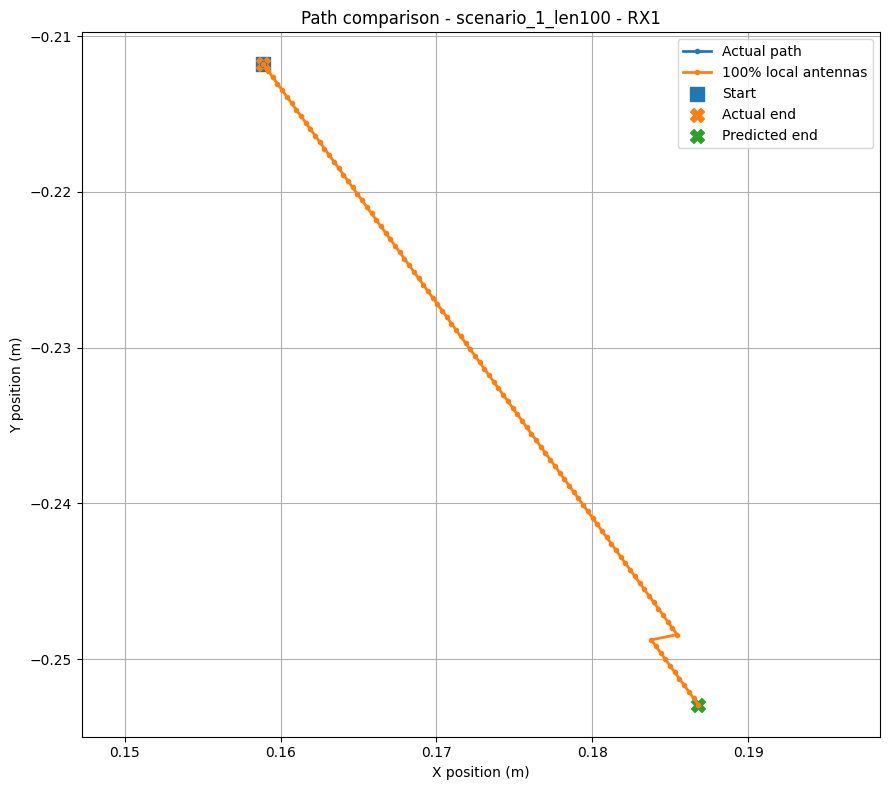

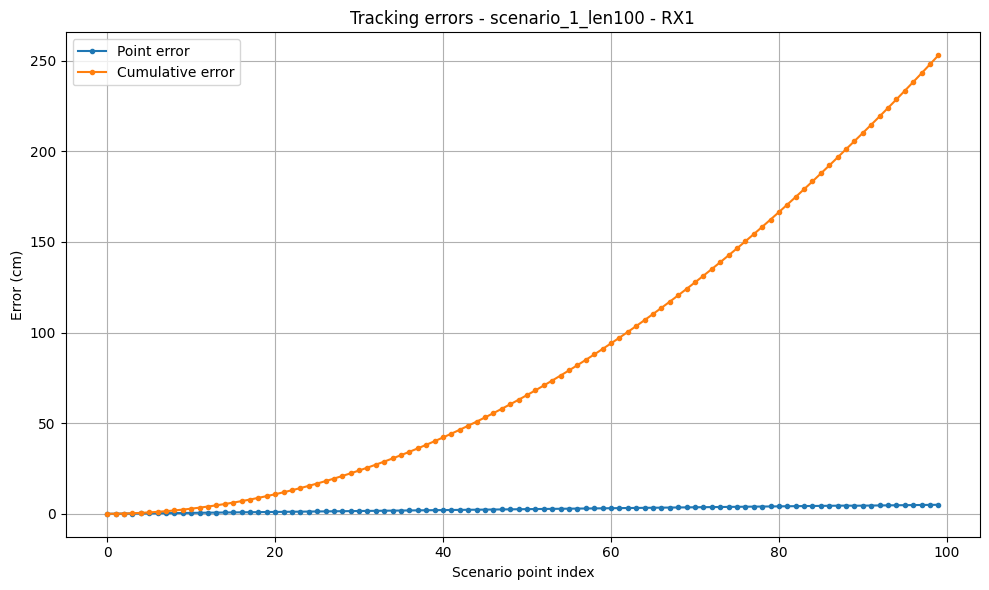


----------------------------------------------------------------------------------------------------
Running receiver mode: RX2


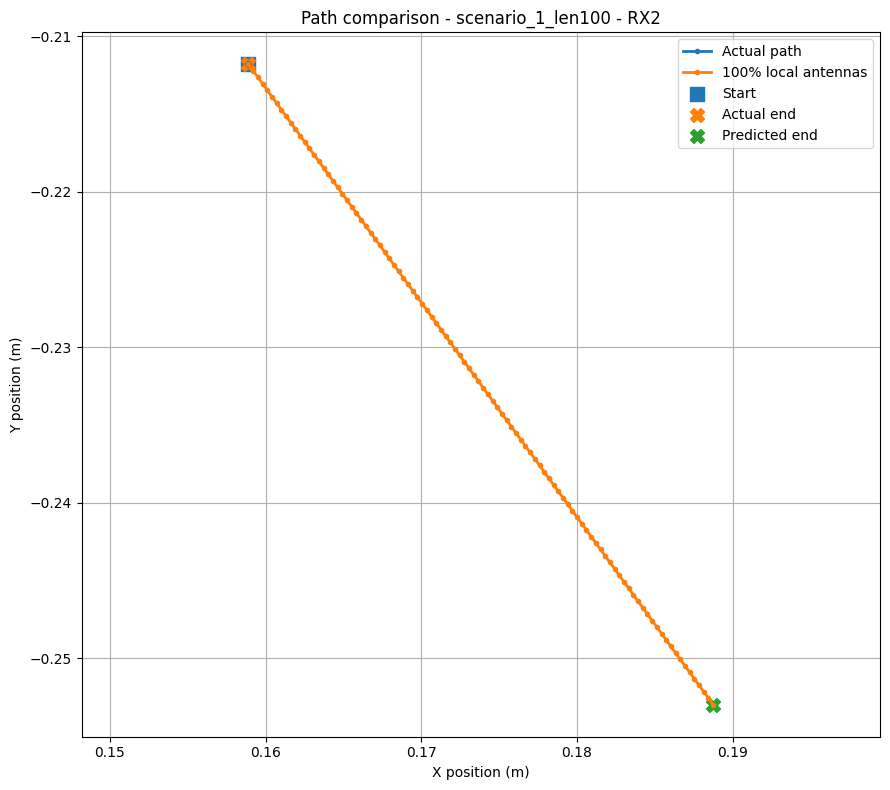

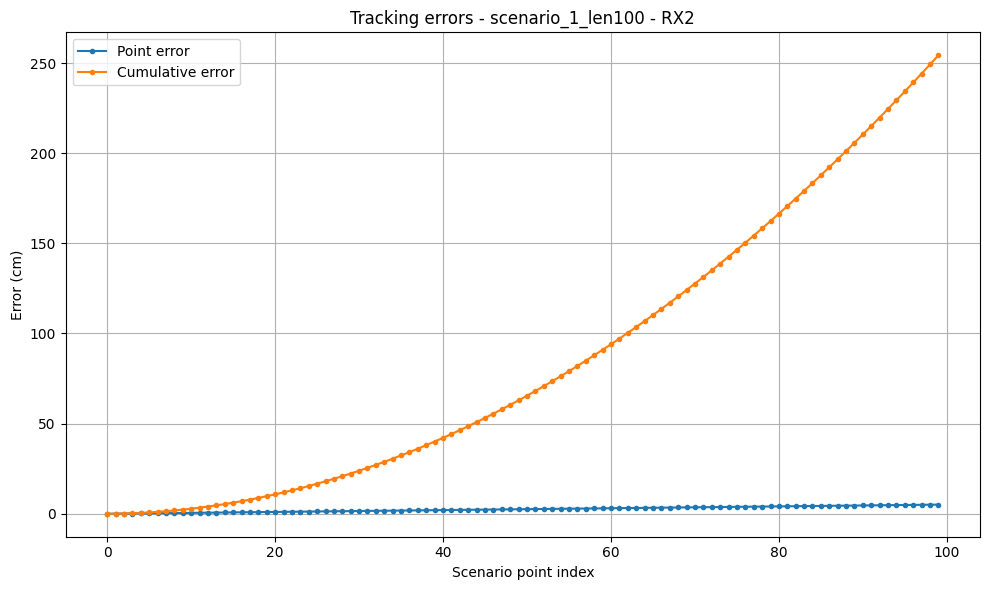


----------------------------------------------------------------------------------------------------
Running receiver mode: BOTH


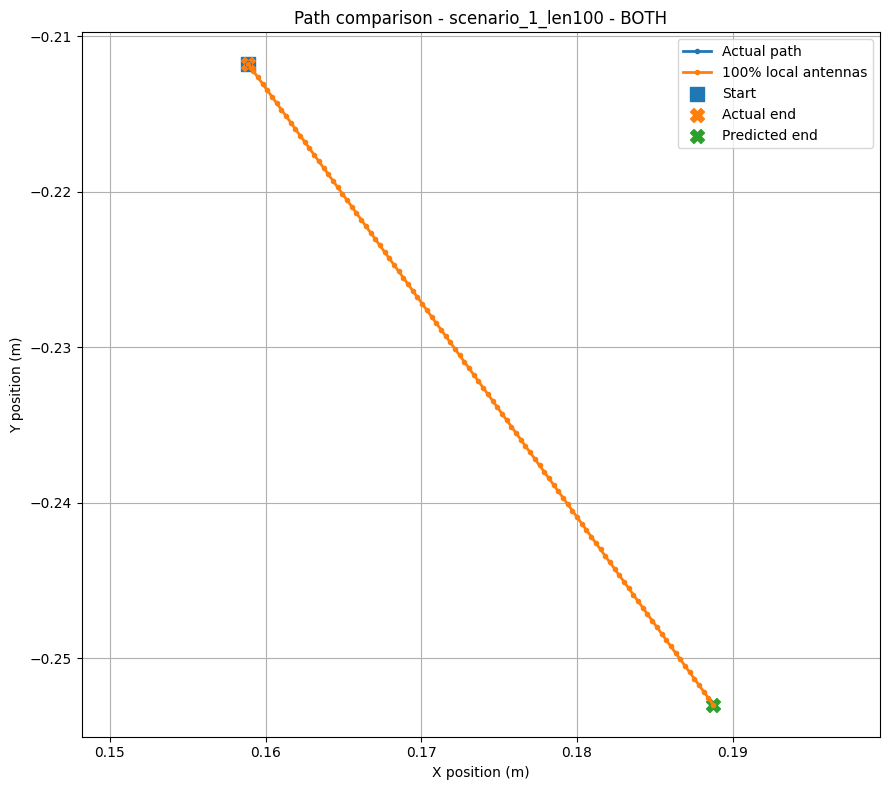

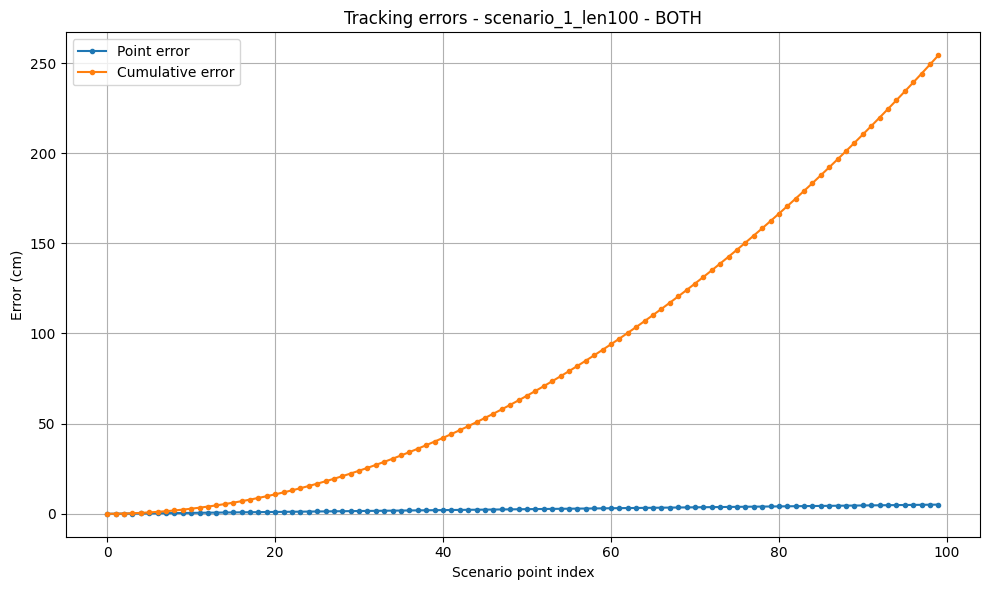


FIRST SCENARIO ROLLOUT RESULTS


,scenario,receiver_mode,percentage,number_of_points,number_of_transitions,mean_error_cm,rmse_cm,median_error_cm,max_error_cm,final_error_cm,cumulative_error_cm,position_alignment_max_error_m,active_antennas_per_step
0,scenario_1_len100,RX1,100.0,100,99,2.530087,2.922756,2.543119,4.967631,4.967631,253.008713,0.0,16
1,scenario_1_len100,RX2,100.0,100,99,2.543120,2.943950,2.543119,5.086247,5.086247,254.312027,0.0,16
2,scenario_1_len100,BOTH,100.0,100,99,2.543120,2.943950,2.543119,5.086247,5.086247,254.312027,0.0,32



Metrics CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_local_ig_delta/rollout_100_percent_local/scenario_1_len100_100_percent_local_metrics.csv

Rollout output directory:
/content/drive/MyDrive/DICHASUS_tracking_experiments_0d5x/dichasus_0d5x_single_model_rx1_rx2_both/shared_tracking_local_ig_delta/rollout_100_percent_local


In [ ]:
# ============================================================
# AUTOREGRESSIVE TRACKING ROLLOUT
# 100% LOCAL IG ANTENNAS
# FIRST VALIDATION SCENARIO
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "tracking_model",
    "val_run_datasets",
    "val_location_ranking_runs",
    "SCENARIOS",
    "SCENARIO_RECEIVER_MODES",
    "NUM_TOTAL_ANTENNAS",
    "NUM_SUBCARRIERS",
    "NUM_CSI_COMPONENTS",
    "normalize_pos_loaded",
    "denormalize_pos_loaded",
    "normalize_csi_loaded",
    "make_binary_mask_from_local_ranking",
    "EXPERIMENT_NAME",
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"{object_name} is not defined. "
            "Run the previous cells first."
        )


# ============================================================
# Evaluation configuration
# ============================================================

ROLLOUT_PERCENTAGE = 100

ROLLOUT_SCENARIO = SCENARIOS[0]

ROLLOUT_SAVE_DIR = os.path.join(
    "/content/drive/MyDrive/"
    "DICHASUS_tracking_experiments_0d5x",
    EXPERIMENT_NAME,
    "shared_tracking_local_ig_delta",
    "rollout_100_percent_local"
)

os.makedirs(
    ROLLOUT_SAVE_DIR,
    exist_ok=True
)


# ============================================================
# Dataset field helper
# ============================================================

def get_sample_field(
    sample,
    candidate_names,
    field_description
):
    for candidate_name in candidate_names:
        if candidate_name in sample:
            return sample[candidate_name]

    raise KeyError(
        f"Could not find {field_description}. "
        f"Available sample keys: {sorted(sample.keys())}"
    )


# ============================================================
# Extract a scenario from one validation run
# ============================================================

def extract_tracking_scenario_from_dataset(
    run_dataset,
    start_index,
    length
):
    positions = []
    csi_samples = []
    timestamps = []

    scenario_dataset = (
        run_dataset
        .skip(
            int(start_index)
        )
        .take(
            int(length)
        )
    )

    for sample in scenario_dataset:
        position_tensor = get_sample_field(
            sample=sample,
            candidate_names=(
                "position",
                "pos",
            ),
            field_description="position"
        )

        csi_tensor = get_sample_field(
            sample=sample,
            candidate_names=(
                "csi",
                "X_csi",
                "channel",
            ),
            field_description="CSI"
        )

        position = np.asarray(
            position_tensor.numpy(),
            dtype=np.float32
        ).reshape(2)

        csi = np.asarray(
            csi_tensor.numpy(),
            dtype=np.float32
        )

        expected_csi_shape = (
            NUM_TOTAL_ANTENNAS,
            NUM_SUBCARRIERS,
            NUM_CSI_COMPONENTS
        )

        if csi.shape != expected_csi_shape:
            raise ValueError(
                "Unexpected CSI shape. "
                f"Expected {expected_csi_shape}, "
                f"received {csi.shape}."
            )

        positions.append(
            position
        )

        csi_samples.append(
            csi
        )

        timestamp_tensor = None

        for timestamp_key in (
            "time",
            "timestamp",
        ):
            if timestamp_key in sample:
                timestamp_tensor = sample[
                    timestamp_key
                ]

                break

        if timestamp_tensor is None:
            timestamps.append(
                np.nan
            )

        else:
            timestamp_value = np.asarray(
                timestamp_tensor.numpy()
            ).reshape(-1)

            timestamps.append(
                float(
                    timestamp_value[0]
                )
            )

    if len(positions) != int(length):
        raise RuntimeError(
            "Scenario extraction returned an unexpected "
            "number of samples. "
            f"Expected {length}, received {len(positions)}."
        )

    positions = np.stack(
        positions,
        axis=0
    ).astype(np.float32)

    csi_samples = np.stack(
        csi_samples,
        axis=0
    ).astype(np.float32)

    timestamps = np.asarray(
        timestamps,
        dtype=np.float64
    )

    if not np.isfinite(
        positions
    ).all():
        raise RuntimeError(
            "Extracted positions contain non-finite values."
        )

    if not np.isfinite(
        csi_samples
    ).all():
        raise RuntimeError(
            "Extracted CSI contains non-finite values."
        )

    return {
        "positions": positions,
        "csi": csi_samples,
        "timestamps": timestamps,
    }


# ============================================================
# Receiver vector decoder
# ============================================================

def normalize_receiver_mode_vector(
    receiver_mode_vector
):
    receiver_mode_vector = np.asarray(
        receiver_mode_vector,
        dtype=np.float32
    ).reshape(-1)

    if receiver_mode_vector.shape != (
        3,
    ):
        raise ValueError(
            "receiver_mode_vector must have shape (3,). "
            f"Received {receiver_mode_vector.shape}."
        )

    if not np.isfinite(
        receiver_mode_vector
    ).all():
        raise ValueError(
            "receiver_mode_vector contains "
            "non-finite values."
        )

    if not np.all(
        np.logical_or(
            receiver_mode_vector == 0.0,
            receiver_mode_vector == 1.0
        )
    ):
        raise ValueError(
            "receiver_mode_vector must be binary."
        )

    if not np.isclose(
        np.sum(
            receiver_mode_vector
        ),
        1.0
    ):
        raise ValueError(
            "receiver_mode_vector must be one-hot."
        )

    return receiver_mode_vector


# ============================================================
# 100% local-IG autoregressive rollout
# ============================================================

def run_autoregressive_local_ig_rollout(
    model,
    scenario,
    receiver_mode,
    percentage=100
):
    scenario_name = str(
        scenario["name"]
    )

    run_id = int(
        scenario["run_id"]
    )

    start_index = int(
        scenario["start_index"]
    )

    length = int(
        scenario["length"]
    )

    extracted = extract_tracking_scenario_from_dataset(
        run_dataset=val_run_datasets[
            run_id
        ],
        start_index=start_index,
        length=length
    )

    actual_positions_m = extracted[
        "positions"
    ]

    scenario_csi = extracted[
        "csi"
    ]

    scenario_timestamps = extracted[
        "timestamps"
    ]

    ranking_metadata = (
        val_location_ranking_runs[
            receiver_mode
        ][run_id]
    )

    npz_path = ranking_metadata[
        "npz_path"
    ]

    with np.load(
        npz_path,
        allow_pickle=True
    ) as loaded:
        active_ranking_indices = np.asarray(
            loaded[
                "active_ranking_indices"
            ],
            dtype=np.int32
        )

        ranking_positions = np.asarray(
            loaded[
                "positions"
            ],
            dtype=np.float32
        )

        receiver_mode_vector = (
            normalize_receiver_mode_vector(
                loaded[
                    "receiver_mode_vector"
                ]
            )
        )

        availability_mask = np.asarray(
            loaded[
                "availability_mask"
            ],
            dtype=np.float32
        ).reshape(
            NUM_TOTAL_ANTENNAS
        )

    end_index_exclusive = (
        start_index
        + length
    )

    if (
        end_index_exclusive
        > active_ranking_indices.shape[0]
    ):
        raise ValueError(
            f"{scenario_name}/{receiver_mode}: "
            "scenario exceeds ranking cache length."
        )

    cached_positions_m = ranking_positions[
        start_index:end_index_exclusive
    ]

    if cached_positions_m.shape != (
        length,
        2
    ):
        raise ValueError(
            f"{scenario_name}/{receiver_mode}: "
            "cached position shape mismatch. "
            f"Received {cached_positions_m.shape}."
        )

    position_alignment_error = np.max(
        np.abs(
            actual_positions_m
            - cached_positions_m
        )
    )

    if position_alignment_error > 1e-4:
        raise ValueError(
            f"{scenario_name}/{receiver_mode}: "
            "dataset and ranking positions are not aligned. "
            f"Maximum difference={position_alignment_error:.8f}."
        )

    predicted_positions_m = np.zeros(
        (
            length,
            2
        ),
        dtype=np.float32
    )

    predicted_positions_normalized = np.zeros(
        (
            length,
            2
        ),
        dtype=np.float32
    )

    masks = np.zeros(
        (
            length - 1,
            NUM_TOTAL_ANTENNAS
        ),
        dtype=np.float32
    )

    predicted_positions_m[0] = (
        actual_positions_m[0]
    )

    predicted_positions_normalized[0] = (
        normalize_pos_loaded(
            actual_positions_m[
                0
            ].reshape(
                1,
                2
            )
        )[0].astype(
            np.float32
        )
    )

    for local_step in range(
        length - 1
    ):
        absolute_index_t = (
            start_index
            + local_step
        )

        local_ranking_t = (
            active_ranking_indices[
                absolute_index_t
            ]
        )

        mask_t = (
            make_binary_mask_from_local_ranking(
                active_ranking_indices_t=
                    local_ranking_t,
                receiver_mode=
                    receiver_mode,
                percentage=
                    percentage
            )
        )

        mask_t = np.asarray(
            mask_t,
            dtype=np.float32
        ).reshape(
            NUM_TOTAL_ANTENNAS
        )

        if not np.all(
            np.logical_or(
                mask_t == 0.0,
                mask_t == 1.0
            )
        ):
            raise RuntimeError(
                f"{scenario_name}/{receiver_mode}: "
                f"non-binary mask at step {local_step}."
            )

        if np.any(
            mask_t > availability_mask
        ):
            raise RuntimeError(
                f"{scenario_name}/{receiver_mode}: "
                "mask selected an unavailable antenna "
                f"at step {local_step}."
            )

        masks[
            local_step
        ] = mask_t

        csi_tplus1 = scenario_csi[
            local_step + 1
        ]

        csi_tplus1_normalized = (
            normalize_csi_loaded(
                csi_tplus1.reshape(
                    1,
                    NUM_TOTAL_ANTENNAS,
                    NUM_SUBCARRIERS,
                    NUM_CSI_COMPONENTS
                )
            )[0].astype(
                np.float32
            )
        )

        model_inputs = {
            "position_t_input":
                predicted_positions_normalized[
                    local_step
                ].reshape(
                    1,
                    2
                ),

            "csi_tplus1_input":
                csi_tplus1_normalized.reshape(
                    1,
                    NUM_TOTAL_ANTENNAS,
                    NUM_SUBCARRIERS,
                    NUM_CSI_COMPONENTS
                ),

            "antenna_mask_input":
                mask_t.reshape(
                    1,
                    NUM_TOTAL_ANTENNAS
                ),

            "receiver_mode_input":
                receiver_mode_vector.reshape(
                    1,
                    3
                ),
        }

        prediction_normalized = model(
            model_inputs,
            training=False
        ).numpy()

        prediction_normalized = np.asarray(
            prediction_normalized,
            dtype=np.float32
        ).reshape(
            1,
            2
        )

        if not np.isfinite(
            prediction_normalized
        ).all():
            raise RuntimeError(
                f"{scenario_name}/{receiver_mode}: "
                f"non-finite prediction at step {local_step}."
            )

        prediction_m = denormalize_pos_loaded(
            prediction_normalized
        )

        prediction_m = np.asarray(
            prediction_m,
            dtype=np.float32
        ).reshape(
            2
        )

        predicted_positions_normalized[
            local_step + 1
        ] = prediction_normalized[
            0
        ]

        predicted_positions_m[
            local_step + 1
        ] = prediction_m

    point_errors_m = np.linalg.norm(
        predicted_positions_m
        - actual_positions_m,
        axis=1
    )

    point_errors_cm = (
        point_errors_m
        * 100.0
    )

    cumulative_errors_cm = np.cumsum(
        point_errors_cm
    )

    metrics = {
        "scenario":
            scenario_name,

        "receiver_mode":
            receiver_mode,

        "percentage":
            float(
                percentage
            ),

        "number_of_points":
            int(
                length
            ),

        "number_of_transitions":
            int(
                length - 1
            ),

        "mean_error_cm":
            float(
                np.mean(
                    point_errors_cm
                )
            ),

        "rmse_cm":
            float(
                np.sqrt(
                    np.mean(
                        point_errors_cm ** 2
                    )
                )
            ),

        "median_error_cm":
            float(
                np.median(
                    point_errors_cm
                )
            ),

        "max_error_cm":
            float(
                np.max(
                    point_errors_cm
                )
            ),

        "final_error_cm":
            float(
                point_errors_cm[
                    -1
                ]
            ),

        "cumulative_error_cm":
            float(
                cumulative_errors_cm[
                    -1
                ]
            ),

        "position_alignment_max_error_m":
            float(
                position_alignment_error
            ),

        "active_antennas_per_step":
            int(
                np.sum(
                    masks[0]
                )
            ),
    }

    return {
        "scenario":
            scenario,

        "receiver_mode":
            receiver_mode,

        "actual_positions_m":
            actual_positions_m,

        "predicted_positions_m":
            predicted_positions_m,

        "predicted_positions_normalized":
            predicted_positions_normalized,

        "point_errors_cm":
            point_errors_cm,

        "cumulative_errors_cm":
            cumulative_errors_cm,

        "masks":
            masks,

        "timestamps":
            scenario_timestamps,

        "metrics":
            metrics,
    }


# ============================================================
# Plot one rollout
# ============================================================

def plot_tracking_rollout(
    rollout_result,
    save_dir
):
    scenario_name = rollout_result[
        "scenario"
    ]["name"]

    receiver_mode = rollout_result[
        "receiver_mode"
    ]

    actual_positions = rollout_result[
        "actual_positions_m"
    ]

    predicted_positions = rollout_result[
        "predicted_positions_m"
    ]

    point_errors_cm = rollout_result[
        "point_errors_cm"
    ]

    cumulative_errors_cm = rollout_result[
        "cumulative_errors_cm"
    ]

    step_indices = np.arange(
        len(
            actual_positions
        )
    )

    path_figure = plt.figure(
        figsize=(
            9,
            8
        )
    )

    plt.plot(
        actual_positions[:, 0],
        actual_positions[:, 1],
        marker="o",
        markersize=3,
        linewidth=2,
        label="Actual path"
    )

    plt.plot(
        predicted_positions[:, 0],
        predicted_positions[:, 1],
        marker="o",
        markersize=3,
        linewidth=2,
        label="100% local antennas"
    )

    plt.scatter(
        actual_positions[0, 0],
        actual_positions[0, 1],
        s=100,
        marker="s",
        label="Start"
    )

    plt.scatter(
        actual_positions[-1, 0],
        actual_positions[-1, 1],
        s=100,
        marker="X",
        label="Actual end"
    )

    plt.scatter(
        predicted_positions[-1, 0],
        predicted_positions[-1, 1],
        s=100,
        marker="X",
        label="Predicted end"
    )

    plt.xlabel(
        "X position (m)"
    )

    plt.ylabel(
        "Y position (m)"
    )

    plt.title(
        f"Path comparison - {scenario_name} - "
        f"{receiver_mode}"
    )

    plt.axis(
        "equal"
    )

    plt.grid(
        True
    )

    plt.legend()

    plt.tight_layout()

    path_plot_path = os.path.join(
        save_dir,
        (
            f"{scenario_name}_"
            f"{receiver_mode}_"
            "path_comparison.png"
        )
    )

    path_figure.savefig(
        path_plot_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        path_figure
    )

    error_figure = plt.figure(
        figsize=(
            10,
            6
        )
    )

    plt.plot(
        step_indices,
        point_errors_cm,
        marker="o",
        markersize=3,
        label="Point error"
    )

    plt.plot(
        step_indices,
        cumulative_errors_cm,
        marker="o",
        markersize=3,
        label="Cumulative error"
    )

    plt.xlabel(
        "Scenario point index"
    )

    plt.ylabel(
        "Error (cm)"
    )

    plt.title(
        f"Tracking errors - {scenario_name} - "
        f"{receiver_mode}"
    )

    plt.grid(
        True
    )

    plt.legend()

    plt.tight_layout()

    error_plot_path = os.path.join(
        save_dir,
        (
            f"{scenario_name}_"
            f"{receiver_mode}_"
            "tracking_errors.png"
        )
    )

    error_figure.savefig(
        error_plot_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        error_figure
    )

    return {
        "path_plot_path":
            path_plot_path,

        "error_plot_path":
            error_plot_path,
    }


# ============================================================
# Run the first scenario for all receiver modes
# ============================================================

first_scenario_rollouts = {}

first_scenario_metric_records = []


print("=" * 100)
print("100% LOCAL-IG AUTOREGRESSIVE ROLLOUT")
print("=" * 100)

print(
    "Scenario:",
    ROLLOUT_SCENARIO
)


for receiver_mode in SCENARIO_RECEIVER_MODES:
    print("\n" + "-" * 100)

    print(
        "Running receiver mode:",
        receiver_mode
    )

    rollout_result = (
        run_autoregressive_local_ig_rollout(
            model=tracking_model,
            scenario=ROLLOUT_SCENARIO,
            receiver_mode=receiver_mode,
            percentage=ROLLOUT_PERCENTAGE
        )
    )

    plot_paths = plot_tracking_rollout(
        rollout_result=rollout_result,
        save_dir=ROLLOUT_SAVE_DIR
    )

    rollout_result[
        "plot_paths"
    ] = plot_paths

    first_scenario_rollouts[
        receiver_mode
    ] = rollout_result

    first_scenario_metric_records.append(
        rollout_result[
            "metrics"
        ]
    )


# ============================================================
# Metrics table
# ============================================================

first_scenario_metrics_df = pd.DataFrame(
    first_scenario_metric_records
)

metrics_csv_path = os.path.join(
    ROLLOUT_SAVE_DIR,
    (
        f"{ROLLOUT_SCENARIO['name']}_"
        "100_percent_local_metrics.csv"
    )
)

first_scenario_metrics_df.to_csv(
    metrics_csv_path,
    index=False
)


print("\n" + "=" * 100)
print("FIRST SCENARIO ROLLOUT RESULTS")
print("=" * 100)

display(
    first_scenario_metrics_df
)

print("\nMetrics CSV:")
print(
    metrics_csv_path
)

print("\nRollout output directory:")
print(
    ROLLOUT_SAVE_DIR
)

In [ ]:
# SCENARIOS = [
#     {"name": "scenario_1_100", "run_id": 0, "start_index": 0, "length": 100},
#     {"name": "scenario_2_120", "run_id": 0, "start_index": 80, "length": 120},
#     {"name": "scenario_3_150", "run_id": 0, "start_index": 180, "length": 150},
#     {"name": "scenario_4_120", "run_id": 0, "start_index": 320, "length": 120},
#     {"name": "scenario_5_150", "run_id": 0, "start_index": 450, "length": 150},
#     {"name": "scenario_6_100", "run_id": 0, "start_index": 620, "length": 100},
# ]

# print("SCENARIOS ready:", len(SCENARIOS))

SCENARIOS ready: 6
